_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: <span style='background: yellow'>*Agnese Adorante, Hwajin Shin, Lucia Gonzalez Anton* </span>

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which one and where did you use it? [Copilot, Claude, ChatGPT, etc.]* </span> 

Yes, we used ChatGPT to refine written answers and adapt code from the coding labs and the Allen Institute to our dataset. We also made extensive use of Cursor, particularly for the clustering analysis, where it suggested exploring biological interpretations of functional clusters, evaluating their spatial organization in cortical space, and incorporating model selection approaches to determine the number of clusters.

# Neural Data Science Project 02

## Working with Calcium data

In the following project you will recieve a data set, along with a set of questions. Use the methods that you have learned throughout this course to explore the data and to answer the questions. You are free to use tools, resources and libraries as you see fit. Use comments and markdown cells to document your thought process and to explain your reasoning. We encourage you to compare different algorithms or to implement state of the art solutions. The notebook should be self contained, although you may offload some functions to a `utils.py`. The notebook should be concluded with a final summary / conclusions section.

In [1]:
# import packages here

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import signal
import matplotlib.cm as cm
import random
from scipy.signal import find_peaks
from scipy.stats import zscore

# from oasis.functions import deconvolve
import urllib.request
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

#url = "https://raw.githubusercontent.com/liubenyuan/py-oopsi/master/oopsi.py"
#urllib.request.urlretrieve(url, "oopsi.py")
#import oopsi
from tqdm import tqdm
from sklearn.preprocessing import minmax_scale
from scipy.ndimage import gaussian_filter
from scipy.ndimage import label
from matplotlib.gridspec import GridSpec
from scipy.optimize import minimize
from functools import partial
from scipy.special import gammaln
from sklearn.linear_model import Lasso
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
from rfest import splineLG, splineLNP, splineLNLN
from rfest import ALD, ASD, GLM, LNLN, LNP
from rfest.utils import build_design_matrix
from scipy.ndimage import center_of_mass
from scipy.stats import spearmanr
from skimage.measure import moments_central
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
import pickle
import math
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

#%load_ext jupyter_black

#%load_ext watermark
#%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

## Context

The data set that goes along with this notebook was recorded using in vivo 2-photon calcium imaging to measure the activity of genetically identified neurons in the visual cortex of mice performing a go/no-go visual change detection task. The data recordings stem from primary visual cortex and a GCaMP6f indicator was used. The data was recorded as follows.


The data consists of:
- the preprocessed activity traces (df/f)
- the stimulus metadata
- the stimulus frames
- the ROI masks for each cell
- a maximum activity projection of the recorded area
- running speed
- table of stimulus epochs

You will only work with a locally sparse noise stimulus.

Since the experiments were performed in sequence the calcium recordings that you receive also contain some other stimulus modalities (see `data["stim_epoch_table"]`). You can ignore these sections of the time-series data during analysis. Not all the data provided has to be used, however it can be incorporated into your analysis.

In [2]:
# load data
def load_data(path="."):
    def array2df(d, key, cols):
        d[key] = pd.DataFrame(d[key], columns=cols)

    data = np.load(path + "/dff_data_rf.npz", allow_pickle=True)
    data = dict(data)
    array2df(data, "stim_table", ["frame", "start", "end"])
    array2df(data, "stim_epoch_table", ["start", "end", "stimulus"])

    return data


def print_info(data):
    data_iter = ((k, type(v), v.shape) for k, v in data.items())
    l = [f"[{k}] - {t}, - {s}" for k, t, s in data_iter]
    print("\n".join(l) + "\n")


path = os.getcwd()
data = load_data(path)

print("Overview of the data")
print_info(data)

Overview of the data
[t] - <class 'numpy.ndarray'>, - (105968,)
[dff] - <class 'numpy.ndarray'>, - (189, 105968)
[stim_table] - <class 'pandas.core.frame.DataFrame'>, - (8880, 3)
[stim] - <class 'numpy.ndarray'>, - (9000, 16, 28)
[roi_masks] - <class 'numpy.ndarray'>, - (189, 512, 512)
[max_projection] - <class 'numpy.ndarray'>, - (512, 512)
[running_speed] - <class 'numpy.ndarray'>, - (2, 105968)
[stim_epoch_table] - <class 'pandas.core.frame.DataFrame'>, - (7, 3)



## Question

**Is there spatial structure on the location of the receptive fields?**

Implement all steps of the processing pipeline that are necessary to answer them. Think of:
1. Pre-processing
2. Spike inference
3. Tuning function fitting
4. Statistical testing.

It is sufficient to assess spatial structure visually. Additional insights and analyses will be positively factored into the overall grade.

# Utils

This section contains utility functions (mostly plotting functions) used throughout the project. You can collapse this cell to focus on the main content without scrolling through lengthy code blocks.

In [3]:
def plot_trace_with_stimulus(
    trace,
    time,
    stim_epochs,
    start_time,
    duration,
    event_trace=None,
    fs=30,
    colormap="tab10",
    behavior=False,
):
    """
    Plots a single calcium trace with vertical background shading for each stimulus type.

    Parameters:
        trace (np.ndarray): dF/F trace of one neuron
        time (np.ndarray): time vector
        stim_epochs (pd.DataFrame): with columns ['stimulus', 'start', 'end']
        start_time (float): time to start plotting (in seconds)
        duration (float): duration to plot (in seconds)
        event_trace (np.ndarray): optional, e.g. deconvolved spikes
        fs (int): sampling rate
        colormap (str): name of matplotlib colormap
    """

    # Set time window
    start_frame = int(start_time * fs)
    end_frame = int((start_time + duration) * fs)
    time_window = time[start_frame:end_frame]
    trace_window = trace[start_frame:end_frame]
    if event_trace is not None:
        event_window = event_trace[start_frame:end_frame]

    # Create stimulus colormap
    stim_types = sorted(stim_epochs["stimulus"].unique())
    colors = cm.get_cmap(colormap, len(stim_types))
    stim_color_map = {stim: colors(i) for i, stim in enumerate(stim_types)}

    # Plot
    plt.figure(figsize=(15, 4))

    # Background shading
    for _, row in stim_epochs.iterrows():
        stim_start, stim_end = row["start"], row["end"]
        stim_label = row["stimulus"]
        if (stim_end / fs) < start_time or (stim_start / fs) > (start_time + duration):
            continue  # outside window

        # Clamp shading to plotting window
        plot_start = max(stim_start / fs, start_time)
        plot_end = min(stim_end / fs, start_time + duration)

        plt.axvspan(plot_start, plot_end, color=stim_color_map[stim_label], alpha=0.2)

    # Plot traces
    plt.plot(
        time_window,
        trace_window / trace_window.max(),
        label="dff trace",
        color="steelblue",
    )
    if event_trace is not None:
        plt.plot(time_window, event_window, label="events trace", color="orange")

    if behavior is True:
        plt.plot(
            time_window,
            running_speed[0, start_frame:end_frame]
            / running_speed[0, start_frame:end_frame].max(),
            label="running speed",
            color="green",
        )
    # Legend for stimulus types
    legend_patches = [
        mpatches.Patch(color=stim_color_map[stim], label=stim) for stim in stim_types
    ]
    event_patchs = [plt.Line2D([], [], color="steelblue", label="dff trace")]
    if event_trace is not None:
        event_patchs.append(plt.Line2D([], [], color="orange", label="events trace"))
    if behavior is True:
        event_patchs.append(plt.Line2D([], [], color="green", label="running speed"))
    plt.legend(handles=legend_patches + event_patchs)

    plt.xlabel("Time (s)")
    plt.ylabel("Normalized response magnitude")
    plt.title(f"Calcium Trace with Stimulus Background")
    plt.tight_layout()
    plt.show()

In [4]:
def plot_calcium_traces(indices, start_time, duration, fs=30, offset=3):
    """
    Plot calcium traces for selected neuron indices within a time window.

    Parameters:
        indices (list): List of neuron indices to plot
        start_time (float): Start time in seconds
        duration (float): Duration in seconds
        fs (int): Sampling rate (frames per second)
        offset (float): Vertical offset between traces
        time (np.ndarray): Time vector
        traces (np.ndarray): Calcium trace array (neurons x time)
    """
    time = data["t"]
    traces = data["dff"]

    # Convert time window to frame indices
    start_frame = int(start_time * fs)
    end_frame = int((start_time + duration) * fs)

    # Extract time and trace segments
    time_window = time[start_frame:end_frame]
    trace_window = traces[:, start_frame:end_frame]

    # Plot
    plt.figure(figsize=(12, 6))
    for i, neuron_idx in enumerate(indices):
        trace = trace_window[neuron_idx]
        trace_norm = trace / trace.max()  # normalize
        plt.plot(time_window, trace_norm + i * offset, color="black")

    plt.title(f"Normalized Calcium Traces")
    plt.xlabel("Time (s)")
    plt.yticks(np.arange(len(indices)) * offset, indices)
    plt.ylabel("Neuron ID")
    plt.tight_layout()
    plt.show()

In [5]:
def plot_detected_spikes(trace, spike_idxs, fs, neuron_id="neuron_id", window=None):
    """
    Plot the calcium trace with detected spikes shown as red crosses.

    Parameters:
        trace: 1D np.array, calcium trace of one neuron
        spike_idxs: list or np.array of spike indices
        fs: sampling rate in Hz
        neuron_id: int or str, for labeling
        window: tuple (start_time, end_time) in seconds (optional)
    """
    trace = np.asarray(trace)
    spike_idxs = np.asarray(spike_idxs, dtype=int)
    t = np.arange(len(trace)) / fs

    if window:
        start_time, end_time = window
        idx_start = int(start_time * fs)
        idx_end = int(end_time * fs)
        t = t[idx_start:idx_end]
        trace = trace[idx_start:idx_end]

        # Only include spikes within the window
        spike_idxs = spike_idxs[(spike_idxs >= idx_start) & (spike_idxs < idx_end)]
        spike_idxs_windowed = spike_idxs - idx_start
    else:
        spike_idxs_windowed = spike_idxs

    # Safety check: ensure all spike indices are within range
    spike_idxs_windowed = spike_idxs_windowed[
        (spike_idxs_windowed >= 0) & (spike_idxs_windowed < len(trace))
    ]

    plt.figure(figsize=(12, 4))
    plt.plot(t, trace, label="Calcium Trace")
    plt.scatter(
        t[spike_idxs_windowed],
        trace[spike_idxs_windowed],
        color="red",
        marker="x",
        label="Detected Spikes",
        zorder=3,
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Fluorescence")
    plt.title(f"Neuron {neuron_id} - Detected Spikes")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [6]:
def plot_population_firing_rate(
    spike_traces, bin_size=30, sampling_rate=30, threshold=0.5, figsize=(8, 4)
):
    """
    Plots average population firing rate over time.

    Parameters:
    - spike_traces: array of shape (n_neurons, n_frames)
    - bin_size: number of frames per bin (e.g. 30 = 1 sec @ 30 Hz)
    - sampling_rate: imaging rate
    - threshold: spike detection threshold
    """
    n_neurons, n_frames = spike_traces.shape
    spike_binary = spike_traces > threshold
    n_bins = n_frames // bin_size
    pop_rate = []

    for i in range(n_bins):
        bin_slice = slice(i * bin_size, (i + 1) * bin_size)
        rate = spike_binary[:, bin_slice].sum() / (
            n_neurons * (bin_size / sampling_rate)
        )  # spikes/s/neuron
        pop_rate.append(rate)

    time_bins = np.arange(n_bins) * (bin_size / sampling_rate)

    plt.figure(figsize=figsize)
    plt.plot(time_bins, pop_rate, color="dodgerblue")
    plt.xlabel("Time (s)")
    plt.ylabel("Avg Firing Rate (Hz)")
    plt.title("Population Firing Rate Over Time")
    plt.tight_layout()
    plt.show()

In [7]:
def plot_raster_with_stimulus(
    spike_traces,
    stim_epochs,
    stim_metadata,
    stimulus_name="locally_sparse_noise",
    threshold=0.5,
    sampling_rate=30,
    figsize=(12, 6),
    title="Raster Plot with Stimulus",
):
    """
    Raster plot with a separate subplot on top for stimulus timing.
    """
    n_neurons, n_frames = spike_traces.shape
    times = np.arange(n_frames) / sampling_rate

    # --- Build stimulus mask
    stim_mask = np.zeros(n_frames, dtype=bool)
    for _, epoch in stim_epochs[stim_epochs["stimulus"] == stimulus_name].iterrows():
        stim_start, stim_end = epoch["start"], epoch["end"]
        frame_indices = stim_metadata[
            (stim_metadata["start"] >= stim_start) & (stim_metadata["end"] <= stim_end)
        ][["start", "end"]].values
        for start, end in frame_indices:
            stim_mask[start:end] = True

    # --- Create two subplots
    fig, (ax_stim, ax_raster) = plt.subplots(
        2,
        1,
        figsize=figsize,
        height_ratios=[0.3, 1],
        sharex=True,
        gridspec_kw={"hspace": 0.05},
    )

    fig.suptitle(title, fontsize=14)

    # --- Plot stimulus bar (top subplot)
    stim_on_times = np.where(stim_mask)[0]
    if len(stim_on_times) > 0:
        diffs = np.diff(stim_on_times)
        split_idx = np.where(diffs > 1)[0] + 1
        chunks = np.split(stim_on_times, split_idx)
        for chunk in chunks:
            t_start = chunk[0] / sampling_rate
            t_end = chunk[-1] / sampling_rate
            ax_stim.axvspan(
                t_start,
                t_end,
                color="orange",
                alpha=0.7,
                lw=0,
            )
    ax_stim.set_yticks([])
    ax_stim.set_ylabel("Stim")
    ax_stim.set_xlim(times[0], times[-1])
    ax_stim.spines["top"].set_visible(False)
    ax_stim.spines["right"].set_visible(False)
    ax_stim.spines["left"].set_visible(False)

    # --- Plot raster (bottom subplot)
    for neuron_id in range(n_neurons):
        spikes = np.where(spike_traces[neuron_id] > threshold)[0]
        ax_raster.vlines(
            times[spikes],
            neuron_id + 0.5,
            neuron_id + 1.5,
            color="black",
            linewidth=0.5,
        )

    ax_raster.set_ylim(0.5, n_neurons + 0.5)
    ax_raster.set_xlabel("Time (s)")
    ax_raster.set_ylabel("Neuron ID")

    # plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [8]:
def plot_detected_spikes(trace, spike_idxs, fs, neuron_id="neuron_id", window=None):
    """
    Plot the calcium trace with detected spikes shown as red crosses.

    Parameters:
        trace: 1D np.array, calcium trace of one neuron
        spike_idxs: list or np.array of spike indices
        fs: sampling rate in Hz
        neuron_id: int or str, for labeling
        window: tuple (start_time, end_time) in seconds (optional)
    """
    trace = np.asarray(trace)
    spike_idxs = np.asarray(spike_idxs, dtype=int)
    t = np.arange(len(trace)) / fs

    if window:
        start_time, end_time = window
        idx_start = int(start_time * fs)
        idx_end = int(end_time * fs)
        t = t[idx_start:idx_end]
        trace = trace[idx_start:idx_end]

        # Only include spikes within the window
        spike_idxs = spike_idxs[(spike_idxs >= idx_start) & (spike_idxs < idx_end)]
        spike_idxs_windowed = spike_idxs - idx_start
    else:
        spike_idxs_windowed = spike_idxs

    # Safety check: ensure all spike indices are within range
    spike_idxs_windowed = spike_idxs_windowed[
        (spike_idxs_windowed >= 0) & (spike_idxs_windowed < len(trace))
    ]

    plt.figure(figsize=(12, 4))
    plt.plot(t, trace, label="Calcium Trace")
    plt.scatter(
        t[spike_idxs_windowed],
        trace[spike_idxs_windowed],
        color="red",
        marker="x",
        label="Detected Spikes",
        zorder=3,
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Fluorescence")
    plt.title(f"Neuron {neuron_id} - Detected Spikes by Thresholding")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [9]:
def plot_sta_grid(
    stas, neurons, Dx, Dy, cmap="bwr", title="STA Montage", vmin=None, vmax=None
):
    """
    Plot STA(s) with neuron IDs as y-axis labels and well-aligned colorbars.

    Parameters:
    - stas: (n_neurons, Dx*Dy, n_lags) or (Dx*Dy, n_lags)
    - neurons: list of neuron IDs or single neuron id
    - Dx, Dy: stimulus spatial dims
    - cmap: colormap
    - title: figure title
    - vmin, vmax: color scaling limits
    """
    # Normalize input shape & neuron IDs
    if stas.ndim == 2:
        stas = stas[np.newaxis, ...]
    if isinstance(neurons, int):
        neurons = [neurons]

    n_neurons, _, n_lags = stas.shape

    fig = plt.figure(figsize=(2.5 * n_lags + 1, 2.5 * n_neurons))
    gs = GridSpec(
        n_neurons,
        n_lags + 1,
        width_ratios=[1] * n_lags + [0.05],
        wspace=0.1,
        hspace=0.3,
    )

    for i in range(n_neurons):
        for j in range(n_lags):
            ax = fig.add_subplot(gs[i, j])
            frame = stas[i, :, j].reshape(Dx, Dy)
            im = ax.imshow(
                gaussian_filter(frame, sigma=1),
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
            )
            ax.set_xticks([])
            ax.set_yticks([])
            ax.spines[:].set_visible(False)
            if i == 0:
                ax.set_title(f"Lag -{j}", fontsize=10)

            # Add neuron ID label only on first column, centered vertically
            if j == 0:
                ax.set_ylabel(
                    f"Neuron {neurons[i]}",
                    fontsize=10,
                    rotation=90,
                    labelpad=15,
                    # va="center",
                )

        # Add colorbar for each neuron row in the last column
        cax = fig.add_subplot(gs[i, -1])
        plt.colorbar(im, cax=cax)
        cax.yaxis.set_ticks_position("right")
        cax.yaxis.set_label_position("right")

    fig.suptitle(title, fontsize=16)
    plt.show()

In [10]:
def plot_rf_metrics_histograms(metrics, bins=30, figsize=(15,4)):
    """
    metrics: dict from compute_all_rf_metrics
    Creates a multi-panel figure with histograms.
    """

    peaks = metrics['peaks']
    symms = metrics['symmetries']
    mean_sim = metrics['mean_similarity']
    pair_sims = metrics['pairwise_similarity']
    
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    axes = axes.ravel()

    # RF peaks
    axes[0].hist(peaks, bins=bins, color='0.5')
    axes[0].set_title('RF peak amplitude')
    axes[0].set_xlabel('Amplitude')

    # RF symmetry
    axes[1].hist(symms[~np.isnan(symms)], bins=bins, color='0.5')
    axes[1].set_title('RF symmetry (corr w/ flip)')
    axes[1].set_xlabel('Correlation')

    # Mean similarity per neuron
    axes[2].hist(mean_sim, bins=bins, color='0.5')
    axes[2].set_title('Mean RF similarity (per neuron)')
    axes[2].set_xlabel('Mean corr to others')

    # Pairwise similarities
    axes[3].hist(pair_sims, bins=bins, color='0.5')
    axes[3].set_title('All pairwise RF similarities')
    axes[3].set_xlabel('Correlation')

    plt.tight_layout()
    plt.show()


# Exploratory Data Analysis

In this section we investigate raw data: we visualize calcium trace, the locally sparse noise stimulus and ROIs with corresponding max projections.

First, we'll explore the dataset by examining the following:

- Calcium trace: Neural activity recordings.
- stim_epochs and stim_metadata: DataFrames detailing the stimulus presentation sequences.
- stims array: Contains all stimuli shown during the experiment.
- ROI masks and max projection: Used to identify neuron positions on the cortical surface.
- Running speed: Although it may not be central to our analysis, we'll investigate how running speed varies with different stimuli and whether it correlates with neural activity during this exploratory phase.

In [11]:
# Clacium trace
traces = data["dff"]  # shape: (n_cells, n_frames)

# Stimuli
stim_epochs = data["stim_epoch_table"]
stim_epochs.columns = ["stimulus", "start", "end"]
stim_metadata = data["stim_table"]
stims = data["stim"]

# Roi masks and projections
roi_masks = data["roi_masks"]
max_projection = data["max_projection"]

# Behavior
running_speed = data["running_speed"]

# time
time = data["t"]

In [12]:
print("Traces Info")
print(f"Number of cells: {traces.shape[0]}")
print(f"Number of frames: {traces.shape[1]}")
print("---------------------------------------------------")
print("Stimulus Info")
print(f"Number of stimulus epochs: {len(stim_epochs)}")
print(f"Stimuli types: {set(stim_epochs['stimulus'])}")
print(f"Number of presented stimuli: {stim_metadata.shape[0]}")
print(f"Stimulus shape: {stims.shape[1], stims.shape[2]}")
print("---------------------------------------------------")
print("Recording Frequency")
dt = np.median(np.diff(time))  # sampling interval in seconds
fs = 1 / dt  # sampling frequency in Hz
print(f"Time resolution: {np.round(fs)} Hz")
print("---------------------------------------------------")
print("ROI Masks Info")
print(f"Max projection shape: {max_projection.shape}")
print(f"Number of ROIs: {roi_masks.shape[0]}")

Traces Info
Number of cells: 189
Number of frames: 105968
---------------------------------------------------
Stimulus Info
Number of stimulus epochs: 7
Stimuli types: {'natural_movie_two', 'spontaneous', 'locally_sparse_noise', 'natural_movie_one'}
Number of presented stimuli: 8880
Stimulus shape: (16, 28)
---------------------------------------------------
Recording Frequency
Time resolution: 30.0 Hz
---------------------------------------------------
ROI Masks Info
Max projection shape: (512, 512)
Number of ROIs: 189


The dataset includes recordings from 189 neurons over 105,968 frames at a sampling rate of 30 Hz, resulting in a total recording duration of approximately 60 minutes.

Four types of stimuli were presented during the experiment, but our analysis will focus on the _locally_sparse_noise_ stimulus. Each stimulus has a shape of (16, 28), and a total of 8,880 stimuli were presented.

The ROI masks, each with a shape of (512, 512), correspond to individual neurons, allowing us to localize their positions on the cortical surface.

## Calcium Trace

In this section, we examine the calcium traces to visualize neural activity over time. 

We start by plotting normalized calcium traces from 10 randomly selected neurons over a short time span to highlight individual activity patterns. 

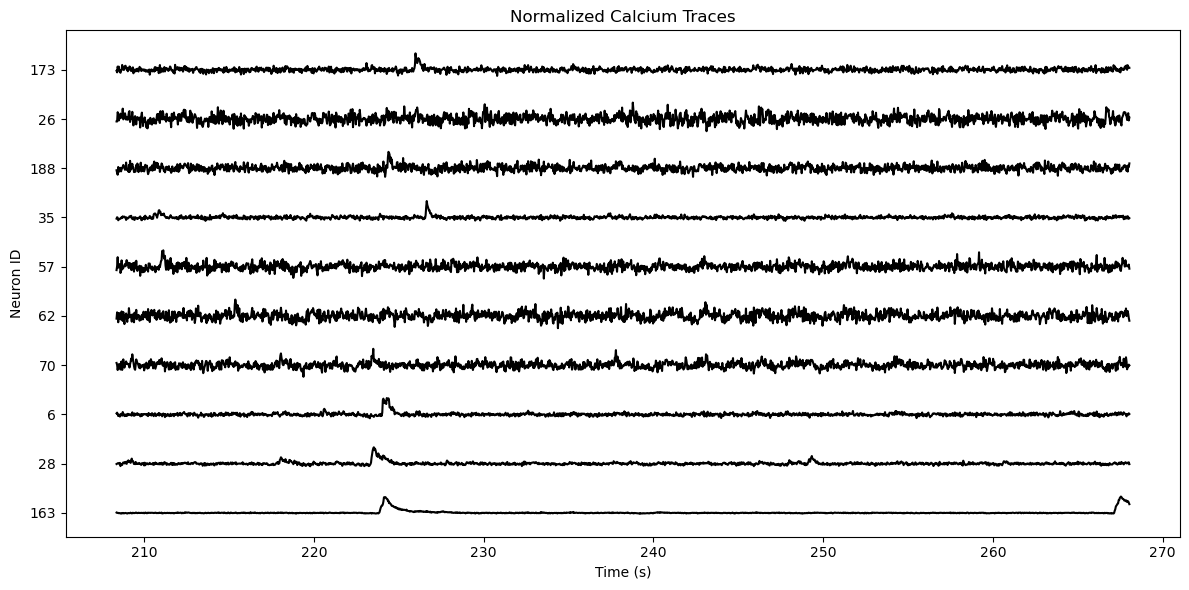

In [13]:
random.seed(42)
indices = random.sample(range(traces.shape[0]), 10)

plot_calcium_traces(indices, start_time=200, duration=60)

The plot shows normalized calcium traces from 10 randomly selected neurons over a short time window. We observe that some neurons display higher activity levels or more frequent fluctuations, while others exhibit more localized, peak-like events. However, it is difficult to draw detailed conclusions about neural firing patterns from calcium traces alone, as these signals can be influenced by noise and do not directly reflect spike timing. Further analysis, such as spike extraction, will be help us characterize neural activity and distinguish between different response profiles.

Next, we present a long-term calcium trace with stimulus timing indicated in the background, providing context for neural responses to stimuli. 

C:\Users\aagne\AppData\Local\Temp\ipykernel_41516\4122868606.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(colormap, len(stim_types))


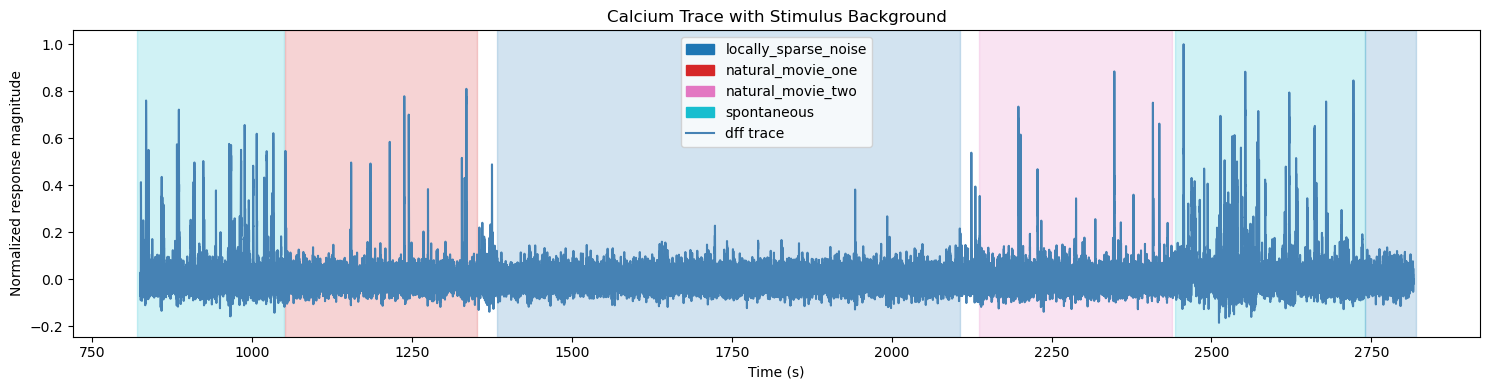

In [14]:
# Choose neuron index and time window
neuron_idx = 42
start_time = 820
duration = 2000

# Use your data
trace = traces[neuron_idx]

# Call function (without events)
plot_trace_with_stimulus(trace, time, stim_epochs, start_time, duration)

The plot shows that neural activity is noticeably higher during natural movie presentations and spontaneous periods, while responses to locally_sparse_noise are less pronounced. This suggests that naturalistic stimuli and spontaneous activity engage the neural network more robustly, possibly because natural movies contain richer and more complex visual information that drives stronger or more coordinated responses across neurons. In contrast, locally_sparse_noise may not activate the same circuits as effectively, leading to lower overall activity.

Finally, we overlay normalized calcium traces with both stimulus background and running speed, allowing us to explore potential relationships between neural activity, stimulus presentation, and behavioral state.

C:\Users\aagne\AppData\Local\Temp\ipykernel_41516\4122868606.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(colormap, len(stim_types))


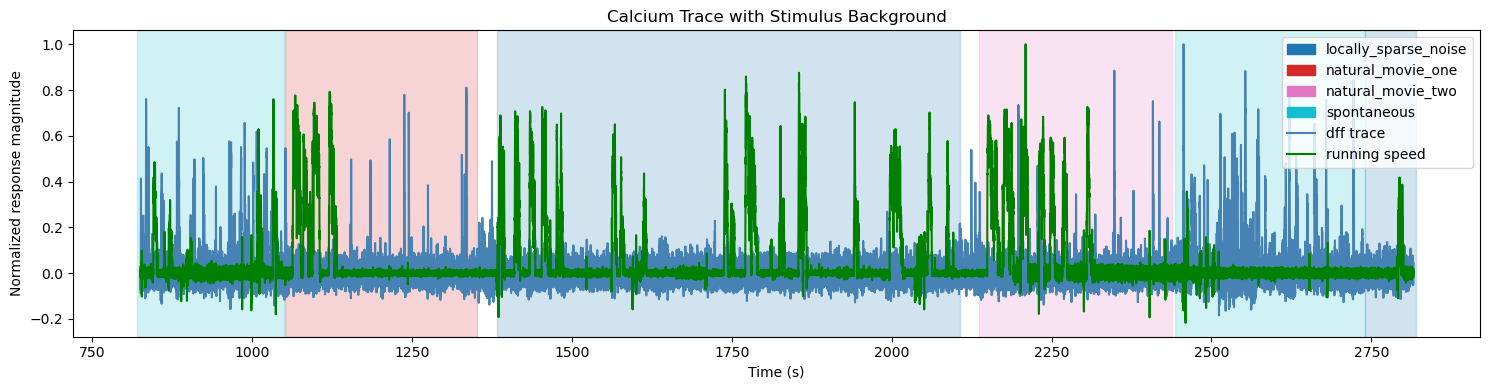

In [15]:
# Choose neuron index and time window
neuron_idx = 42
start_time = 820
duration = 2000

# Use your data
trace = traces[neuron_idx]

# Call function (without events)
plot_trace_with_stimulus(trace, time, stim_epochs, start_time, duration, behavior=True)

Running speed does not appear to be strongly correlated with neural activity in this dataset. Increases in running speed are observed when a new stimulus type is introduced. However, these observations are based on data from a single neuron over a limited time span, and the calcium traces have not yet been fully processed, making our assumptions very tentative.

## Stimulus: Locally sparse noise

From: https://allenswdb.github.io/physiology/stimuli/passive-visual-stimuli/visual-stimuli-list.html

_"The locally sparse noise stimulus consists of black and white spots flashed on the monitor. For each frame of the stimulus a small number of pixels were white and a small number were black, while the rest were mean luminance gray. The white and black spots were distributed such that no two spots were within 5 pixels of each other. Each time a given pixel was occupied by a black (or white) spot, there was a different array of other pixels occupied by either black or white spots. As a result, when all of the frames when that pixel was occupied by the black spot were averaged together, there was **no significant structure surrounding the specified pixel**. Further, the stimulus was well balanced with regards to the contrast of the pixels, such that while there was a slightly higher probability of a pixel being occupied just outside of the 5-pixel exclusion zone, the probability was equal for pixels of both contrast. Each pixel was occupied by either a white or black spot a variable number of times. Typically, each frame we presented for 0.25 seconds and followed immediately by the next trial without any intertrial interval. There are no blanksweeps."_

We generate some plots to verify key properties of the locally sparse noise stimulus as described by the Allen Institute website. 

By visualizing example frames and pixel values, we confirm the random and sparse distribution of black and white spots, as well as the absence of spatial structure around each pixel.

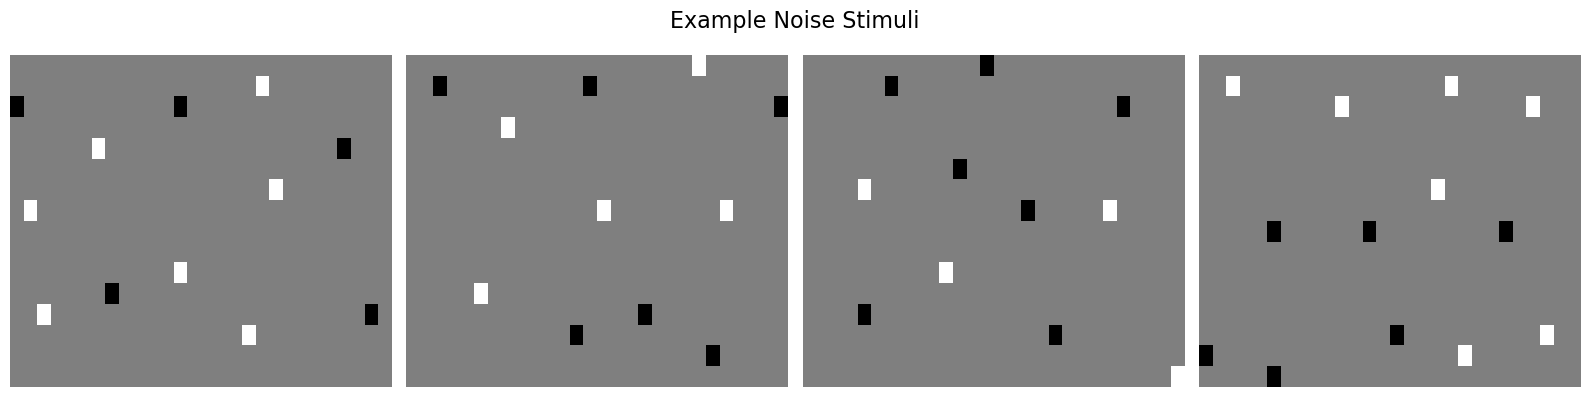

In [16]:
# Filter stim_epochs for only locally_sparse_noise
lsn_epochs = stim_epochs[stim_epochs["stimulus"] == "locally_sparse_noise"]

# Get all frames within those epochs
lsn_frame_idxs = []
for _, row in lsn_epochs.iterrows():
    start, end = row["start"], row["end"]
    matching_frames = stim_metadata[
        (stim_metadata["start"] >= start) & (stim_metadata["end"] <= end)
    ]
    lsn_frame_idxs.extend(matching_frames["frame"].values)

lsn_frame_idxs = np.array(lsn_frame_idxs)
n = len(lsn_frame_idxs)

# Pick 4 evenly spaced frame indices
example_indices = np.linspace(0, n - 1, 4, dtype=int)
example_frames = [stims[lsn_frame_idxs[i]] for i in example_indices]

# Plot them
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    axs[i].imshow(example_frames[i], cmap="grey", aspect="auto")
    axs[i].axis("off")

plt.suptitle("Example Noise Stimuli", fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
print("Unique pixel Values:")
print(np.unique(stims[0]))

Unique pixel Values:
[  0 127 255]


Plotting the frequency of active pixel counts and pixel intensity distribution helps us confirm that the stimulus is well balanced.

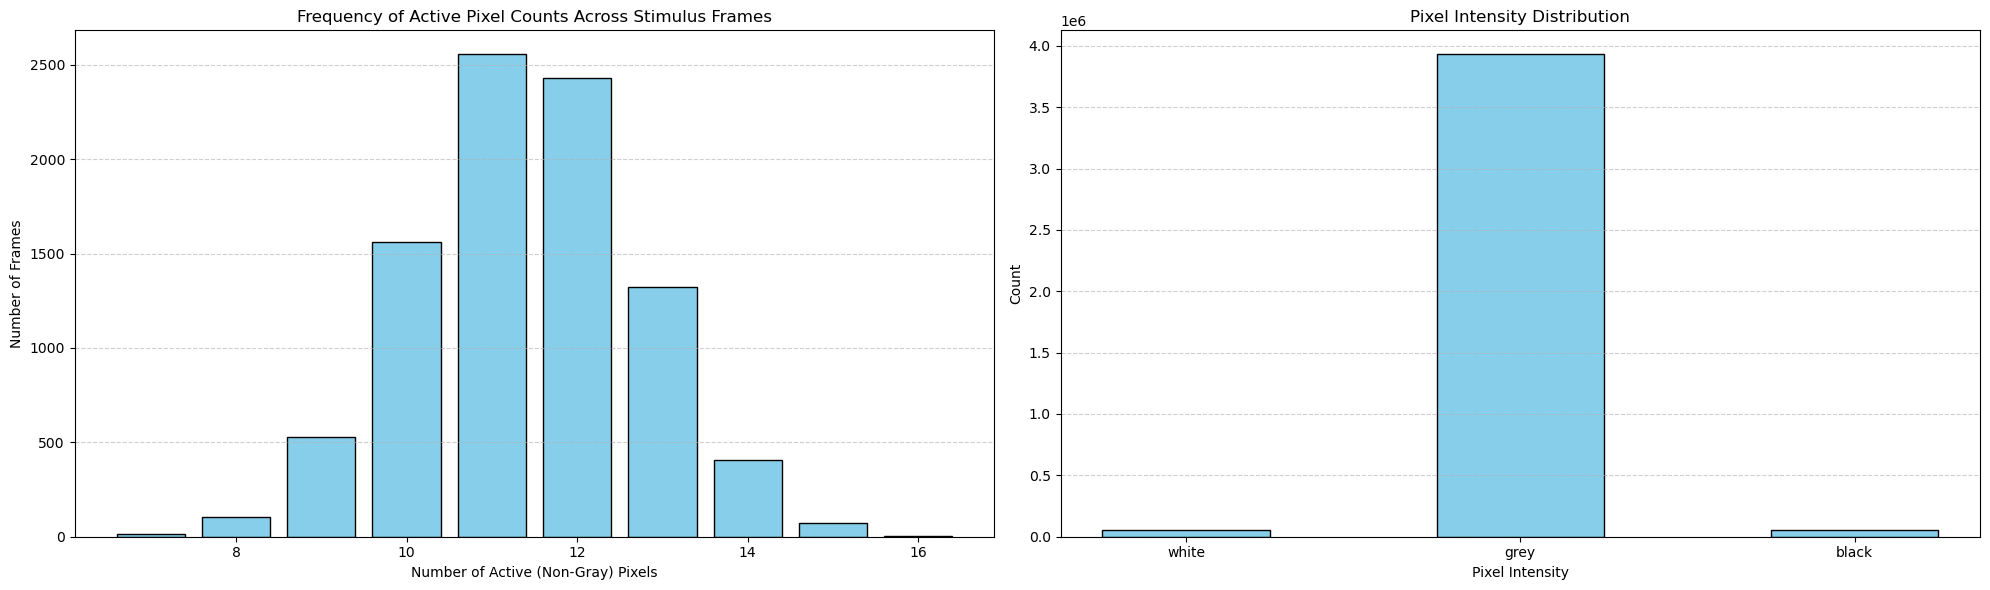

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(20, 6))

# Subplot 1: Frequency of Active Pixel Counts (Bar Plot)
gray_value = 127
non_gray_counts = np.sum(stims != gray_value, axis=(1, 2))
unique_counts, counts_frequency = np.unique(non_gray_counts, return_counts=True)

axs[0].bar(unique_counts, counts_frequency, color="skyblue", edgecolor="black")
axs[0].set_title("Frequency of Active Pixel Counts Across Stimulus Frames")
axs[0].set_xlabel("Number of Active (Non-Gray) Pixels")
axs[0].set_ylabel("Number of Frames")
axs[0].grid(axis="y", linestyle="--", alpha=0.6)

# Subplot 2: Pixel Intensity Distribution (Only 0, 127, 255)
intensity_labels = ["white", "grey", "black"]
intensity_values = [0, 127, 255]
intensity_counts = [np.sum(stims == val) for val in intensity_values]

axs[1].bar(
    [str(i) for i in intensity_labels],
    intensity_counts,
    color="skyblue",
    edgecolor="black",
    width=0.5,
)
axs[1].set_title("Pixel Intensity Distribution")
axs[1].set_xlabel("Pixel Intensity")
axs[1].set_ylabel("Count")
axs[1].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

The results show that the number of active pixels per frame is approximately normally distributed, and pixel intensities are mostly gray, with equal proportions of black (inactive) and white (active) regions. This supports the claim that the stimulus is unbiased and evenly distributed across the visual field.

Finally, averaging black/white pixel counts demonstrates that the stimulus is not biased toward any particular pixel value, ensuring that neural responses are not driven by systematic stimulus artifacts.

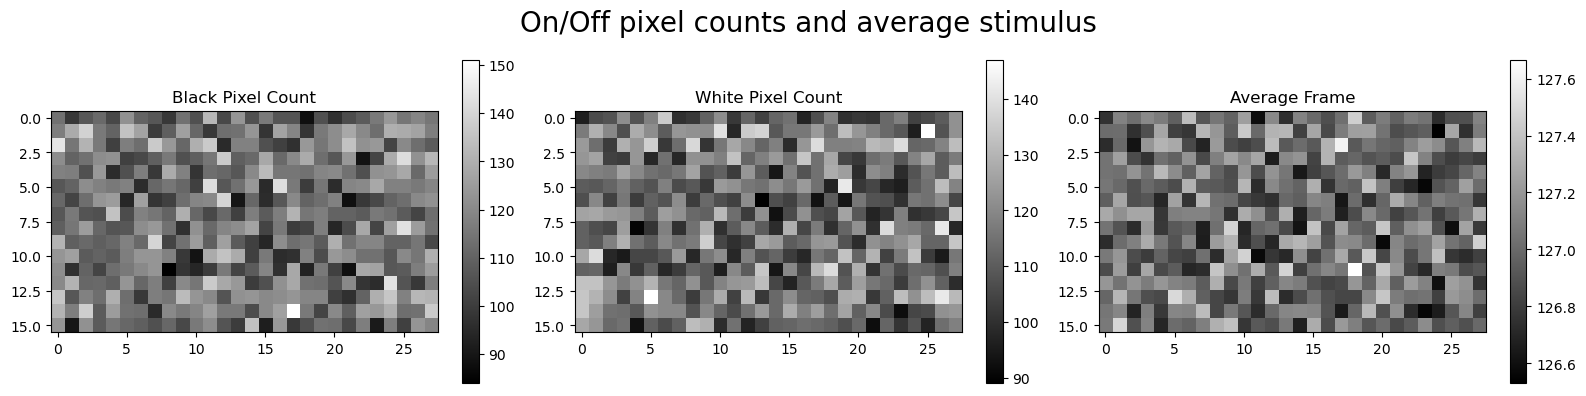

In [19]:
black_count = np.sum(stims == 0, axis=0)
white_count = np.sum(stims == 255, axis=0)
avg_frame = np.mean(stims, axis=0)

plt.figure(figsize=(16, 4))  # Adjust figure size for 1 row, 3 columns

plt.subplot(1, 3, 1)  # 1 row, 3 columns, 1st plot
plt.imshow(black_count, cmap="gray")
plt.title("Black Pixel Count")
plt.colorbar()

plt.subplot(1, 3, 2)  # 1 row, 3 columns, 2nd plot
plt.imshow(white_count, cmap="gray")
plt.title("White Pixel Count")
plt.colorbar()

plt.subplot(1, 3, 3)  # 1 row, 3 columns, 3rd plot
plt.imshow(avg_frame, cmap="gray")
plt.title("Average Frame")
plt.colorbar()

plt.suptitle("On/Off pixel counts and average stimulus", fontsize=20)

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

## ROI and max proj

Visualization of neuron segmentation and localization. 

We plot the ROI masks for individual neurons, the max intensity projection of the imaging field, and the overlay of ROI contours on the max projection to confirm accurate neuron identification. 

(-0.5, 511.5, 511.5, -0.5)

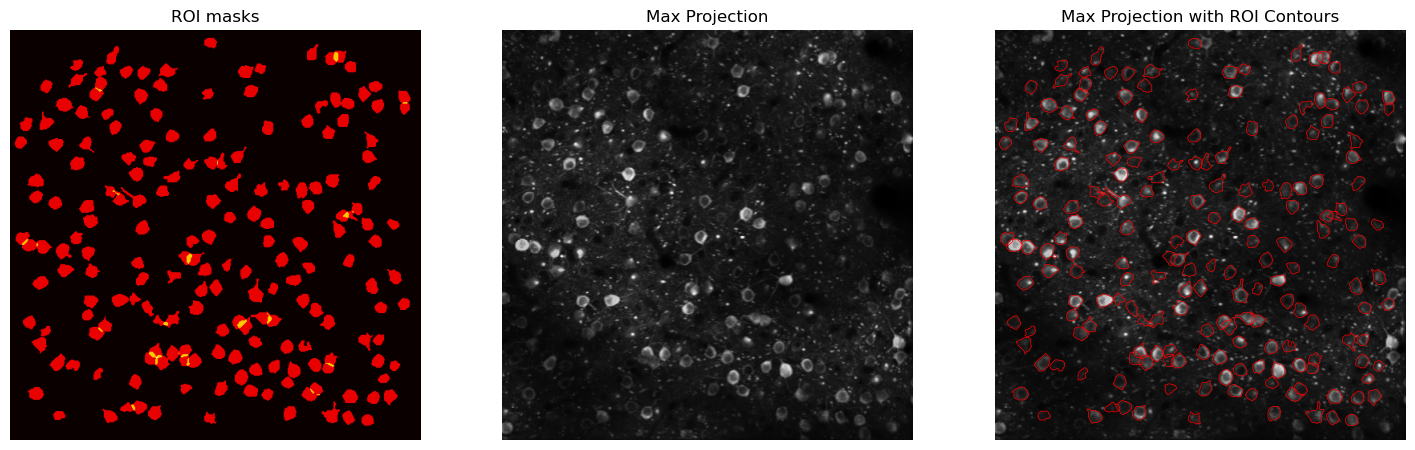

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(18, 10))
# roi masks: all of the segmented masks for cell bodies in this experiment.
ax[0].imshow(roi_masks.sum(axis=0), cmap="hot")
ax[0].set_title("ROI masks")
ax[0].axis("off")
# max projection: the projection of the full motion corrected movie for all of the cells imaged during the session.
ax[1].imshow(max_projection, cmap="grey")
ax[1].set_title("Max Projection")
ax[1].axis("off")
# max projection with ROI
ax[2].imshow(max_projection, cmap="gray")
ax[2].set_title("Max Projection with ROI Contours")
for roi in roi_masks:
    ax[2].contour(roi, levels=[0.5], colors="r", linewidths=0.5)
ax[2].axis("off")

- Left (ROI masks): This image shows the segmented regions of interest (ROIs), each corresponding to a putative neuron. The ROIs are highlighted in red and represent areas where calcium signals are extracted for further analysis.
- Middle (Max Projection): This is the maximum intensity projection of the imaging stack. It provides a clear view of the overall cellular structure and helps visualize the locations of neurons within the field of view.
- Right (Max Projection with ROI Contours): Here, the ROI contours are overlaid on the max projection image, allowing us to see how well the segmented ROIs align with the actual neurons.

# Pre-processing: 

In this preprocessing step, we apply a low-pass Butterworth filter followed by z-score normalization to the raw calcium fluorescence traces.

The low-pass filter (3rd order, cutoff frequency = 0.7 Hz) was used to remove high-frequency noise while preserving the slower dynamics of neural activity relevant to calcium imaging. 

Filtering was implemented using zero-phase forward and reverse filtering (`filtfilt`) to avoid phase distortion. 

After filtering, each neuron's trace was normalized using z-scoring, ensuring that all neurons contributed equally in scale to downstream analyses. 

This combination of smoothing and normalization enhances signal quality and comparability across neurons, which is critical for consistent receptive field estimation and model fitting.

In [21]:
# cutoff and fs and order can be manipulated
def lowpass_filter(trace, cutoff=0.7, fs=fs, order=3):
    nyq = 0.5 * fs
    norm_cutoff = cutoff / nyq
    filtered_trace = np.zeros_like(trace)
    b, a = signal.butter(order, norm_cutoff, btype="low", analog=False)
    neuron = signal.filtfilt(b, a, trace)
    return neuron


filtered_trace = lowpass_filter(traces)
normalized_trace = zscore(filtered_trace, axis=1)

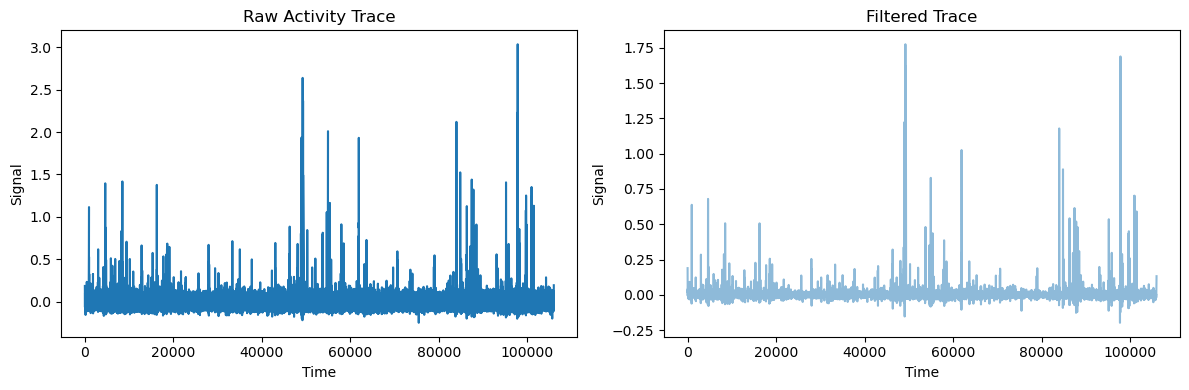

In [22]:
# Plot raw vs filtered trace
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plot filtered trace
axs[0].plot(traces[100, :])
axs[0].set_title("Raw Activity Trace")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Signal")

# Plot raw activity trace
axs[1].plot(filtered_trace[100, :], alpha=0.5)
axs[1].set_title("Filtered Trace")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Signal")

# Adjust layout
plt.tight_layout()
plt.show()

Comparing the raw and the filtered calcium signals, it can be seen how the signal is effectively smoothed and high frequency noise is removed.

# Events Extraction (Spike inference)

In this section we extract events (spikes) from the proprocessed calcium trace, we employ different methods and finally choose the best one.

To extract neural spiking events from calcium fluorescence signals, we employed three complementary spike inference approaches to ensure robustness and reliability in event detection.

1. **Simple spike thresholding** by using `scipy.signal.find_peaks`, a peak-finding algorithm that identifies local maxima in the calcium trace. This method provides a fast and intuitive way to detect large transients that likely correspond to neural firing, though it may miss smaller or overlapping events.

2. **OOPSI (Online Optimal Per Spike Inference)**, a probabilistic model-based method that estimates spike rates from calcium signals by explicitly modeling the underlying biophysical process of calcium dynamics. OOPSI assumes a generative model of calcium influx and exponential decay following neural spiking and uses Bayesian inference to estimate the most probable spike train. We used the implementation provided in the [`py-oopsi`](https://github.com/jovo/oopsi) package, which is a Python port of the original MATLAB algorithm introduced by Vogelstein et al. (2010).

3. **OASIS (Online Active Set method to Infer Spikes)**, a widely adopted and efficient deconvolution-based approach for spike inference. OASIS models the calcium trace as the convolution of a sparse spike train with a calcium response kernel and solves a constrained optimization problem to infer the most likely spike timings. Its fast, online implementation makes it well-suited for large-scale neural recordings. We used the `deconvolve` function from the [`oasis`](https://github.com/j-friedrich/OASIS) Python library, as described in Friedrich et al. (2017).

By combining these three methods—simple thresholding, Bayesian inference (OOPSI), and sparse deconvolution (OASIS)—we aimed to balance interpretability, accuracy, and computational efficiency in spike extraction. This multi-method approach provided complementary perspectives on spike timing and ensured the robustness of subsequent analyses.

## 1. Simple spike thresholding

In [23]:
def detect_spikes_single_neuron(
    trace: np.ndarray, fs: float, N: int = "N", lockout: float = 0.25
):
    """
    Detect spikes in a single calcium trace using thresholding and a lockout window.

    Returns:
        spike_idxs: Indices of detected spikes
        spike_trace: 1D float array with 1s at spike times, 0s elsewhere
    """
    threshold = N
    min_distance = max(1, int(lockout * fs))
    spike_idxs, _ = find_peaks(trace, height=threshold, distance=min_distance)
    spike_trace = np.zeros_like(trace, dtype=float)
    spike_trace[spike_idxs] = 1.0  # Impulse at spike time
    return spike_trace


def run_detect_spikes_all_neurons(data, fs=fs, N="N", lockout=0.25):
    """
    Apply spike detection to all neurons and return a 2D spike matrix (float).
    """
    n_neurons, n_timepoints = data.shape
    threshold_spikes = np.zeros((n_neurons, n_timepoints), dtype=float)

    for neuron_id in range(n_neurons):
        spike_trace = detect_spikes_single_neuron(
            data[neuron_id], fs=fs, N=N, lockout=lockout
        )
        threshold_spikes[neuron_id] = spike_trace

    return threshold_spikes

In [24]:
# Threshold for spike detection
N = 2

# Run threshold-based spike inference
threshold_spikes = run_detect_spikes_all_neurons(
    normalized_trace, fs=fs, N=N, lockout=0.25
)

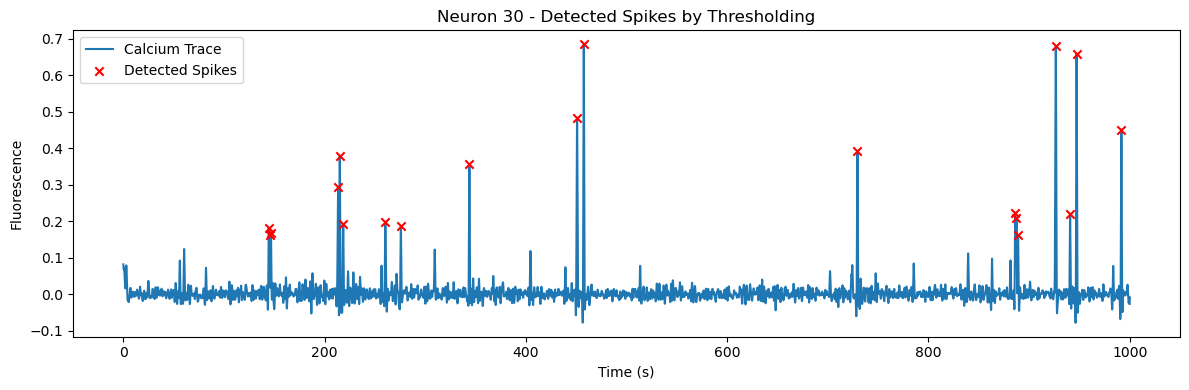

In [25]:
neuron_id = 30
trace = filtered_trace[neuron_id]  # calcium trace
spike_trace = threshold_spikes[neuron_id]  # binary spike train

# Extract spike indices where spike_trace == 1
spike_idxs = np.where(spike_trace == 1)[0]

# Plot
plot_detected_spikes(trace, spike_idxs, fs=fs, neuron_id=neuron_id, window=(0, 1000))

## 2. Spike Extraction with OOPSIE

In [26]:
# Load OOPSI results for all neurons previously calculated
oopsi_result = np.load("oopsi_results.npz")
oopsi_spikes = oopsi_result["n_traces"]

## 3. Spike Extraction with OASIS

In [27]:
# Load OASIS results for all neurons previously calculated
oasis_result = np.load("OASIS_spikes.npz")
oasis_spikes = oasis_result["spike_likelihoods"]

## Comparison of Spike Inference Methods

### 1. Visualization of spikes

First, we performed a brief **visual analysis of the inferred spikes** to qualitatively assess the behavior of each spike detection method. This included three components.

1. We plotted the original calcium fluorescence trace overlaid with the inferred spikes from each method (thresholding, OOPSI, and OASIS) for selected neurons. This visualization helps evaluate how well each method aligns with the prominent calcium transients and whether it captures the expected timing and structure of spiking events.

2. We generated a **raster plot** of the OOPSI-inferred spikes aligned with the stimulus presentation. This allows us to assess whether the inferred neural responses show any time-locked structure or stimulus-driven activation across trials and neurons.

3. Finally, we computed the **population firing rate over time** using the OOPSI spike estimates, giving an aggregate view of overall neural activity across the population. This can reveal stimulus-evoked dynamics, shared network responses, or periods of increased excitability.


For the last two plots, we focused only on the OOPSI-inferred spikes, as the first plot showed that their behavior closely resembled that of the OASIS-inferred spikes.

In [28]:
# Example neuron for visualization
example_neuron = normalized_trace[60, :]

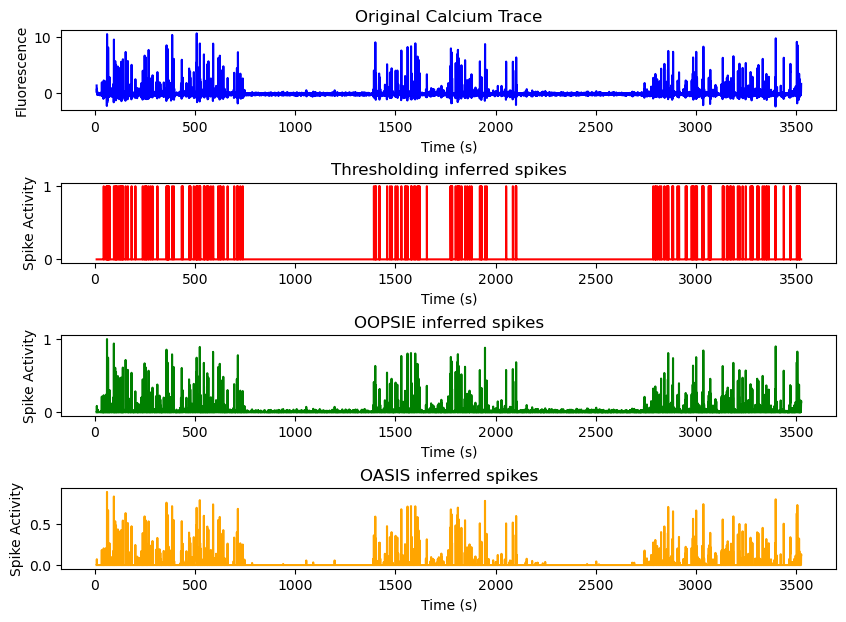

In [29]:
fig, axs = plt.subplots(
    4, 1, figsize=(10, 7), height_ratios=[1, 1, 1, 1], gridspec_kw=dict(hspace=0.9)
)

# Plot 1: Original Calcium Trace
axs[0].plot(time, example_neuron, label="Original Calcium", color="blue")
axs[0].set_ylabel("Fluorescence")
axs[0].set_xlabel("Time (s)")
axs[0].set_title("Original Calcium Trace")

# Plot 2: Thresholding Inferred Spikes
axs[1].plot(time, threshold_spikes[60], label="Inferred Spikes", color="red")
axs[1].set_ylabel("Spike Activity")
axs[1].set_xlabel("Time (s)")
axs[1].set_title("Thresholding inferred spikes")

# Plot 3: OOPSI Inferred Spikes
axs[2].plot(time, oopsi_spikes[60, :], label="Inferred Spikes", color="green")
axs[2].set_ylabel("Spike Activity")
axs[2].set_xlabel("Time (s)")
axs[2].set_title("OOPSIE inferred spikes")

# Plot 4: OASIS Inferred Spikes
axs[3].plot(time, oasis_spikes[60, :], label="Inferred Spikes", color="ORANGE")
axs[3].set_ylabel("Spike Activity")
axs[3].set_xlabel("Time (s)")
axs[3].set_title("OASIS inferred spikes")

plt.show()

The thresholding-inferred spikes appear as discrete, binary events, while the OOPSI and OASIS methods produce continuous-valued spike estimates. This reflects the underlying modeling approaches—thresholding imposes hard cutoffs, whereas OOPSI and OASIS model spike probabilities or rates over time.

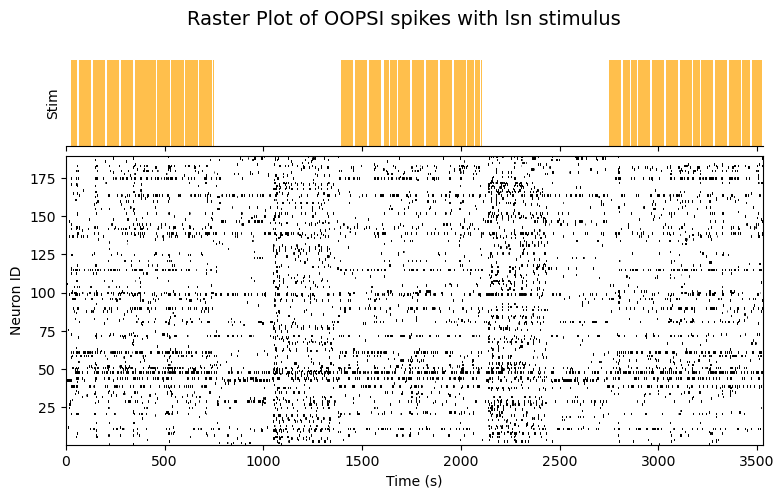

In [30]:
plot_raster_with_stimulus(
    oopsi_spikes,
    stim_epochs,
    stim_metadata,
    stimulus_name="locally_sparse_noise",
    threshold=0.2,
    sampling_rate=30,
    figsize=(9, 5),
    title="Raster Plot of OOPSI spikes with lsn stimulus",
)

The raster plot displays OOPSI-inferred spike activity across the neuron population, with locally sparse noise (lsn) stimulus timing indicated by orange bars. While some rhythmic, coordinated spiking is observed among neurons, these events are not strongly time-locked to the lsn stimulus presentation.

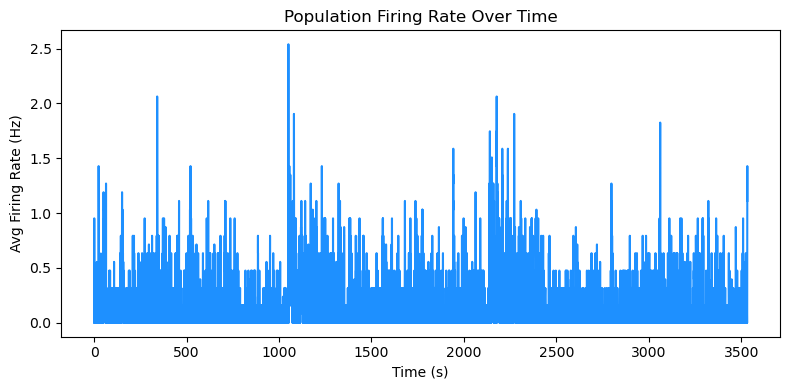

In [31]:
plot_population_firing_rate(
    oopsi_spikes, bin_size=2, sampling_rate=30, threshold=0.2, figsize=(8, 4)
)

The population firing rate over time offers a smoothed, aggregate view of neural activity across all neurons. 

### 2. Spike normalization

To ensure a fair and meaningful comparison between different spike inference methods, we first normalized the inferred spike trains across methods. This step is particularly important because methods like OASIS and OOPSI output continuous-valued spike estimates, where values may not reach 1 and often reflect spike probability or intensity rather than binary events. In contrast, our custom threshold-based approach directly produces binary spike trains (0 or 1), making it inherently discrete. To bring all methods onto a comparable scale, we normalized the OOPSI and OASIS outputs using z-score normalization and applied a common threshold (e.g., 0.2) to binarize the events. This allowed us to extract spike times consistently across methods and to quantify the number of detected spikes per neuron. These normalized and thresholded spike events were then converted into dataframes for systematic comparison, enabling both numerical summaries and visual analyses of spike detection performance.

In [32]:
def normalize_spikes(spike_array):
    """
    Normalize spike traces to [0, 1] range neuron-wise.

    Args:
        spike_array: 2D numpy array (neurons x timepoints)

    Returns:
        Normalized 2D numpy array of same shape.
    """
    norm_spikes = np.zeros_like(spike_array, dtype=float)
    for i in range(spike_array.shape[0]):
        trace = spike_array[i]
        if np.max(trace) != np.min(trace):  # avoid division by zero
            norm_spikes[i] = minmax_scale(trace)
        else:
            norm_spikes[i] = trace  # all-zero trace stays zero
    return norm_spikes

In [33]:
# Create DataFrames for more clear storag

# DataFrame for OOPSI and OASIS spikes
def spikes_to_df(spikes_array, fs, threshold=0.2):
    """
    Convert normalized spike traces into DataFrame of spike events using threshold.

    Args:
        spikes_array: 2D numpy array (neurons × timepoints), normalized [0,1]
        fs: sampling frequency in Hz
        threshold: value above which a spike is counted

    Returns:
        pd.DataFrame with columns: Neuron, TimeIdx, Time (seconds)
    """
    spike_events = []
    n_neurons, n_timepoints = spikes_array.shape

    for neuron_id in range(n_neurons):
        spike_idxs = np.where(spikes_array[neuron_id] > threshold)[0]
        for idx in spike_idxs:
            spike_events.append({"Neuron": neuron_id, "TimeIdx": idx, "Time": idx / fs})

    return pd.DataFrame(spike_events)


# DataFrame for thresholding spikes
def threshold_spikes_to_df(spikes_array, fs):
    """
    Convert binary threshold spikes array to DataFrame of spike events.

    Args:
        spikes_array: 2D numpy array (neurons x timepoints), binary 0/1
        fs: sampling frequency in Hz

    Returns:
        pd.DataFrame with columns: Neuron, TimeIdx, Time (seconds)
    """
    spike_events = []
    n_neurons, n_timepoints = spikes_array.shape
    for neuron_id in range(n_neurons):
        spike_idxs = np.where(spikes_array[neuron_id] == 1)[0]
        for idx in spike_idxs:
            spike_events.append({"Neuron": neuron_id, "TimeIdx": idx, "Time": idx / fs})
    return pd.DataFrame(spike_events)

In [34]:
# Normalize spikes for OOPSI and OASIS
oopsi_spikes_norm = normalize_spikes(oopsi_spikes)
oasis_spikes_norm = normalize_spikes(oasis_spikes)

# Threshold values for spike detection after normalization
oopsi_threshold = 0.2
oasis_threshold = 0.2

# Convert normalized spikes to DataFrames of events
oopsi_df = spikes_to_df(oopsi_spikes_norm, fs=fs, threshold=oopsi_threshold)
oasis_df = spikes_to_df(oasis_spikes_norm, fs=fs, threshold=oasis_threshold)

# Convert binary threshold spikes to DataFrame
threshold_df = threshold_spikes_to_df(threshold_spikes, fs=fs)

# Count spikes per neuron for each method
spike_counts_threshold = threshold_df["Neuron"].value_counts().sort_index()
spike_counts_oopsi = oopsi_df["Neuron"].value_counts().sort_index()
spike_counts_oasis = oasis_df["Neuron"].value_counts().sort_index()

# Combine into one single DataFrame:
spike_counts_df = (
    pd.DataFrame(
        {
            "Threshold": spike_counts_threshold,
            "OOPSI": spike_counts_oopsi,
            "OASIS": spike_counts_oasis,
        }
    )
    .fillna(0)
    .astype(int)
)

print("\nSpike Counts Per Neuron:\n")
print(spike_counts_df)


Spike Counts Per Neuron:

        Threshold  OOPSI  OASIS
Neuron                         
0              24    115    129
1              21    134    136
2              34    480    466
3              77    180    184
4              19    153    143
...           ...    ...    ...
184            31    105    106
185            48     83     92
186            39    298    318
187            46    737    718
188            43    348    388

[189 rows x 3 columns]


### 3. Correlation Analysis

To evaluate the consistency between spike inference methods, we computed pairwise Pearson correlations based on the number of detected spikes per neuron across methods. This correlation matrix was visualized using a heatmap, where higher correlation values indicate stronger agreement between methods in terms of spike detection frequency. Additionally, we generated a pairplot of spike counts, which displays scatter plots for all method pairs along with kernel density estimates (KDEs) on the diagonal. This visualization provides a more detailed view of the relationships and potential biases between methods, revealing whether some systematically over- or under-estimate spike counts relative to others. Together, these analyses help assess the degree of alignment and reliability among the different spike inference techniques used in this study.


In [35]:
correlations = spike_counts_df.corr()

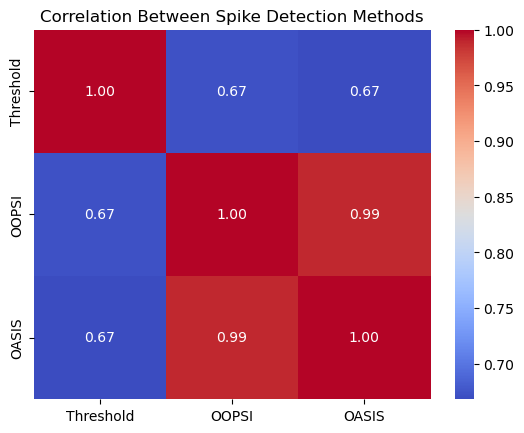

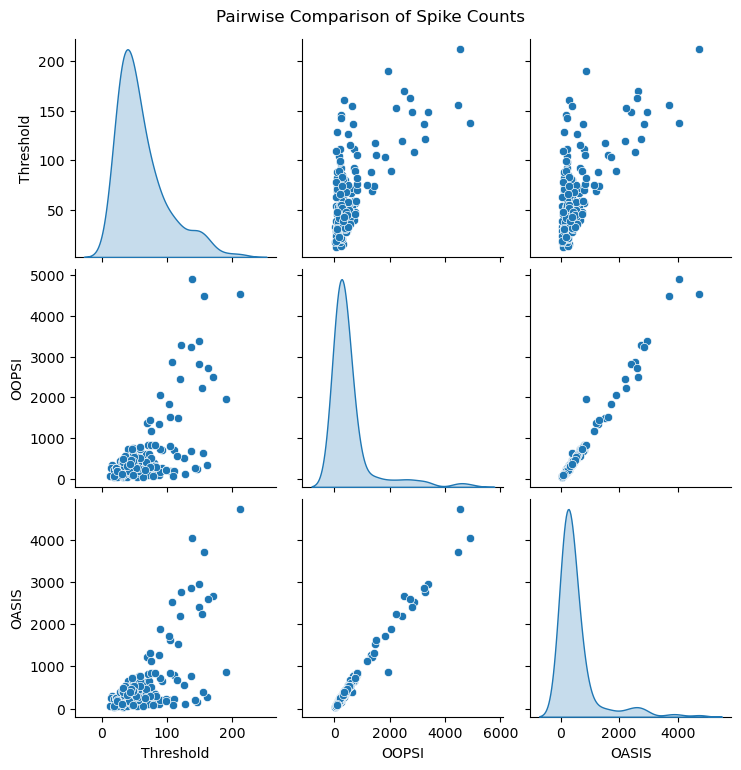

In [36]:
# Visualize correlations

# Heatmap visualization
sns.heatmap(correlations, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Spike Detection Methods")
plt.show()

# Pairwise comparison visualization
sns.pairplot(spike_counts_df, diag_kind="kde")
plt.suptitle("Pairwise Comparison of Spike Counts", y=1.02)
plt.show()

From the plots above, it can be observed that the OOPSI and OASIS spike inference methods yield extremely similar results, with a Pearson correlation coefficient of 0.99 in terms of total spike counts per neuron. This near-perfect agreement suggests that both model-based approaches are capturing highly consistent neural dynamics and likely share similar assumptions about calcium kinetics and noise characteristics. In contrast, both OOPSI and OASIS show moderate correlations of 0.67 with the thresholding-based method, indicating a noticeable divergence. This suggests that thresholding captures some broad trends in spiking activity but may miss subtler events or overcount spurious transients due to its lack of temporal smoothing or biophysical modeling.

The pairwise distribution plots reinforce these findings. They show a tight, linear relationship between OOPSI and OASIS spike counts across neurons, while the thresholding method displays a wider spread when compared to either. This spread reflects inconsistencies in spike detection, particularly for neurons with intermediate levels of activity. Furthermore, the kernel density estimates (KDEs) along the diagonal reveal that OOPSI and OASIS produce more similar spike count distributions—typically unimodal and centered—while the thresholding method sometimes yields broader or skewed distributions. These visual and statistical comparisons together support the conclusion that model-based methods (OOPSI and OASIS) provide more consistent and reliable spike inference than simple thresholding, especially for subtle or noisy calcium signals.

In terms of computational efficiency, the thresholding method is extremely fast but lacks accuracy. OOPSI provides more reliable results but is computationally slow. OASIS, on the other hand, matches the speed of thresholding while delivering high-quality spike inference.

**Given these findings, we decided to carry out the subsequent analysis with the results yielded by the OASIS spike inference method.**

# Receptive Fields Estimation

Here, we use the extracted spikes and the relevant stimuli to estimate the receptive fields. We apply a variety of methods, visualize the results, and lastly perform a comparative analysis.

For receptive field estimation, we implemented the following methods:

1. Spike-Triggered Average (STA)

2. Linear-Nonlinear Poisson (LNP), with an additional variant incorporating Lasso regularization

3. Methods from the **RFEst v2** Python toolbox: https://github.com/berenslab/RFEst?tab=readme-ov-file. (tutorial notebooks for this library: https://github.com/huangziwei/notebooks_RFEst)

Further details on each method will be provided in the following subsections.


## 1. Spike-Triggered Average

To estimate receptive fields using the Spike-Triggered Average (STA), we implemented a classical approach that averages the stimuli preceding each spike. This method assumes that spikes are more likely to follow specific stimulus patterns, and by aligning and averaging the preceding stimuli across spike events, we can infer the features to which a neuron is most sensitive. In our implementation, both the spike trains and stimulus sequences are binned to reduce temporal resolution and noise. We then compute the average stimulus over a fixed number of preceding time bins (`n_lags`) for all spike events, resulting in a spatiotemporal STA that captures how stimulus features across time contribute to a neuron’s response.

In [37]:
def compute_sta_for_neuron(
    spike_trace, stims, stim_metadata, Dx, Dy, bin_size=2, n_lags=7
):
    """
    Compute spike-triggered average (STA) for a single neuron.

    Args:
        neuron_id (int): ID of neuron.
        spike_traces (ndarray): Shape (n_neurons, n_frames)
        stims (ndarray): Shape (n_unique_stims, Dx, Dy)
        stim_metadata (pd.DataFrame): Must contain 'frame', 'start', 'end'
        Dx, Dy (int): Stimulus dimensions
        bin_size (int): Number of frames per bin
        n_lags (int): Number of time bins to look back

    Returns:
        sta (np.ndarray): shape (n_lags, Dx, Dy)
    """
    n_frames = spike_trace.shape[0]
    stim_trace = np.full((n_frames, Dx, Dy), 0.0, dtype=np.float32)

    # Fill stimulus trace
    for i, row in stim_metadata.iterrows():
        stim_idx = row["frame"]
        start = row["start"]
        end = row["end"]
        stim_trace[start:end] = np.tile(stims[stim_idx], (end - start, 1, 1))

    # Bin spikes and stimuli

    n_bins = n_frames // bin_size
    n_trim = n_bins * bin_size

    spikes_binned = spike_trace[:n_trim].reshape(n_bins, bin_size).sum(axis=1)
    stim_binned = stim_trace[:n_trim].reshape(n_bins, bin_size, Dx, Dy).mean(axis=1)

    # Flatten stimuli
    pixels = Dx * Dy
    stim_flat = stim_binned.reshape(n_bins, pixels).T  # shape: (pixels, n_bins)

    # Compute STA
    sta = np.zeros((pixels, n_lags))
    valid_spike_count = 0

    for i in range(n_lags, n_bins):
        spike_val = spikes_binned[i]
        if spike_val > 0:
            sta += stim_flat[:, i - n_lags : i] * spike_val
            valid_spike_count += spike_val

    sta /= valid_spike_count + 1e-10  # avoid divide-by-zero
    return sta

In [38]:
def compute_sta_for_neuron_list(
    neuron_ids, oasis_spikes, stims, stim_metadata, bin_size=2, n_lags=7
):
    """
    Compute STAs for a list of neuron indices.

    Returns:
        stas (np.ndarray): shape (n_neurons, n_lags, Dx, Dy)
    """
    Dx, Dy = stims.shape[1:]
    stas = []

    for neuron_id in neuron_ids:
        spike_trace = oasis_spikes[neuron_id]
        sta = compute_sta_for_neuron(
            spike_trace,
            stims,
            stim_metadata,
            Dx,
            Dy,
            bin_size=bin_size,
            n_lags=n_lags,
        )
        stas.append(sta)

    return np.stack(stas, axis=0)  # shape: (n_neurons, n_lags, Dx, Dy)

### 1.1 STA visualization

Given that our dataset contains calcium traces for 189 neurons, we selected the top five most active neurons as well as neurons with ON/OFF bursting activity for STA visualization.

#### Highest activity neurons:

In [39]:
# Top 5 most active neurons

# Choose a spike detection threshold
spike_threshold = np.percentile(oasis_spikes, 99)

# Binary spike detection
binary_spikes = oasis_spikes > spike_threshold

# Count spikes per neuron
spike_counts = binary_spikes.sum(axis=1)

# Sort to find most active
top_5_active = np.argsort(spike_counts)[-5:]

# Parameters
bin_size = 2
Dx, Dy = stims.shape[1:]
n_lags = 7

In [40]:
# Top 5 most active neurons implementation

active_stas = compute_sta_for_neuron_list(
    top_5_active, oasis_spikes, stims, stim_metadata, bin_size=bin_size, n_lags=n_lags
)

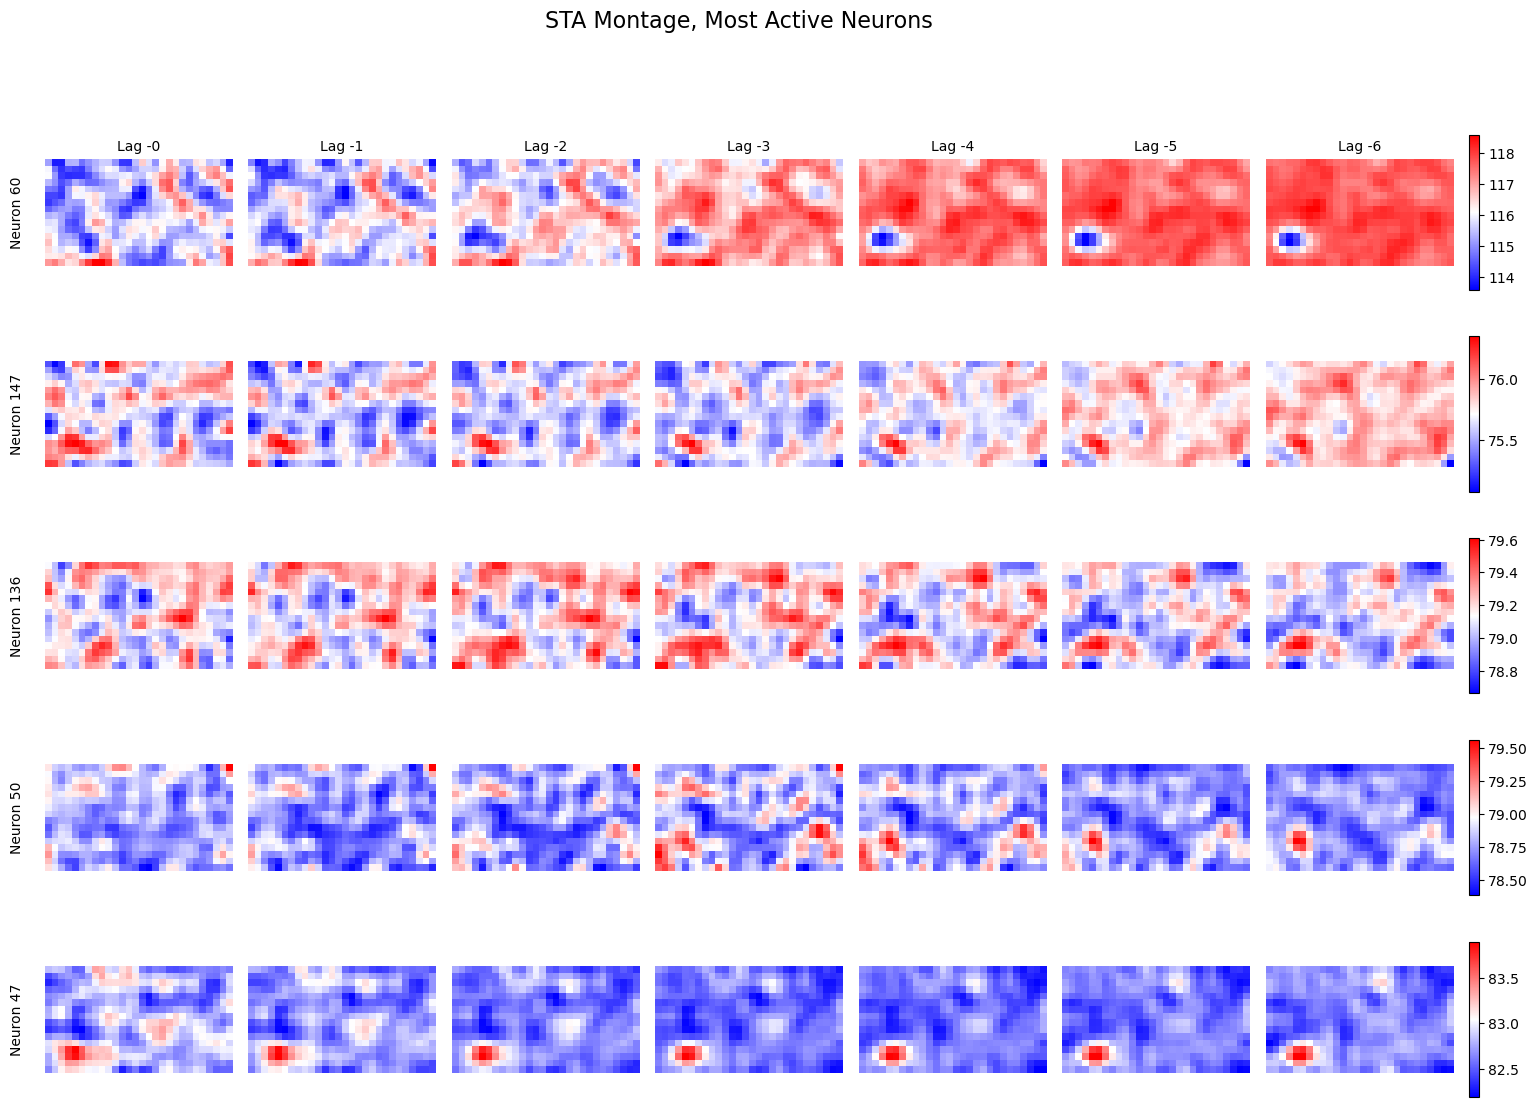

In [41]:
# Top 5 most active neurons plot
plot_sta_grid(
    active_stas,
    top_5_active,
    Dx,
    Dy,
    cmap="bwr",
    title="STA Montage, Most Active Neurons",
    vmin=None,
    vmax=None,
)

As the number of lags increases from 0 to 6, the receptive field becomes progressively clearer and more defined, reflecting how the neuron integrates stimulus information over time. Early lags capture immediate stimulus effects, while later lags reveal stronger and more spatially structured features, indicating typical processing delays before the neuron’s response peaks. This temporal sequence of receptive fields illustrates the dynamic nature of neural encoding, where the neuron’s response is not instantaneous but builds up over several time steps, integrating stimulus information across a short temporal window. The later lags capture delayed but significant contributions to neural activity, likely reflecting synaptic and network processing delays. Together, these findings highlight the importance of considering spatiotemporal dynamics to fully characterize how neurons encode patterns unfolding over time rather than relying solely on instantaneous inputs.

#### Burst-like activity neurons:

Here we identify neurons that exhibit distinct periods of activity separated by inactivity, commonly referred to as ON/OFF or burst-like activity. These neurons show multiple, clearly separated bouts of spiking, indicating they are active in discrete episodes rather than continuously. This pattern is often associated with neurons that respond selectively to specific stimuli or conditions.

In [42]:
# ON/OFF activity neurons
def count_active_bouts(spike_trace, threshold=0.2, min_gap=20):
    # Binary thresholded spike presence
    binary = spike_trace > threshold
    # Label connected regions (bouts of activity)
    labeled, n_bouts = label(binary)
    return n_bouts


# Apply to all neurons
bouts_per_neuron = np.array([count_active_bouts(trace) for trace in oasis_spikes])

# ON-OFF-like behavior: neurons with ~2 or more clear bouts
on_off_like_indices = np.where((bouts_per_neuron >= 90))[0]
on_off_like_indices = on_off_like_indices[5:10]

In [43]:
# ON/OFF activity neurons implementation

onoff_stas = compute_sta_for_neuron_list(
    on_off_like_indices,
    oasis_spikes,
    stims,
    stim_metadata,
    bin_size=bin_size,
    n_lags=n_lags,
)

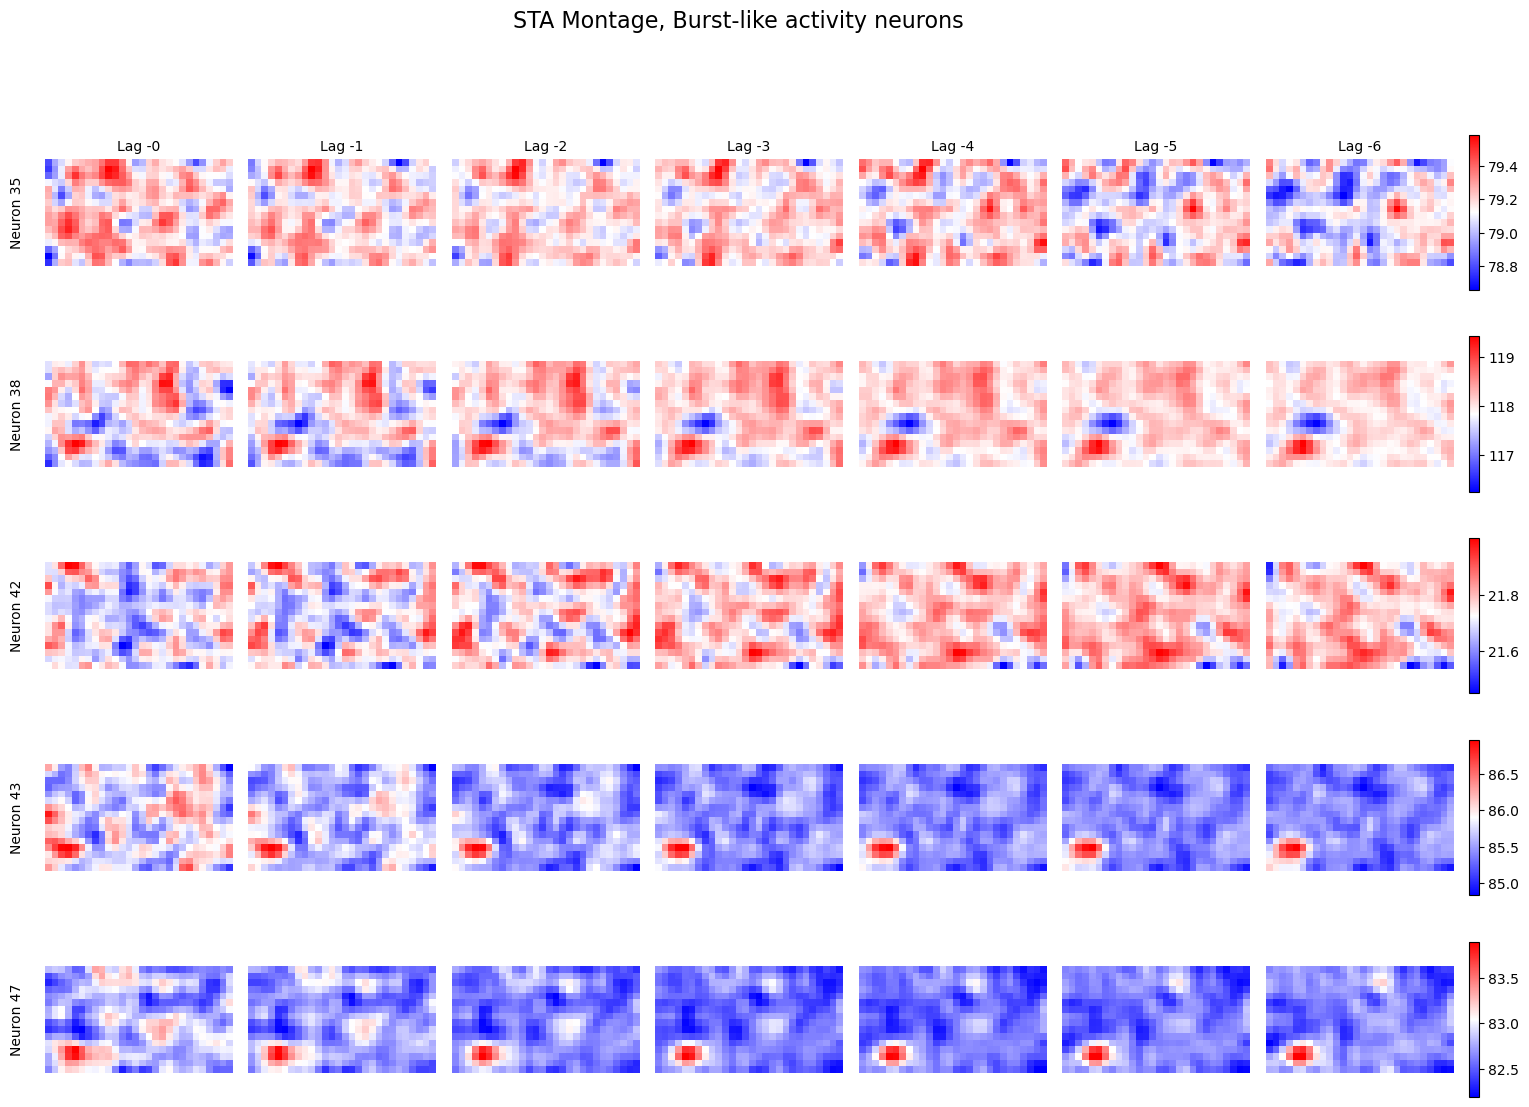

In [44]:
# ON/OFF activity neurons plot
plot_sta_grid(
    onoff_stas,
    on_off_like_indices,
    Dx,
    Dy,
    cmap="bwr",
    title="STA Montage, Burst-like activity neurons",
    vmin=None,
    vmax=None,
)

The receptive fields across time indicate consistent spatial structure, which implies the spike-triggered bursts are not noise-driven but likely related to meaningful visual stimulus features. The clear polarity (ON/OFF) and temporal evolution of the RFs support the classification of these units as bursting sensory neurons with structured visual selectivity.

More in detail:
- Neuron 35 and Neuron 38 show complex mixed ON/OFF features with both excitatory (red) and inhibitory (blue) regions, suggesting involvement in detecting transient or mixed polarity visual stimuli.
- Neuron 42 exhibits mostly positive (ON-like) activity across lags, implying it might be responsive to light increments in its visual field before spike bursts.
- Neuron 43 and Neuron 47 display prominent blue (OFF-like) components across all lags, indicating they likely respond to light decrements and may be specialized for detecting darkening events or stimulus offsets.

### 1.2 Spatial temporal kernel

To better interpret the receptive field (RF) obtained from the spike-triggered average (STA), we decompose it into **spatial** and **temporal** components using **Singular Value Decomposition (SVD)**. The STA is originally a 3D array representing spatial dimensions (pixels) over multiple time lags.

We first reshape the STA into a 2D matrix, where each row corresponds to a spatial pixel (flattened), and each column corresponds to a time lag. This matrix captures how each pixel's intensity at each time lag relates to the neuron’s activity.

The key assumption here is **separability**: the neuron’s response can be approximated as the product of a spatial pattern and a temporal pattern, independently influencing firing.

Using SVD on the reshaped and mean-centered STA matrix, we factorize it into three matrices, which allows us to extract:

* A **spatial kernel**: a vector representing the spatial pattern of stimulus pixels most relevant to the neuron, reshaped back to the original spatial dimensions (width × height).
* A **temporal kernel**: a vector representing how the neuron’s firing depends on stimulus history over time (the temporal lags).

The first spatial and temporal singular vectors capture the dominant features of the receptive field, providing a compact and interpretable summary. This decomposition simplifies comparisons across neurons and different estimation methods by separating the spatial and temporal contributions to neural responses.


In [45]:
def compute_spatial_temporal_kernel(sta, Dx, Dy, n_lags, bin_size, neuron_id):

    # --- SVD
    pixels = Dx * Dy
    sta_matrix = sta.reshape(pixels, n_lags)
    sta_centered = sta_matrix - sta_matrix.mean(axis=1, keepdims=True)

    U, S, VT = np.linalg.svd(sta_centered, full_matrices=False)
    spatial_kernel = U[:, 0].reshape(Dx, Dy)
    temporal_kernel = VT[0, :]
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(spatial_kernel, cmap="bwr")
    plt.colorbar()
    plt.title("Spatial Kernel")

    plt.subplot(1, 2, 2)
    time_axis = np.arange(-n_lags, 0) * bin_size * 1000 / 30  # ms
    plt.plot(time_axis, temporal_kernel)
    plt.xlabel("Time before spike (ms)")
    plt.title("Temporal Kernel")
    plt.grid(True)
    plt.suptitle(f"Spatial and temporal kernel for neuron {neuron_id}", fontsize = 14)
    plt.tight_layout()
    plt.show()

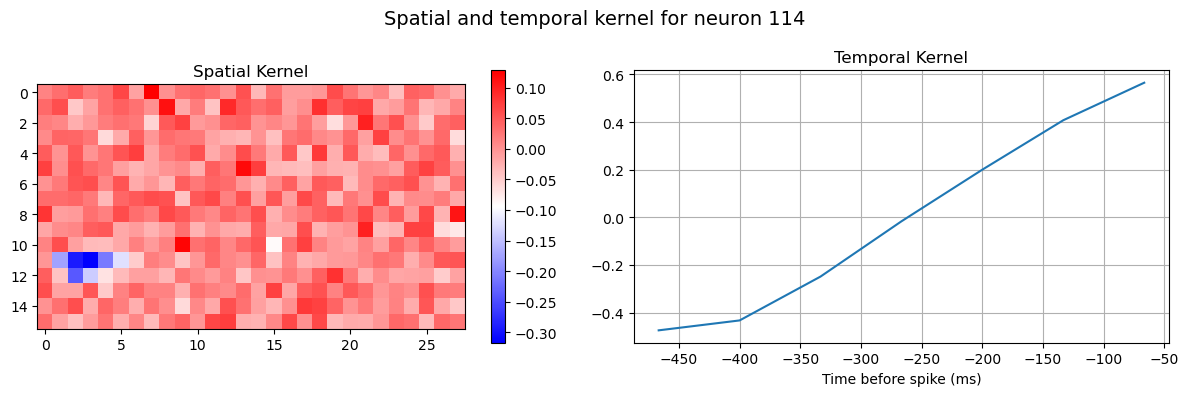

In [46]:
spike_trace = oasis_spikes[114]
sta = compute_sta_for_neuron(
    spike_trace, stims, stim_metadata, Dx, Dy, bin_size, n_lags
)
compute_spatial_temporal_kernel(sta, Dx, Dy, n_lags, bin_size, neuron_id = 114)

The spatial kernel being mostly red with a blue spot in the lower left corner suggests a strong localized feature, likely an excitatory center (blue spot) surrounded by a broader inhibitory region (red). This spatial pattern indicates the neuron is selectively responsive to stimuli in that specific area of the visual field, with opposite effects around it, consistent with center-surround receptive field organization.

The temporal kernel’s linear positive increase implies that the neuron’s response builds up steadily over time before the spike, reflecting an accumulating excitatory influence from the stimulus. This gradual rise suggests the neuron integrates incoming signals over a temporal window, rather than responding instantly, which aligns with the interpretation that the neuron’s activity depends on stimulus dynamics unfolding in the recent past. Together, these kernels reveal how the neuron combines spatially localized stimulus features with temporally extended integration to generate its firing pattern.

## 2. Linear-Nonlinear Poisson (LNP)

In this implementation, we model the neuron’s response using the Linear-Nonlinear-Poisson (LNP) framework, which captures how the stimulus is first linearly filtered by the receptive field, then passed through a nonlinear function (exponential here) to produce a firing rate, and finally generates spikes probabilistically via a Poisson process. This approach is more realistic than simple spike-triggered averaging because it explicitly accounts for neural noise and nonlinear response properties.

To fit the model, we use Poisson likelihood maximization, optimizing the receptive field weights to best explain the observed spike counts given the stimuli across multiple time lags. The optimization uses L-BFGS-B, a robust gradient-based method, to find weights that maximize the likelihood while maintaining numerical stability through clipping and regularization.

By incorporating lags, the model captures how past stimulus frames influence the current response, reflecting temporal integration in neural processing. Overall, this method provides a principled and interpretable estimate of the spatiotemporal receptive field, improving on simpler linear methods by embracing both nonlinearity and noise inherent in neural data.


In [47]:
# Initialize parameters

neuron_id = 60
spike_threshold = 0.2
bin_size = 2
lags = [0, 1, 2, 3, 4]
R = 50
frame_rate_hz = 30
frame_dt = 1.0 / frame_rate_hz

In [48]:
# 1. Compute spike counts


def compute_spike_counts_from_trace(spike_trace, stim_metadata, valid_frame_indices):
    counts = []
    for idx in valid_frame_indices:
        row = stim_metadata.iloc[idx]
        start = int(row["start"])
        end = int(row["end"])
        # Sum deconvolved spikes (can be fractional). If you prefer "counts",
        # you could round or threshold here, but we are explicitly *not* thresholding.
        counts.append(np.sum(spike_trace[start:end]))
    return np.asarray(counts, dtype=float)

In [49]:
# 2. Gather the stimulus frames without binninb
def gather_stimulus_frames(stim_metadata, stims, valid_frame_indices):
    frame_ids = stim_metadata.iloc[valid_frame_indices]["frame"].values.astype(int)
    stim_list = [stims[f] for f in frame_ids]
    return np.stack(stim_list, axis=0)

In [50]:
# 3. Get valid stimulus frame indices

lsn_epochs = stim_epochs[stim_epochs["stimulus"] == "locally_sparse_noise"]
valid_indices = []
for _, row in lsn_epochs.iterrows():
    valid = stim_metadata[
        (stim_metadata["start"] >= row["start"]) & (stim_metadata["end"] <= row["end"])
    ]
    valid_indices.extend(valid.index.tolist())

# Sort (just in case epochs appended out of order)
valid_indices = sorted(valid_indices)

In [51]:
# 4. Compute *framewise* spike counts

framewise_spike_counts = compute_spike_counts_from_trace(
    oasis_spikes[neuron_id, :], stim_metadata, valid_indices
)

In [52]:
# 5. Gather matching stimulus frames
stims_framewise = gather_stimulus_frames(stim_metadata, stims, valid_indices)

# Sanity alignment
assert len(framewise_spike_counts) == stims_framewise.shape[0], (
    "Spike counts and stimulus frames length mismatch: "
    f"{len(framewise_spike_counts)} vs {stims_framewise.shape[0]}"
)

In [53]:
# 6. Normalize stimuli (z-score across all selected frames)

stim_mean = stims_framewise.mean()
stim_std = stims_framewise.std()
if stim_std == 0:
    raise ValueError("Stimulus std is zero; cannot z-score.")
stims_norm = (stims_framewise - stim_mean) / stim_std

In [54]:
# 7. LNP Model Fitting


def fit_receptive_field_lnp(spike_counts, stims, lags, dt, R=50):
    """Fit a space-time LNP receptive field using Poisson likelihood.

    Parameters
    ----------
    spike_counts : (T,) array of spike counts per frame.
    stims        : (T, Dx, Dy) array of stimuli (already normalized if desired).
    lags         : list of non-negative integers specifying #frames back.
    dt           : float, duration (s) per frame.
    R            : scalar gain multiplying exp(linear drive).

    Returns
    -------
    rf : (Dx, Dy, n_lags) array of fitted weights.
    """
    Dx, Dy = stims.shape[1:]
    n_frames = stims.shape[0]
    stim_reshaped = stims.reshape(n_frames, Dx * Dy).T  # (Px, T)
    w_hat = np.zeros((Dx * Dy, len(lags)))

    for i, lag in enumerate(lags):
        if lag > 0:
            s_lag = stim_reshaped[:, :-lag]  # drop last 'lag' frames of stim
            c_lag = spike_counts[lag:]  # drop first 'lag' counts so lengths match
        else:
            s_lag = stim_reshaped
            c_lag = spike_counts

        # Negative log-likelihood and gradient
        def negloglike(w, dt, R):
            # (Px,) dot (Px,T) -> (T,)
            lin_drive = np.clip(w.T @ s_lag, -20, 20)  # numeric stability
            r = np.exp(lin_drive) * dt * R
            r = np.maximum(r, 1e-12)
            val = -np.sum(c_lag * np.log(r) - r - gammaln(c_lag + 1))
            if not np.isfinite(val):
                print("Non-finite negloglike:", val)
            return val

        def dnegloglike(w, dt, R):
            lin_drive = np.clip(w.T @ s_lag, -20, 20)
            r = np.exp(lin_drive) * dt * R
            r = np.maximum(r, 1e-12)
            grad = s_lag @ (r - c_lag)
            if not np.all(np.isfinite(grad)):
                print("Non-finite gradient detected.")
            return grad

        w0 = np.random.randn(Dx * Dy) * 0.1
        res = minimize(
            partial(negloglike, dt=dt, R=R),
            w0,
            jac=partial(dnegloglike, dt=dt, R=R),
            method="L-BFGS-B",
            options={"maxiter": 1000, "gtol": 1e-5},
        )
        if not res.success:
            print(f"Optimization failed at lag {lag}: {res.message}")
        w_hat[:, i] = res.x

    return w_hat.reshape(Dx, Dy, len(lags))

In [55]:
# Fit LNP model
rf = fit_receptive_field_lnp(framewise_spike_counts, stims_norm, lags, frame_dt, R=R)

In [56]:
# Plotting
def plot_rf(rf, cmap="bwr", title="Receptive Field", vmin=None, vmax=None):
    n_lags = rf.shape[-1]
    fig, axs = plt.subplots(1, n_lags, figsize=(n_lags * 3, 3), constrained_layout=True)
    if n_lags == 1:
        axs = [axs]  # Make axs always iterable

    vmin = np.min(rf) if vmin is None else vmin
    vmax = np.max(rf) if vmax is None else vmax

    for i in range(n_lags):
        axs[i].imshow(
            gaussian_filter(rf[:, :, i], sigma=1), cmap=cmap, vmin=vmin, vmax=vmax
        )
        axs[i].set_title(f"Lag {lags[i]}")
        axs[i].axis("off")

    fig.colorbar(axs[0].images[0], ax=axs, orientation="vertical", shrink=0.8)
    fig.suptitle(title)
    plt.show()

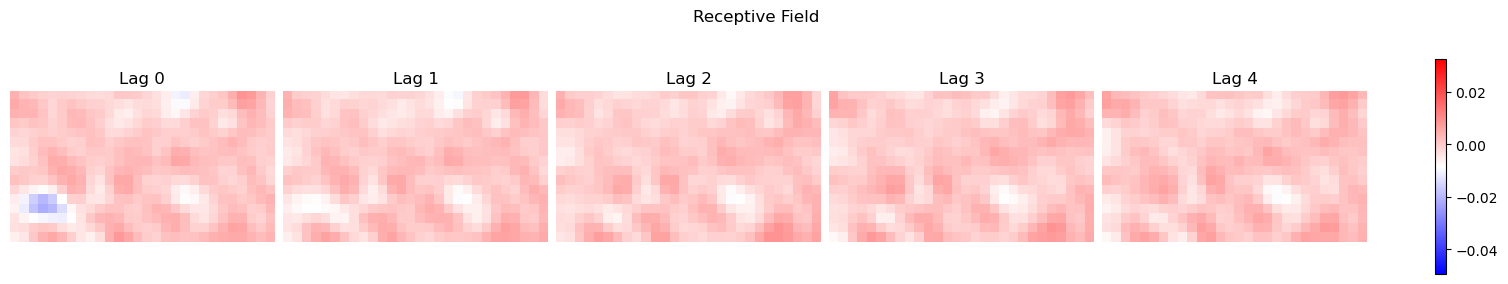

In [57]:
# Plot LNP model

plot_rf(rf)

After implementing the LNP model, the resulting receptive fields for the example neuron appeared weak or lacked clear spatial structure. This could be due to several limitations inherent in the basic LNP formulation. The model relies on fitting a linear filter followed by a fixed nonlinearity, assuming that this transformation sufficiently captures the neuron's encoding process. 

To better understand why the LNP model might be underperforming, we analyzed the spike count statistics across time using a simple spike count diagnostic plot. By visualizing the number of spikes in each stimulus time bin and computing basic statistics (minimum, maximum, mean, and the proportion of zero-spike bins), we assessed whether the neuron exhibited enough activity for the model to learn from. A high proportion of bins with no spikes may indicate insufficient signal in the data, making it harder for the model to detect consistent stimulus-response patterns.

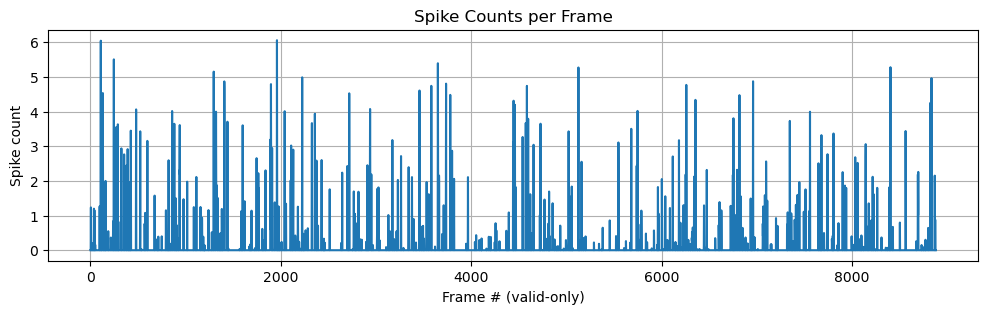

Min spike count: 0.0
Max spike count: 6.058916380714144
Mean spike count: 0.12523355101699665
Fraction zero frames: 0.8942567567567568


In [58]:
# Diagnostics: spike count trace

plt.figure(figsize=(12, 3))
plt.plot(framewise_spike_counts)
plt.title("Spike Counts per Frame")
plt.xlabel("Frame # (valid-only)")
plt.ylabel("Spike count")
plt.grid(True)
plt.show()

print("Min spike count:", np.min(framewise_spike_counts))
print("Max spike count:", np.max(framewise_spike_counts))
print("Mean spike count:", np.mean(framewise_spike_counts))
print("Fraction zero frames:", np.mean(framewise_spike_counts == 0))

Supporting this interpretation, the spike count diagnostics reveal that the neural activity is very sparse: the minimum spike count per time bin is zero, the maximum is approximately 6 spikes, and the mean spike count is low at around 0.125 spikes per bin. Moreover, nearly 89.4% of the time bins contain zero spikes. This extreme sparsity makes it challenging for the model to reliably estimate the receptive field because there are too few events driving the neural responses.

In such cases, standard linear or generalized linear models may struggle to capture meaningful structure, as the data do not contain enough informative spikes to constrain the model parameters.

### Lasso Regularization

To improve estimation we also implemented Lasso (L1) regularization during fitting, encouraging sparsity in the receptive field and reducing overfitting, especially important when dealing with high-dimensional stimuli and limited data. This regularization can help isolate the most informative spatial and temporal features driving neural responses, resulting in cleaner and more interpretable receptive field estimates

We have fitted a LNP with Lasso Regularization for values of alpha equal to 0.001, 0.01 and 0.1.

In [59]:
# Lasso Fitting Function


def fit_receptive_field_lasso(spike_counts, stims, lags, alpha=0.01, max_iter=10000):
    Dx, Dy = stims.shape[1:3]
    n_frames = stims.shape[0]
    n_lags = len(lags)

    stim_reshaped = stims.reshape(n_frames, Dx * Dy).T  # (pixels, time)
    w_hat = np.zeros((Dx * Dy, n_lags))

    for i, lag in enumerate(lags):
        if lag > 0:
            s_lag = stim_reshaped[:, :-lag].T  # (time-lag, pixels)
            c_lag = spike_counts[lag:]  # (time-lag,)
        else:
            s_lag = stim_reshaped.T  # (time, pixels)
            c_lag = spike_counts  # (time,)

        model = Lasso(alpha=alpha, max_iter=max_iter, random_state=42)
        model.fit(s_lag, c_lag)
        w_hat[:, i] = model.coef_

    return w_hat.reshape(Dx, Dy, n_lags)

In [60]:
# Lasso Sweep

alphas = [0.001, 0.01, 0.1]
rf_lasso_dict = {}

for alpha in alphas:
    print(f" Fitting Lasso with alpha={alpha}")
    rf_lasso = fit_receptive_field_lasso(
        framewise_spike_counts, stims_norm, lags, alpha=alpha
    )

    rf_lasso_dict[alpha] = rf_lasso

 Fitting Lasso with alpha=0.001
 Fitting Lasso with alpha=0.01
 Fitting Lasso with alpha=0.1


 Plotting RF for alpha=0.001


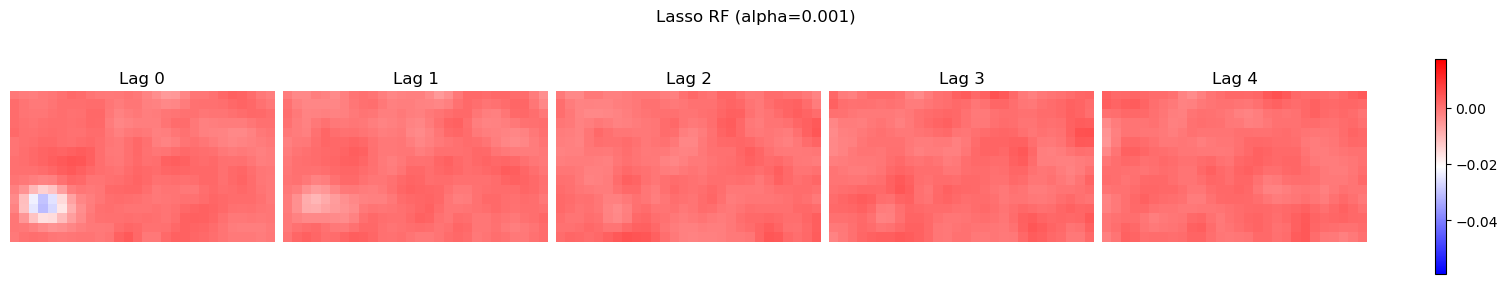

 Plotting RF for alpha=0.01


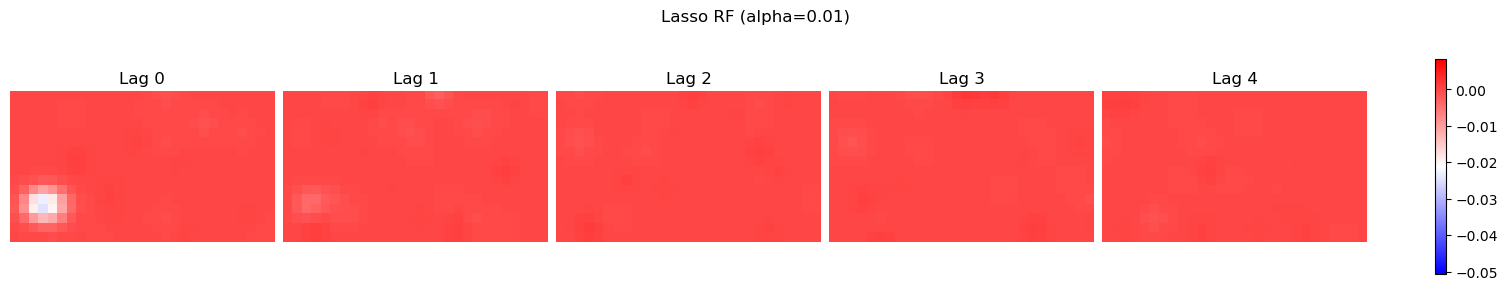

 Plotting RF for alpha=0.1


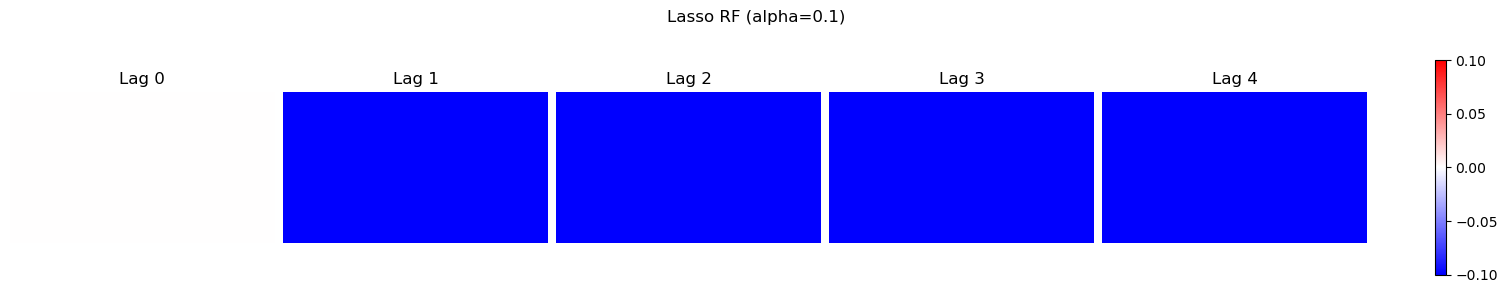

Max coefficient: 0.0


In [61]:
# Visualize Results

for alpha in alphas:
    print(f" Plotting RF for alpha={alpha}")
    plot_rf(rf_lasso_dict[alpha], title=f"Lasso RF (alpha={alpha})")

rf = rf_lasso_dict[0.1]
print("Max coefficient:", np.max(np.abs(rf)))

The Lasso regression results indicate poor receptive field (RF) fitting for the current data and parameter settings. Specifically, when using an alpha value of 0.1, which controls the strength of the L1 regularization penalty, the model’s coefficients reach their maximum absolute values (Max coefficient: 0.0). This suggests that the Lasso penalty is too strong, causing the model to zero out all the coefficients.

## 3. Receptive Field Estimation Methods with RFEst v2


To extend our analysis and compare a diverse set of receptive field (RF) estimation techniques, we utilized the **RFEst v2** Python toolbox. This open-source library provides a comprehensive and modular framework for modeling and fitting receptive fields using several well-established statistical and machine learning methods. The methods implemented in RFEst range from simple matrix-based estimators to probabilistic Bayesian approaches and more flexible, nonlinear models.

### 1. STA and MLE (Matrix-based Estimators)

- **Spike-Triggered Average (STA):**  
  The STA is the simplest RF estimation method and acts as a first-order approximation of the linear filter. It is computed by averaging the stimuli that preceded each spike, assuming the neuron's firing rate is linearly related to the stimulus:  
  `w_sta = X.T @ y`  
  This operation accumulates stimulus patterns that triggered spikes.

- **Maximum Likelihood Estimation (MLE):**  
  MLE extends STA by finding the linear weights `w` that best predict the spike counts via least squares regression:  
  `w_mle = np.linalg.inv(X.T @ X) @ X.T @ y`  
  It assumes a linear response model with Gaussian noise and no regularization.



### 2. Empirical Bayes with Structured Gaussian Priors

- **Automatic Smoothness Determination (ASD):**  
  ASD is a Bayesian linear regression model that imposes a smoothness prior on the receptive field. It learns the strength and spatial scale of this smoothness directly from data, promoting smooth, biologically plausible filters.

- **Automatic Locality Determination (ALD):**  
  ALD generalizes ASD by allowing non-stationary priors, meaning it can adapt spatial smoothness and localization differently across the receptive field, ideal for RFs with strong spatial structure.



### 3. Matrix Factorization Models

- **Linear-Nonlinear-Poisson (LNP):**  
  The LNP model assumes a neuron's firing rate is the result of a linear projection of the stimulus, passed through a fixed nonlinearity (e.g., exponential), then modeled with a Poisson spike generator. This captures both filtering and noise characteristics.

- **LNLN (Two-layer model):**  
  This extends LNP by using multiple linear filters, each followed by a nonlinearity, then summed and passed through another nonlinearity. It models more complex, biologically realistic processing like subunits or nonlinear pooling.



### 4. Spline-based Generalized Linear Models

- **splineLNP:**  
  A flexible version of LNP where the nonlinearity is not fixed but instead learned from the data using spline basis functions.

- **splineLNLN:**  
  The most flexible model, applying splines to both the subunit-level and final-stage nonlinearities. This allows it to capture highly nonlinear computations found in complex neural systems.



In [62]:
# Set up parameters to build stimulus matrix
Dx, Dy = stims.shape[1:]
dims = [Dx, Dy]
df = [int(np.maximum(np.ceil(dim / 2), 3)) for dim in list(dims)] #this is taken from the tutorial notebooks on github

In [63]:
def build_stimulus_matrix(stims, stim_epochs, stim_metadata, trace_length):
    """
    Builds stimulus matrix `s` of shape (Dx * Dy, nT), where each column is the stimulus
    shown at that timepoint, or zeros if no stimulus was shown.

    Parameters:
        stims: np.array of shape (9000, Dx, Dy)
        stim_epochs: pd.DataFrame with 'stimulus', 'start', 'end'
        stim_metadata: pd.DataFrame with 'frame', 'start', 'end'
        trace_length: int, number of timepoints in spike train

    Returns:
        s: np.array of shape (Dx*Dy, nT)
    """

    Dx, Dy = stims.shape[1], stims.shape[2]
    nT = trace_length
    s = np.zeros((nT, Dx, Dy), dtype=stims.dtype)

    # Filter epochs for locally sparse noise
    lsn_epochs = stim_epochs[stim_epochs["stimulus"] == "locally_sparse_noise"]

    # Flatten each stim frame once
    flat_stims = stims.reshape(stims.shape[0], -1)  # shape (9000, Dx*Dy)

    # Loop through all metadata rows and check if the frame belongs to LSN
    for _, row in stim_metadata.iterrows():
        frame = row["frame"]
        t_start = int(row["start"])
        t_end = int(row["end"])

        # Check if this frame falls within any LSN epoch
        in_lsn = any(
            (t_start >= epoch_start) and (t_end <= epoch_end)
            for epoch_start, epoch_end in zip(lsn_epochs["start"], lsn_epochs["end"])
        )
        if in_lsn and frame < len(flat_stims):
            # Fill in the same stimulus vector across the time window
            s[t_start:t_end, :] = stims[frame]
            # [:, np.newaxis]
    s = s.reshape(nT, Dx, Dy)
    return s

In [64]:
# Set up parameters to calculate stim matrix
trace_length = len(oasis_spikes[0, :])
stims_valid = build_stimulus_matrix(stims, stim_epochs, stim_metadata, trace_length)

n_stim = stims_valid.shape[0]
X = build_design_matrix(stims_valid.reshape((n_stim, -1)), 1)

For simplicity and time saving we will analyze neurons 38 and 60, which are high activity neurons. Also neuron 38 exhibits ON/OFF behaviour.

In [65]:
# Neurons to analyze
neuron_indices = [38, 60]  # Add more indices here if needed

# Container to store filters for each neuron and method
filters = {idx: {} for idx in neuron_indices}

### 1. STA and MLE (Matrix-based Estimators)

In [66]:
for idx in neuron_indices:
    print(f"Processing neuron {idx}")
    y = oasis_spikes[idx, :]

    # STA
    w_sta = X.T @ y
    filters[idx]["STA"] = w_sta

    # MLE
    w_mle = np.linalg.inv(X.T @ X) @ X.T @ y
    filters[idx]["MLE"] = w_mle

Processing neuron 38
Processing neuron 60


### 2. Empirical Bayes with Structured Gaussian Priors

We used standard parameter initialization. Although we experimented with tuning the parameters for optimal initialization, the results did not differ significantly, so we retained the default settings.

In [67]:
# init params
sigma0 = [1.0]
rho0 = [1.0]
params_t0 = [3.0, 20.0, 1.0, 1.0]
params_y0 = [3.0, 20.0, 1.0, 1.0]
p0 = sigma0 + rho0 + params_t0 + params_y0

In [68]:
for idx in neuron_indices:
    print(f"Processing neuron {idx}")
    y = oasis_spikes[idx, :]

    # ASD
    asd = ASD(X, y, dims=dims)
    asd.fit(
        p0=[1.0, 1.0, 6.0, 6.0],
        num_iters=30,
        verbose=10,
    )
    w_asd = asd.optimized_C_post @ X.T @ y / asd.optimized_params[0] ** 2
    filters[idx]["ASD"] = w_asd

    # ALD
    ald = ALD(X, y, dims=dims)
    ald.fit(p0=p0, num_iters=30, verbose=10)
    w_ald = ald.optimized_C_post @ X.T @ y / ald.optimized_params[0] ** 2
    filters[idx]["ALD"] = w_ald

Processing neuron 38
Iter	σ	ρ	δt	δs	cost
   0	0.990	1.010	5.990	6.010	96241.993
  10	0.890	1.023	5.989	6.070	84938.680
  20	0.787	1.043	6.030	6.132	72032.026
Stop: reached 30 steps, final cost=58412.74625.
* Due to space limit, parameters for frequency domain are not printed.
Iter	σ	ρ	τ_t	ν_t	τ_y	ν_y	cost
   0	0.990	0.990	3.010	19.990	2.990	20.010	93450.066
  10	0.890	0.933	3.069	19.931	2.928	20.066	82121.434
  20	0.787	0.908	3.062	19.937	2.889	20.100	69071.691
Stop: reached 30 steps, final cost=55346.39832.
Processing neuron 60
Iter	σ	ρ	δt	δs	cost
   0	0.990	1.010	5.990	6.010	96361.458
  10	0.890	1.046	5.996	6.075	85092.767
  20	0.787	1.063	6.031	6.131	72231.960
Stop: reached 30 steps, final cost=58672.38269.
* Due to space limit, parameters for frequency domain are not printed.
Iter	σ	ρ	τ_t	ν_t	τ_y	ν_y	cost
   0	0.990	0.990	3.010	19.990	2.990	20.010	93569.531
  10	0.890	0.920	3.024	19.974	2.968	20.030	82291.139
  20	0.787	0.865	3.036	19.963	2.948	20.050	69353.930
Stop: reached 30 ste

### 3. Matrix Factorization Models

In [69]:
for idx in neuron_indices:
    print(f"Processing neuron {idx}")
    y = oasis_spikes[idx, :]

    # LNP
    lnp = LNP(X, y, dims, dt=dt)
    lnp.fit(verbose=10, fit_nonlinearity=True)
    filters[idx]["LNP"] = lnp.w_opt

    # LNLN
    lnln = LNLN(X, y, dims, dt=dt)
    lnln.fit(verbose=10, fit_nonlinearity=True)
    filters[idx]["LNLN"] = lnln.w_opt

Processing neuron 38
Iters        Time (s)     Cost (train)    Metric (train)  Metric (dev)    
0            5.818        38377.453       
Stop: reached 5 steps.

Returning model: best_train_cost at iteration 4 of 4 (Max: 5).

Iters        Time (s)     Cost (train)    Metric (train)  Metric (dev)    
0            4.339        3302.360        
10           5.074        3046.031        
20           5.621        2836.464        
30           6.167        2673.205        
40           6.703        2554.863        
50           7.256        2475.579        
60           7.878        2427.180        
70           8.638        2400.898        
80           9.408        2388.645        
90           10.359       2383.961        
100          11.436       2382.539        
110          12.451       2382.118        
120          13.344       2381.840        
130          14.271       2381.522        
140          15.215       2381.173        
150          16.175       2380.813        
160       

### 4. Spline-based Generalized Linear Models

In [70]:
for idx in neuron_indices:
    print(f"Processing neuron {idx}")
    y = oasis_spikes[idx, :]

    # LNP
    spl_lnp = splineLNP(X, y, dims=dims, dt=dt, df=df)
    spl_lnp.fit(verbose=10, fit_nonlinearity=True)
    filters[idx]["splineLNP"] = spl_lnp.w_opt

    # LNLN
    spl_lnln = splineLNLN(X, y, dims=dims, dt=dt, df=df)
    spl_lnln.fit(verbose=10, fit_nonlinearity=True)
    filters[idx]["splineLNLN"] = spl_lnln.w_opt

Processing neuron 38
Iters        Time (s)     Cost (train)    Metric (train)  Metric (dev)    
0            1.105        22982.543       
10           1.405        15681.231       
20           1.768        6675.060        
30           2.158        2488.514        
40           2.531        3856.473        
50           2.947        2807.402        
60           3.430        2358.251        
70           3.836        2361.036        
80           4.345        2289.206        
90           4.663        2243.074        
100          5.173        2206.832        
110          5.636        2179.700        
120          6.093        2153.774        
130          6.594        2129.602        
140          6.895        2106.751        
150          7.443        2085.405        
160          7.890        2065.420        
170          8.343        2046.734        
180          8.797        2029.293        
190          9.113        2013.038        
200          9.651        1997.910        
2

In [71]:
# Save the filters dictionary to a file
with open("filters_final.pkl", "wb") as f:
    pickle.dump(filters, f)

print("Filters saved successfully.")

Filters saved successfully.


In [72]:
# Load the filters dictionary from the file
with open("filters_final.pkl", "rb") as f:
    filters = pickle.load(f)

print("Filters loaded successfully.\n")

# Print the neuron IDs and method keys
for neuron_id, methods in filters.items():
    print(f"Neuron {neuron_id}: {list(methods.keys())}")

Filters loaded successfully.

Neuron 38: ['STA', 'MLE', 'ASD', 'ALD', 'LNP', 'LNLN', 'splineLNP', 'splineLNLN']
Neuron 60: ['STA', 'MLE', 'ASD', 'ALD', 'LNP', 'LNLN', 'splineLNP', 'splineLNLN']


## Visualization

Plotting smoothed filters for neuron 38


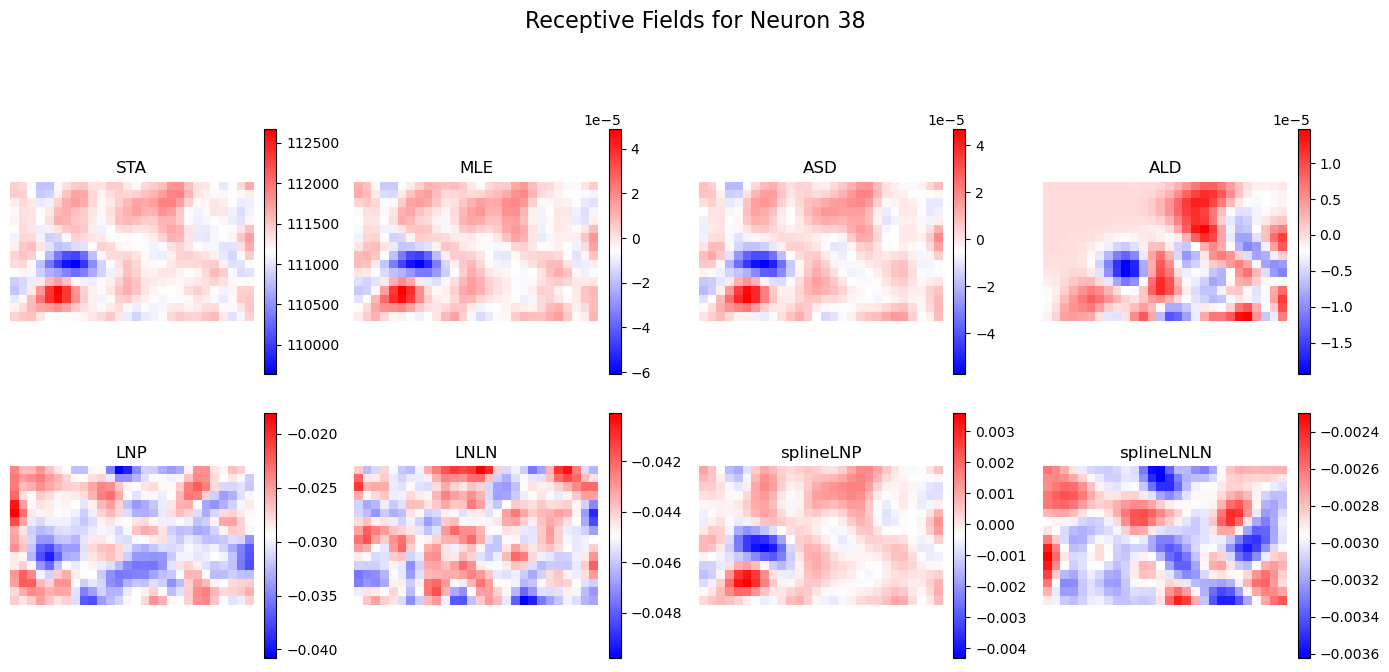

Plotting smoothed filters for neuron 60


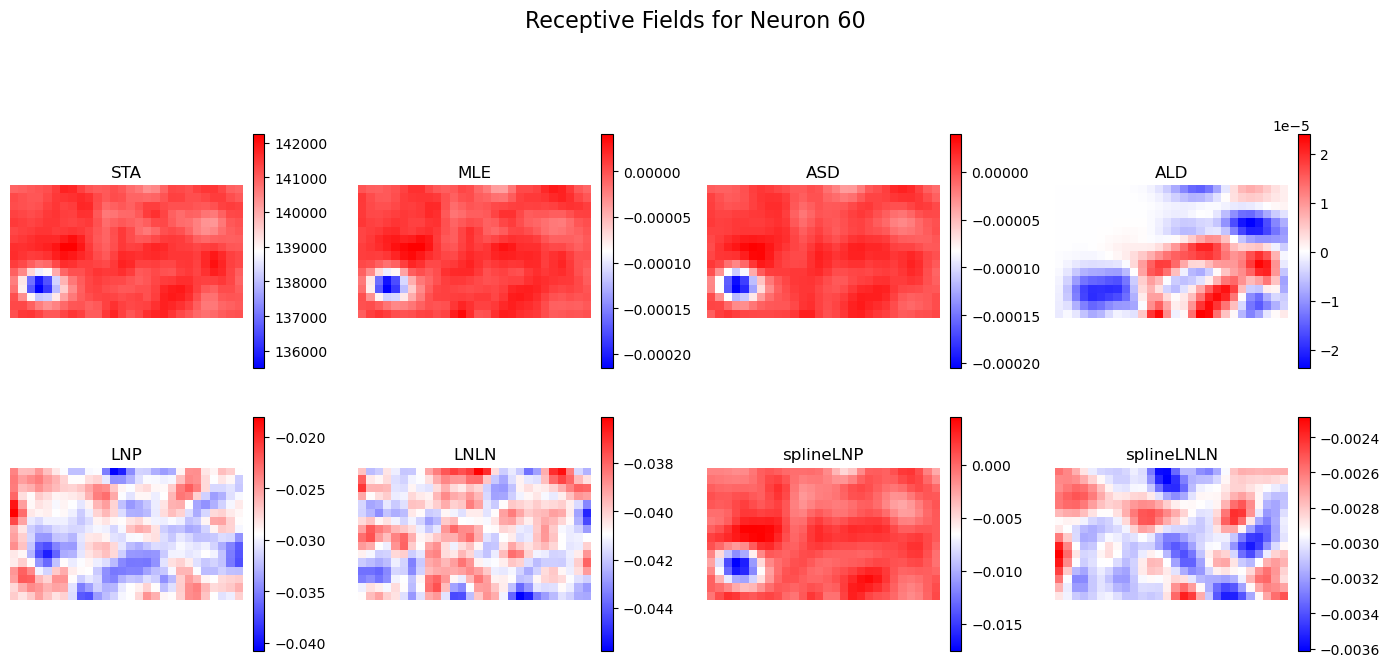

In [73]:
# Full list of methods to visualize
all_methods = ["STA", "MLE", "ASD", "ALD", "LNP", "LNLN", "splineLNP", "splineLNLN"]

for idx in neuron_indices:
    print(f"Plotting smoothed filters for neuron {idx}")
    available_methods = [m for m in all_methods if m in filters[idx]]
    n_methods = len(available_methods)

    # Define layout: 2 rows, calculate columns accordingly
    n_rows = 2
    n_cols = math.ceil(n_methods / n_rows)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 7))
    axs = axs.flatten()

    for i, method in enumerate(available_methods):
        w = filters[idx][method]

        # LNLN has 2 overlapped filters, take the average to match dimensions
        if w.ndim == 2:
            w = np.mean(w, axis=1).reshape(Dx, Dy)
        else:
            w = w.reshape(Dx, Dy)

        w_smooth = gaussian_filter(w, sigma=1)

        im = axs[i].imshow(w_smooth, cmap="bwr")
        axs[i].set_title(method, fontsize=12)
        axs[i].axis("off")
        fig.colorbar(im, ax=axs[i], fraction=0.046, pad=0.04)

    # Hide unused subplots, if any
    for j in range(i + 1, len(axs)):
        axs[j].axis("off")

    fig.suptitle(f"Receptive Fields for Neuron {idx}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

The plots reveal strong consistency across receptive field estimates obtained using STA, MLE, ASD, and splineLNP, each capturing similar spatial structure and localization. This coherence is expected because all four methods rely on linear filtering and are well-suited for neurons with approximately linear responses. STA and MLE, while simpler and unregularized, perform well when the data is relatively clean, whereas ASD and splineLNP further improve interpretability by incorporating smoothness priors or flexible nonlinearities, reducing noise in the estimates. 

In contrast, ALD results appear more blurred—likely due to its highly flexible, non-stationary priors that can over-adapt to data with limited spike counts or weaker signal, leading to more diffuse receptive field representations. 

On the other hand, the LNP, LNLN, and splineLNLN models do not produce clearly defined receptive fields in the current plots. This may be attributed to their greater complexity and reliance on nonlinear transformations, which require more data and careful tuning to converge to interpretable filters. These methods are powerful but can struggle in practice when spike data is sparse or when the underlying RF structure is weak or subtle.


## Method comparison analysis

To quantitatively compare the performance of each RF estimation method, we use the Spike-Triggered Average (STA) as a reference baseline. While STA is a simple and commonly used technique, it often provides a reasonable first-order approximation of the neuron's receptive field, making it a useful benchmark. For each method the similarity to the STA using a permutation test based on Pearson correlation is computed. Specifically, the function `permutation_test_vs_sta` calculates the observed correlation between the estimated RF and the STA, then generates a null distribution by randomly permuting the method's RF weights and recalculating the correlation multiple times. This provides a non-parametric p-value indicating whether the observed similarity could have occurred by chance. This approach allows us to assess how well each method recovers structure consistent with STA, while accounting for randomness and potential overfitting.


In [74]:
w_sta = filters[neuron_id]["STA"].flatten()

w_dict = {
    "MLE": filters[neuron_id]["MLE"].flatten(),
    "ASD": filters[neuron_id]["ASD"].flatten(),
    "ALD": filters[neuron_id]["ALD"].flatten(),
    "LNP": filters[neuron_id]["LNP"].flatten(),
    "LNLN": np.mean(filters[neuron_id]["LNLN"], axis=1).flatten(),
    "splineLNP": filters[neuron_id]["splineLNP"].flatten(),
    "splineLNLN": np.mean(filters[neuron_id]["splineLNLN"], axis=1).flatten(),
}

In [75]:
def permutation_test_vs_sta(w_method, w_sta, n_perm=1000):
    """Compare RF to STA using Pearson correlation and permutation test."""
    corr_obs = np.corrcoef(w_method, w_sta)[0, 1]

    # Build null distribution by permuting the method RF
    perm_corrs = []
    for _ in range(n_perm):
        perm = np.random.permutation(w_method)
        r = np.corrcoef(perm, w_sta)[0, 1]
        perm_corrs.append(r)

    p_val = np.mean(np.abs(perm_corrs) >= np.abs(corr_obs))
    return corr_obs, p_val

In [76]:
results = {}

for method_name, w in w_dict.items():
    corr, p = permutation_test_vs_sta(w, w_sta)
    results[method_name] = {"corr_with_STA": corr, "p_value": p}

In [77]:
print(f"{'Method':<12} | {'Corr w/ STA':>10} | {'p-value':>8} | Sig")
print("-" * 40)
for name, stats in results.items():
    corr = stats["corr_with_STA"]
    p = stats["p_value"]
    sig = "*" if p < 0.05 else "ns"
    print(f"{name:<12} | {corr:10.3f} | {p:8.4f} | {sig}")

Method       | Corr w/ STA |  p-value | Sig
----------------------------------------
MLE          |      0.961 |   0.0000 | *
ASD          |      0.801 |   0.0000 | *
ALD          |      0.433 |   0.0000 | *
LNP          |      0.054 |   0.2620 | ns
LNLN         |      0.029 |   0.5420 | ns
splineLNP    |      0.670 |   0.0000 | *
splineLNLN   |      0.007 |   0.8560 | ns


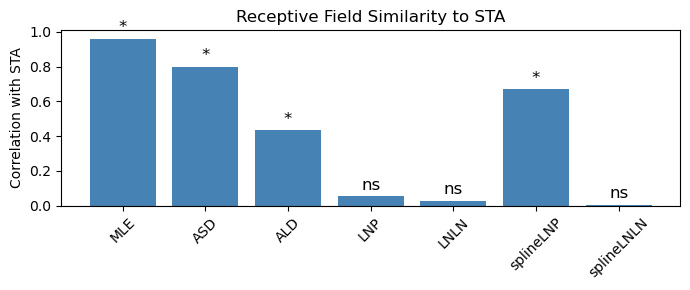

In [78]:
# Extract method names and metrics
method_names = list(results.keys())
correlations = [results[m]["corr_with_STA"] for m in method_names]
p_values = [results[m]["p_value"] for m in method_names]
significance = ["*" if p < 0.05 else "ns" for p in p_values]

# Plot for better visualization
plt.figure(figsize=(7, 3))
bars = plt.bar(method_names, correlations, color="steelblue")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.ylabel("Correlation with STA")
plt.title("Receptive Field Similarity to STA")

# Annotate significance
for i, (bar, sig) in enumerate(zip(bars, significance)):
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y + 0.02,
        sig,
        ha="center",
        va="bottom",
        fontsize=12,
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The permutation test results provide a quantitative comparison of how closely each receptive field estimation method aligns with the STA baseline. Classical linear estimators like MLE and ASD showed the strongest and most statistically significant correlations with STA, confirming their effectiveness in recovering linear receptive fields under Gaussian-like assumptions. ALD, while still significant, exhibited lower similarity, likely due to its adaptive non-stationary priors introducing more localized structure. In contrast, more flexible nonlinear models such as LNP, LNLN, and splineLNLN failed to produce receptive fields significantly correlated with STA, reflecting their capacity to capture richer but potentially less STA-aligned structure. Interestingly, splineLNP, a spline-based extension of LNP, maintained significant correlation while allowing nonlinear response modeling, striking a balance between expressiveness and alignment with STA. Overall, the results suggest that while more complex models can capture nonlinearities, they may diverge from traditional STA-derived interpretations unless carefully constrained.


# Alternative Receptor Fields Estimation - On/Off Analysis

Here, we adapted the Allen Institute’s ΔF/F event detection approach to identify stimulus-responsive trials and construct spatial ON and OFF response-triggered stimulus maps for receptive field estimation. 

We adapted the Allen Institute’s ΔF/F-based event detection method to identify stimulus-responsive trials. For each trial, we extracted two features from the smoothed calcium trace: an early slope (xx) and a delayed peak amplitude (yy). Trials with weak upward transients (yy < 0.05 and xx < yy) were used to define a noise distribution, from which we estimated the median and robust spread. We then classified a trial as responsive if its (xx, yy) point exceeded a 4σ Mahalanobis-like distance from the noise cluster. Additional filters ensured the response was upward-going (yy > 0.05, xx < yy) and sustained above baseline. Using these detected events, we constructed response-triggered stimulus (RTS) fields by summing stimulus frames presented during responsive trials. For each trial, we binarized the stimulus into ON (white; pixel >127) and OFF (black; pixel <127) masks, allowing us to compute separate ON and OFF RTS maps. These maps reflect the spatial pattern of pixels most likely to drive the neuron during white or black flashes, forming the basis of the receptive field estimation.

### Event Detection

The first step is to categorize each stimulus trial as either “responsive” or “unresponsive” for a given neuron. This provides the foundation for all subsequent RF analysis. 

The code analyzes the neuron’s ΔF/F trace, and for each trial, it computes an early change (xx) and a later peak change (yy) relative to the pre-stimulus baseline. We estimate the center and spread of the “noise” cluster (using median and robust standard deviation of xx and yy across trials). Any trial whose (xx, yy) point lies more than 4σ from this center, with a positive-going transient (yy > 0.05 and initial slope xx < yy), is marked responsive. This follows the Allen Institute’s two-feature event detection method.

We do this for each neuron in a loop, producing a boolean “event vector” of length 8880 (trials) per neuron. That vector indicates which trials were responsive. 

In [27]:
# Extract relevant data from the dataset
t = data['t']                    # (105968,) time vector
dff = data['dff']                # (189, 105968) ΔF/F traces for each neuron
stim_table = pd.DataFrame(data['stim_table'], columns=['frame', 'start', 'end'])  # stimulus timing info
stim = data['stim']             # (9000, 16, 28) stimulus frames
roi_masks = data['roi_masks']   # (189, 512, 512) binary masks for each ROI
max_projection = data['max_projection']  # (512, 512) image used for ROI display
running_speed = data['running_speed']    # (2, 105968) running speed trace
stim_epoch_table = pd.DataFrame(data['stim_epoch_table'])  # (7, 3) stimulus epochs

# Select a cell of interest by index (ideally one with a clear receptive field)
cell_index = 60  # example: cell with strong event responses

# Initialize binary event vector for this cell (True if trial is responsive)
event_vector = np.zeros(len(stim_table), dtype=bool)

# Smooth the ΔF/F trace to reduce frame-to-frame noise
trace = dff[cell_index]
window = 5
kernel = np.ones(window) / window
smooth_trace = np.convolve(trace, kernel, mode='same')

# Extract event features from each trial: slope and peak amplitude
k_min, k_max, delta = 0, 10, 3  # time window parameters
xx_list, yy_list = [], []
var_dict = {}

for i, row in enumerate(stim_table.itertuples(index=False)):
    start_idx = row.start
    end_idx = row.end
    offset = 1 if i > 0 and stim_table.iloc[i].start == stim_table.iloc[i-1].end else 0
    beg = int(start_idx + 1 + offset)
    endw = int(start_idx + k_max + 1 + offset)
    if endw > len(smooth_trace): continue
    segment = smooth_trace[beg:endw]
    if len(segment) < k_max: continue

    segment = segment - segment[0]
    xx = segment[delta] - segment[0]
    yy = max(segment[delta+2] - segment[2],
             segment[delta+3] - segment[3],
             segment[delta+4] - segment[4])
    t0_val = segment[0]
    tf_val = segment[-1]
    xx_list.append(xx); yy_list.append(yy)
    var_dict[i] = (t0_val, tf_val, xx, yy)

# Estimate noise distribution from small-transient trials
xx_arr = np.array(xx_list); yy_arr = np.array(yy_list)
mu_x = np.median(xx_arr) if len(xx_arr) > 0 else 0.0
mu_y = np.median(yy_arr) if len(yy_arr) > 0 else 0.0
xx_cent = xx_arr - mu_x
yy_cent = yy_arr - mu_y
std_x = np.percentile(np.abs(xx_cent), 68.27) if len(xx_arr) > 0 else 1e-6
std_y = np.percentile(np.abs(yy_cent), 68.27) if len(yy_arr) > 0 else 1e-6
std_x = max(std_x, 1e-6)
std_y = max(std_y, 1e-6)

# Identify "noise cluster" in 2D feature space
dist = np.sqrt((xx_cent / std_x)**2 + (yy_cent / std_y)**2)
noise_mask = dist < 4

# Estimate noise covariance and its inverse
Cov = np.cov(xx_cent[noise_mask], yy_cent[noise_mask]) if np.any(noise_mask) else np.eye(2)
try:
    cov_inv = np.linalg.inv(np.linalg.cholesky(Cov))
except np.linalg.LinAlgError:
    cov_inv = np.eye(2)

# Use distance from noise center + amplitude/slope filters to classify events
noise_threshold = max(4*std_x + mu_x, 4*std_y + mu_y)
for i, (t0_val, tf_val, xx, yy) in var_dict.items():
    xi_z, yi_z = cov_inv.dot(np.array([xx - mu_x, yy - mu_y]))
    if np.sqrt(xi_z**2 + yi_z**2) > 4 and yy > 0.05 and xx < yy and tf_val > noise_threshold / 2:
        event_vector[i] = True

print(f"Cell {cell_index} events detected: {event_vector.sum()} out of {len(event_vector)} trials")


Cell 60 events detected: 154 out of 8880 trials


### Matrices Preparation

We extract the stimulus frames for each trial and create ON/OFF masks. Using stim_table, we select the sequence of stimulus images actually shown (stim_sequence). We then define two boolean masks for each trial: on_mask is True where the stimulus pixel is white (>127) and off_mask is True where it is black (<127). We flatten the spatial dimensions so that each trial’s ON/OFF image becomes a 448-pixel vector (flat_on, flat_off). Finally, we compute the response-triggered stimulus (RTS) fields: we multiply the binary event vector by each design matrix to count how often each pixel was ON (or OFF) when a response occurred. These counts are reshaped back into 16×28 maps rts_on and rts_off. In other words, rts_on[i,j] is the number of responsive trials where pixel (i,j) was white.

In [36]:
# Build stimulus sequence and design matrices for analysis
stim_frames = stim_table['frame'].values.astype(int)        # indices of stimulus frames presented
stim_sequence = stim[stim_frames]                           # stimulus images for each trial (shape: trials x 16 x 28)
on_mask = (stim_sequence > 127)   # True where pixel was white (ON stimulus) on each trial
off_mask = (stim_sequence < 127)  # True where pixel was black (OFF stimulus) on each trial

num_trials = len(stim_table)
num_pixels = on_mask.shape[1] * on_mask.shape[2]  # e.g., 16*28 = 448 pixel positions
# Flatten spatial dimensions for matrix operations (trials x pixels)
flat_on = on_mask.reshape(num_trials, num_pixels).astype(float)
flat_off = off_mask.reshape(num_trials, num_pixels).astype(float)

# Compute response-triggered stimulus (RTS) field: count of events when each pixel was stimulated
event_vector_float = event_vector.astype(float)  # convert boolean events to 0/1
# Sum of events for each pixel when ON or OFF (dot product between trials and event occurrences)
rts_on_flat = event_vector_float @ flat_on   # array of length num_pixels
rts_off_flat = event_vector_float @ flat_off
# Reshape back to spatial map (same shape as stimulus frames, e.g., 16x28)
rts_on = rts_on_flat.reshape(stim_sequence.shape[1], stim_sequence.shape[2])
rts_off = rts_off_flat.reshape(stim_sequence.shape[1], stim_sequence.shape[2])
print("RTS on-field shape:", rts_on.shape, " RTS off-field shape:", rts_off.shape)

RTS on-field shape: (16, 28)  RTS off-field shape: (16, 28)


### Pixel Wise Significance Mapping

Once a neuron is deemed to have an RF, the next goal is to map which pixels (locations) belong to its ON and OFF subunits. Allen’s pipeline accomplished this by measuring, for each stimulus pixel, whether that pixel’s presence coincided with neuron responses more often than expected by chance. This is essentially a per-pixel significance test, performed separately for ON (bright) and OFF (dark) spots. The result is a p-value map over visual space, which is then thresholded to identify significant pixels of the RF.

Stimulus-Response Mapping: For each neuron, we aim to identify pixels in the stimulus that significantly correlate with responses. Intuitively, we compute a kind of spike-triggered average (STA) separately for ON (white) and OFF (black) stimuli. Formally, we take the weighted average of stimulus frames by the neuron’s event vector (or equivalently sum the ON/OFF masks over responsive trials) to get an ON-field and OFF-field map. High positive values in the ON-field indicate the neuron tends to fire when those pixels are white; similarly, the OFF-field highlights pixels where black stimuli elicit firing.

Permutation Test and FDR: To assess statistical significance, we compare the actual response frequency at each pixel to a null distribution. Specifically, we treat each pixel’s response probability (events over trials) and perform a Monte Carlo shuffle: we randomly permute the event vector many times, recompute the pixel response fractions, and derive a null distribution of values. The p-value for each pixel is the fraction of shuffles where the null response was as extreme as the real one. We correct for multiple comparisons across all pixels using the Benjamini–Hochberg FDR procedure. The resulting binary masks (fdr_mask_on, fdr_mask_off) indicate which pixels are significant at the chosen alpha.

Receptive Field Subunits: Contiguous regions of significant pixels define the neuron’s receptive subunits. We identify connected components (8-connectivity) in the ON and OFF masks separately. For each contiguous subunit, the code fits a 2D Gaussian to the blurred response field (using the fit_gaussian function) to estimate its center and size. The Gaussian fits are then summed to form final RF maps (gaussian_fit_on, gaussian_fit_off).

In [29]:
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter
from skimage.measure import block_reduce

def blur_field(img, sigma=4):
    """Blur an image via upsampling, Gaussian filtering, and downsampling, preserving total intensity."""
    if img.sum() == 0:
        return img
    H, W = img.shape
    padded = np.zeros((3 * H, 3 * W))
    padded[H:2*H, W:2*W] = img

    # Upsampling factor (same as Allen SDK)
    upsample = 4 if H == 16 else 8
    offset = -(1 - (0.625 if upsample == 4 else 0.5625))

    # Define interpolator
    y = np.arange(padded.shape[0])
    x = np.arange(padded.shape[1])
    interp_func = RegularGridInterpolator((y, x), padded, method='linear', bounds_error=False, fill_value=0)

    # Create upsampled grid
    yy = offset + np.arange(0, padded.shape[0], 1.0 / upsample)
    xx = offset + np.arange(0, padded.shape[1], 1.0 / upsample)
    grid_y, grid_x = np.meshgrid(yy, xx, indexing='ij')
    points = np.stack([grid_y.ravel(), grid_x.ravel()], axis=-1)
    upsampled = interp_func(points).reshape(grid_y.shape)

    # Apply Gaussian blur
    filtered = gaussian_filter(upsampled, sigma=sigma, mode='constant')

    # Downsample by summing blocks
    reduced = block_reduce(filtered, (upsample, upsample), func=np.sum)

    # Normalize energy
    reduced *= img.sum() / (reduced.sum() + 1e-10)

    # Crop back to original size
    result = reduced[H:2*H, W:2*W]
    return result

# Compute blurred RTS fields for ON and OFF subfields
rts_on_blur = blur_field(rts_on, sigma=4)
rts_off_blur = blur_field(rts_off, sigma=4)

# Monte Carlo shuffle to compute per-pixel p-values (probability of response by chance)
num_shuffles = 10000
number_of_events = int(event_vector.sum())
# Concatenate ON and OFF design matrices (shape: 2*num_pixels x num_trials)
A = np.vstack([flat_on.T, flat_off.T])  # first num_pixels rows for ON, next num_pixels for OFF
actual_fraction = (A @ event_vector_float) / (number_of_events if number_of_events > 0 else 1)
p_values = np.ones(A.shape[0])  # initialize count of extreme shuffles (start at 1 for continuity)
if number_of_events > 0:
    rng = np.arange(num_trials)
    for i in range(num_shuffles):
        # Randomly select a subset of trials as "events" under the null hypothesis
        size = int(number_of_events + np.round(0.1 * number_of_events * np.random.randn()))
        size = max(0, min(num_trials, size))
        event_indices = np.random.choice(rng, size=size, replace=False)
        b = np.zeros(num_trials, dtype=float); b[event_indices] = 1.0
        frac = (A @ b) / (size if size > 0 else 1)
        # Count if shuffle fraction is less than actual fraction (for one-tailed p-value)
        p_values += (frac < actual_fraction)
# Compute p-value as 1 - CDF (proportion of shuffles with fraction less than actual)
p_values = 1 - p_values / float(num_shuffles)

# Separate ON and OFF p-value maps
pvalues_on = p_values[:num_pixels].reshape(stim_sequence.shape[1], stim_sequence.shape[2])
pvalues_off = p_values[num_pixels:].reshape(stim_sequence.shape[1], stim_sequence.shape[2])

# Apply False Discovery Rate (FDR) correction (Benjamini-Hochberg) to p-values
from statsmodels.stats.multitest import multipletests
alpha = 0.5  # using alpha=0.5 as in Allen SDK example for a lenient threshold
mask, pvals_corrected, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')
fdr_mask_on = mask[:num_pixels].reshape(stim_sequence.shape[1], stim_sequence.shape[2])
fdr_mask_off = mask[num_pixels:].reshape(stim_sequence.shape[1], stim_sequence.shape[2])
print(f"FDR corrected (alpha={alpha}). Significant ON pixels: {fdr_mask_on.sum()}, OFF pixels: {fdr_mask_off.sum()}")

# Identify connected regions (contiguous significant pixels = receptive field subunits)
from scipy.ndimage import label
structure = np.ones((3, 3), dtype=int)  # 8-connected neighborhood
labeled_on, num_on = label(fdr_mask_on, structure=structure)
labeled_off, num_off = label(fdr_mask_off, structure=structure)
components_on = [(labeled_on == k) for k in range(1, num_on+1)]  # list of boolean masks for each ON subunit
components_off = [(labeled_off == k) for k in range(1, num_off+1)]  # list of masks for each OFF subunit

# Fit a 2D Gaussian to each subunit to characterize receptive field centers and spreads
def fit_gaussian(field, mask):
    """Fit a Gaussian to the field values within the given mask (returns a Gaussian image)."""
    if mask.sum() == 0:
        return np.zeros_like(field)
    Y, X = np.indices(field.shape)
    weights = field * mask  # weight by the field values in the subregion
    total = weights.sum()
    # Centroid (mean position)
    cy = (Y * weights).sum() / total
    cx = (X * weights).sum() / total
    # Variance (spread) in each dimension
    var_y = (weights * (Y - cy)**2).sum() / total
    var_x = (weights * (X - cx)**2).sum() / total
    sigma_y = np.sqrt(var_y); sigma_x = np.sqrt(var_x)
    # Amplitude = max response in the subregion
    amp = weights.max()
    # Generate Gaussian fit image
    gauss = amp * np.exp(-(((X - cx)**2) / (2*sigma_x**2 + 1e-9) + 
                            ((Y - cy)**2) / (2*sigma_y**2 + 1e-9)))
    return gauss

# Compute Gaussian fits for each ON and OFF subunit, then sum if multiple
gaussian_fits_on = [fit_gaussian(rts_on_blur, mask) for mask in components_on]
gaussian_fits_off = [fit_gaussian(rts_off_blur, mask) for mask in components_off]
gaussian_fit_on = np.sum(gaussian_fits_on, axis=0) if gaussian_fits_on else np.zeros_like(rts_on)
gaussian_fit_off = np.sum(gaussian_fits_off, axis=0) if gaussian_fits_off else np.zeros_like(rts_off)

FDR corrected (alpha=0.5). Significant ON pixels: 5, OFF pixels: 11


### Combined ON/OFF pixel significance

This heatmap shows the combined significance of each pixel (higher values = more significant). Each pixel’s value is –log10(p), where p is the smaller of the ON and OFF p-values from the permutation test. Brighter (hot) colors indicate pixels that coincide with the neuron’s responses much more often than expected by chance. The title reports the minimum p found. This map helps identify where in visual space the neuron is most responsive (regardless of ON or OFF).

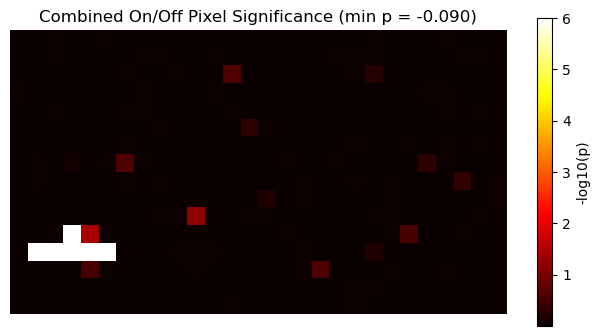

In [30]:
import matplotlib.pyplot as plt

# Combine ON/OFF corrected p-values: use the more significant (min) at each pixel location
pvals_on_map = pvals_corrected[:num_pixels].reshape(rts_on.shape)
pvals_off_map = pvals_corrected[num_pixels:].reshape(rts_off.shape)
combined_min_p = np.minimum(pvals_on_map, pvals_off_map)
# Compute -log10 p for visualization (cap minimum to avoid infinity)
chi_map = -np.log10(np.clip(combined_min_p, 1e-6, 1.0))
min_p = combined_min_p.min()

plt.figure(figsize=(8, 4))
plt.imshow(chi_map, cmap='hot')
plt.colorbar(label='-log10(p)')
plt.title(f"Combined On/Off Pixel Significance (min p = {min_p:.3f})")
plt.axis('off')
plt.show()

### Response-Triggered Stimulus (RTS) ON/OFF fields

Two panels (“RTS ON-field” and “RTS OFF-field”) plot the raw counts of responsive trials when each pixel was white or black, respectively. Each pixel’s value is the dot product of the event vector with the flattened ON/OFF masks. Brighter (hot) pixels mean the neuron tended to spike frequently when that location was stimulated (either ON or OFF). This effectively shows the raw receptive field before smoothing or statistical tests.

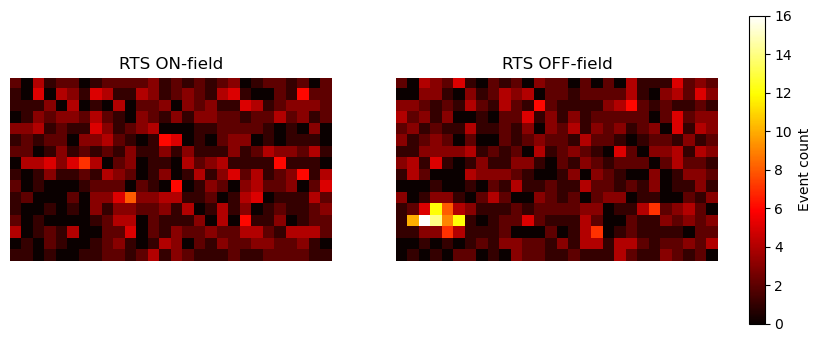

In [31]:
# Plot the RTS fields for ON and OFF subfields side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
# Use a "hot" colormap where higher values are brighter
vmax = max(rts_on.max(), rts_off.max())  # for consistent color scaling
im1 = ax1.imshow(rts_on, cmap='hot', vmin=0, vmax=vmax)
ax1.set_title('RTS ON-field')
ax1.axis('off')
im2 = ax2.imshow(rts_off, cmap='hot', vmin=0, vmax=vmax)
ax2.set_title('RTS OFF-field')
ax2.axis('off')
fig.colorbar(im1, ax=[ax1, ax2], fraction=0.046, pad=0.04, label='Event count')
plt.show()

### Blurred ON/OFF RTS fields

These two panels are the same ON/OFF fields as above but after applying a Gaussian blur (upsample, filter, downsample). The smoothing makes contiguous subunits more visually apparent and prepares the data for Gaussian fitting. In these plots, each receptive sub-region appears as a bright blob corresponding to a putative RF subunit (ON or OFF).

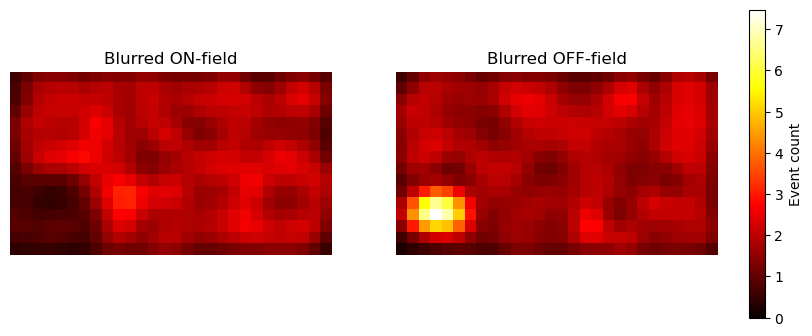

In [32]:
# Plot the blurred RTS fields for ON and OFF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
vmax_blur = max(rts_on_blur.max(), rts_off_blur.max())
im1 = ax1.imshow(rts_on_blur, cmap='hot', vmin=0, vmax=vmax_blur)
ax1.set_title('Blurred ON-field')
ax1.axis('off')
im2 = ax2.imshow(rts_off_blur, cmap='hot', vmin=0, vmax=vmax_blur)
ax2.set_title('Blurred OFF-field')
ax2.axis('off')
fig.colorbar(im1, ax=[ax1, ax2], fraction=0.046, pad=0.04, label='Event count')
plt.show()

### Raw ON/OFF p-value maps 

Two grayscale images display the raw p-values for each pixel under the ON and OFF stimulus conditions, respectively. Darker pixels correspond to lower p-values (i.e., stronger statistical evidence that the pixel was associated with responses beyond chance), while white indicates non-significant pixels. These maps visualize statistical confidence before multiple comparison correction. While they may loosely resemble the RTS maps, they more accurately reflect pixel-wise response reliability rather than raw event frequency.

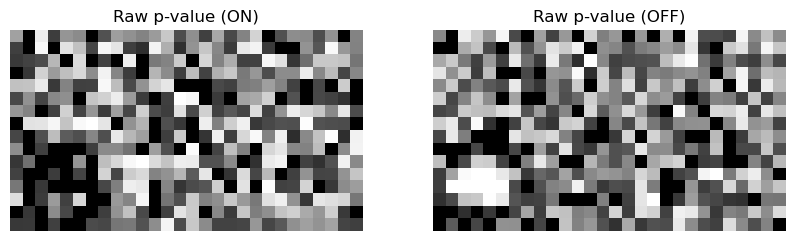

In [33]:
# Plot raw p-value maps for ON and OFF subfields (darker = more significant)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
# Use a reversed grayscale colormap: low p (high significance) = black, high p = white
ax1.imshow(pvalues_on, cmap='gray_r', vmin=0, vmax=1)
ax1.set_title('Raw p-value (ON)')
ax1.axis('off')
ax2.imshow(pvalues_off, cmap='gray_r', vmin=0, vmax=1)
ax2.set_title('Raw p-value (OFF)')
ax2.axis('off')
plt.show()

### Significant ON/OFF pixels

Two grayscale images of the same size, where significant pixels have been masked onto the p-value maps. Specifically, pixels not meeting the FDR threshold are set to white. In this reversed grayscale (gray_r), significant ON (resp. OFF) pixels appear as black regions labeled “Significant ON pixels” / “Significant OFF pixels.” These images highlight exactly which pixels were found to be statistically significant receptive field locations (for ON or OFF subunits).

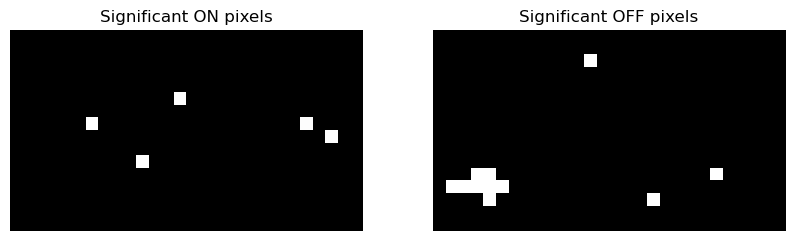

In [34]:
# Plot binary mask of significant pixels for ON and OFF (mask colored by p-value within region)
mask_on_vals = pvalues_on.copy()
mask_on_vals[~fdr_mask_on] = 1.0  # set non-significant to 1 (white in gray_r)
mask_off_vals = pvalues_off.copy()
mask_off_vals[~fdr_mask_off] = 1.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(mask_on_vals, cmap='gray_r', vmin=0, vmax=1)
ax1.set_title('Significant ON pixels')
ax1.axis('off')
ax2.imshow(mask_off_vals, cmap='gray_r', vmin=0, vmax=1)
ax2.set_title('Significant OFF pixels')
ax2.axis('off')
plt.show()

### Gaussian fit maps for ON/OFF Subunits

Finally, two images show the Gaussian models fitted to each subunit. Each is displayed in normal grayscale (white = high value). The ON-panel shows the summed Gaussian fit over all ON subunits; the OFF-panel shows the OFF subunits. These appear as smooth elliptical spots centered on the RF subunits. They provide a compact description of each RF region’s center and spread after smoothing the binary significant masks.

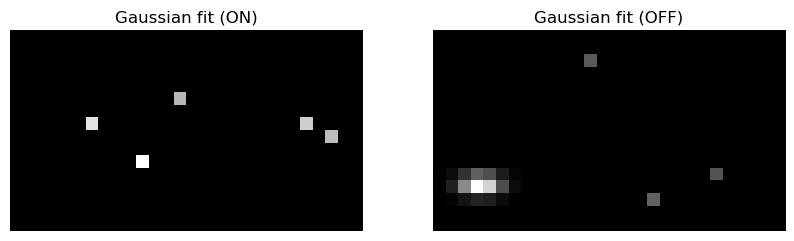

In [35]:
# Plot the Gaussian fit for ON and OFF subunits
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
# Use grayscale: high values = white (for a bright ellipse on dark background)
ax1.imshow(gaussian_fit_on, cmap='gray')
ax1.set_title('Gaussian fit (ON)')
ax1.axis('off')
ax2.imshow(gaussian_fit_off, cmap='gray')
ax2.set_title('Gaussian fit (OFF)')
ax2.axis('off')
plt.show()

### Summary Interpretation: Receptive Field Structure of Neuron 60 (Example Cell)

Neuron 60 exhibits a clear and spatially localized OFF-dominant receptive field, with no strong evidence of an ON subregion. This conclusion is supported across multiple stages of the analysis pipeline.
In the RTS OFF-field, a bright hotspot appears in the lower-left region of the stimulus grid, indicating that this neuron consistently responded to the presence of black pixels at that spatial location across many trials. In contrast, the RTS ON-field is diffuse and lacks any focal structure, suggesting an absence of spatially specific responses to white (ON) stimuli.

The raw p-value map for the OFF condition reinforces this interpretation: a contiguous cluster of low p-values is evident in the same region identified in the RTS OFF-field, indicating that the correlation between black pixel presentation and evoked responses is unlikely to have arisen by chance. This pattern survives statistical thresholding, as shown by the FDR-corrected OFF mask, where a tight group of significant pixels remains. The ON condition, by comparison, contains only a few scattered significant pixels that do not form a coherent spatial cluster and are likely attributable to noise.

To quantify the spatial structure, we fit 2D Gaussian models to the significant regions in the ON and OFF maps. The resulting OFF Gaussian is compact and localized, accurately capturing the peak in the RTS and p-value maps. The ON Gaussian fit, by contrast, is weak and widely dispersed, consistent with the absence of meaningful ON structure.

Overall, these results suggest that Neuron 60 is selectively responsive to dark visual stimuli (OFF), with its receptive field confined to a small, spatially coherent region of the visual field. This OFF subunit is reliable, statistically robust, and well-captured by the Gaussian model, indicating a classic, spatially tuned receptive field — likely from a cell type specialized for detecting luminance decrements in a specific part of the visual space.

# Spatial Structure Investigation in STA Receptive Fields

In this last section we systematically estimate and analyze STA receptive fields to ultimately identify functional neuron groups through clustering.

Analysis Workflow:

- Receptive Field Estimation: Estimate receptive fields for all neurons using the spike-triggered average (STA) method.

- Feature Extraction: Quantify key RF properties.

- Dimensionality Reduction: Apply Gaussian smoothing and normalization to RFs, then use PCA and t-SNE for low-dimensional visualization.

- Clustering Analysis: Identify functional neuron groups using K-means and Gaussian Mixture Models (GMM) on t-SNE embeddings.

- Clustering Evaluation: 
    - Statistical: silhouette and Davies-Bouldin scores. 
    - Biological: Assess clusters for spatial coherence, distinctiveness, cortical organization, and RF symmetry consistency.

In [88]:
# We redefine these in case they were overwritten

# Stimuli
stim_epochs = data["stim_epoch_table"]
stim_epochs.columns = ["stimulus", "start", "end"]
stim_metadata = data["stim_table"]
stims = data["stim"]

# Roi masks and projections
roi_masks = data["roi_masks"]
max_projection = data["max_projection"]

# time
time = data["t"]
dt = np.median(np.diff(time))  # sampling interval in seconds
fs = 1 / dt  # sampling frequency in Hz
Dx, Dy = stims.shape[1:]

We load OASIS spikes and construct the stimulus matrix

In [89]:
#load again in case it was overwritten
oasis_result = np.load("OASIS_spikes.npz")
oasis_spikes = oasis_result["spike_likelihoods"]

In [90]:
trace_length = len(oasis_spikes[0, :])
stims_valid = build_stimulus_matrix(stims, stim_epochs, stim_metadata, trace_length)

This section contains commented code for computing receptive fields using Spike-Triggered Average.

For Each Neuron we:
- Build design matrix from stimulus
- fit RF model (STA or splineLNP)
- compute RF center in visual space
- Compute cortical position from ROI mask
- Store results for further analysis

In [91]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.ndimage import center_of_mass
# from tqdm import tqdm

# n_neurons = roi_masks.shape[0]
# neuron_ids = np.arange(n_neurons)

# n_neurons = oasis_spikes.shape[0]
# rf_results = []

# # # Loop over all neuron IDs
# for neuron_id in tqdm(neuron_ids):
#     try:
#         # 1. Build design matrix
#         X = build_design_matrix(stims_valid.reshape((stims_valid.shape[0], -1)), 1)
#         y = oasis_spikes[neuron_id]

#         # 2. Fit STA model
#         w_sta= X.T@y
#         w_sta = w_sta.reshape(Dx,Dy)
#         # 4. Compute RF center (in visual space)
#         rf_center = center_of_mass(np.abs(w_sta))  # (y, x)

#         # 5. Compute cortical position from ROI mask
#         roi_mask = roi_masks[neuron_id]
#         cortical_pos = center_of_mass(roi_mask)  # (y, x)

#         # 6. Store result
#         rf_results.append(
#             {
#                 "neuron_id": neuron_id,
#                 "rf_map": w_sta,
#                 "rf_center": rf_center,
#                 "cortical_position": cortical_pos,
#             }
#         )

#     except Exception as e:
#         print(f"Error for neuron {neuron_id}: {e}")
#         continue

Load previously computed receptive field results from saved files:

## Receptive Field Characterization

**1. RF Peak Amplitude**:  Measures maximum response strength

**2. RF Symmetry**: Assesses spatial organization and orientation preference

**3. Inter-neuronal Similarity**: Quantifies functional relationships between neurons. Pairwise Pearson correlations between flattened RFs

In [92]:
def compute_rf_peak(rf_map):
    """
    Maximum absolute value in the RF.
    """
    rf_map = np.asarray(rf_map, dtype=float)
    return float(np.max(np.abs(rf_map)))

In [93]:

def rf_symmetry(rf_map, axis=1):
    """
    Correlate RF with its mirror-image along given axis.
    axis=1 for left-right; axis=0 for up-down.
    Returns np.nan if RF is constant.
    """
    rf_map = np.asarray(rf_map, dtype=float)
    max_abs = np.max(np.abs(rf_map))
    if max_abs == 0:
        return np.nan
    rf_norm = rf_map / max_abs
    rf_flip = np.flip(rf_norm, axis=axis)
    a = rf_norm.ravel()
    b = rf_flip.ravel()
    if np.allclose(a.std(), 0) or np.allclose(b.std(), 0):
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


In [94]:
def compute_rf_similarity_matrix(rf_maps):
    """
    Pairwise Pearson correlation between flattened RFs.
    """
    rf_maps = np.asarray(rf_maps, dtype=float)
    N = rf_maps.shape[0]
    flat = rf_maps.reshape(N, -1)
    # Guard against zero-variance rows
    stds = flat.std(axis=1, keepdims=True)
    stds[stds == 0] = 1.0
    flat_z = (flat - flat.mean(axis=1, keepdims=True)) / stds
    # Corr = Z Z^T / (n-1)
    # Use np.corrcoef for clarity (N small)
    sim = np.corrcoef(flat_z)
    return sim

In [95]:
# =========================
# Compute Metrics for All RFs
# =========================

def compute_all_rf_metrics(rf_maps):
    rf_maps = np.asarray(rf_maps)
    N = rf_maps.shape[0]
    
    sizes = np.empty(N, dtype=float)
    peaks = np.empty(N, dtype=float)
    symms = np.empty(N, dtype=float)
    freqs = np.empty(N, dtype=float)
    
    for i in range(N):
        rf = rf_maps[i]

        peaks[i] = compute_rf_peak(rf)
        symms[i] = rf_symmetry(rf, axis=1)

    sim_matrix = compute_rf_similarity_matrix(rf_maps)
    # Per-neuron mean similarity to others (exclude self)
    N = len(sim_matrix)
    mean_sim = (sim_matrix.sum(axis=1) - 1.0) / (N - 1)
    # Upper triangle (pairwise similarities)
    iu = np.triu_indices(N, k=1)
    pairwise_sims = sim_matrix[iu]
    
    metrics = dict(
        sizes=sizes,
        peaks=peaks,
        symmetries=symms,
        freq_radius=freqs,
        mean_similarity=mean_sim,
        pairwise_similarity=pairwise_sims,
        sim_matrix=sim_matrix,
    )
    return metrics

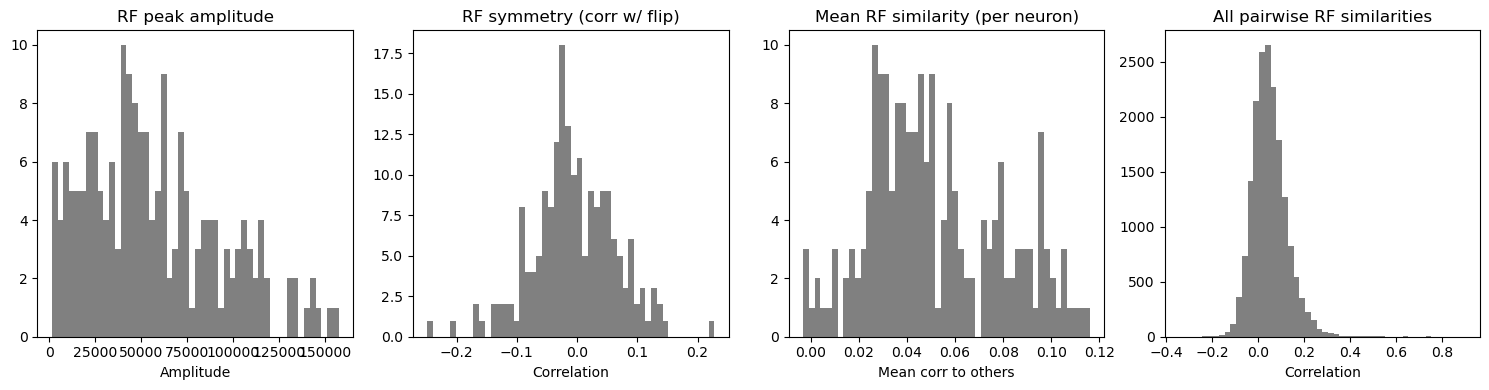

In [96]:
rf_results_STA= np.load("STA_rfs.npy", allow_pickle=True)
rf_maps =np.array([d["rf_map"] for d in rf_results_STA])
metrics = compute_all_rf_metrics(rf_maps)
plot_rf_metrics_histograms(metrics, bins=50)

1. **RF Peak Distribution:**
    - Observation: Wide range of peak amplitudes (30,000-70,000 units)
    - Interpretation: Diverse response strengths across neurons
    - Biological implication: Different neurons may have varying sensitivity or signal-to-noise ratios

2. **RF Symmetry Distribution:**
    - Observation: Symmetry scores cluster around zero with some spread
    - Interpretation: Most RFs show asymmetry
    - Biological implication: Neurons may have subtle orientation or directional preferences

3. **Similarity Distributions:**
    - Observation: Mean similarities around 0.1-0.2, pairwise similarities show clustering structure
    - Interpretation: Moderate functional diversity with some grouping
    - Biological implication: Neurons form functional clusters.

## Clustering

### Dimensionality Reduction 

We first apply Gaussian smoothing and normalization to the RFs to enhance signal quality and comparability across neurons.
 
Principal Component Analysis (PCA) is then used to reduce the dimensionality of the RF data, capturing the main sources of variation. The PCA output serves as the initialization for t-SNE, which provides a two-dimensional embedding suitable for visualization and subsequent clustering analysis. This approach ensures that clustering is performed on a representation that preserves both global structure and local relationships among neurons.

In [97]:
neurons= np.arange(rf_maps.shape[0])
rf_maps = [gaussian_filter(rf_maps[i],1) for i in neurons]
rf_maps= np.array(rf_maps)

In [98]:
roi_positions = np.array([d["cortical_position"] for d in rf_results_STA])

In [99]:
def rf_flatten_features(rf_maps, normalize=True):
    """
    Flatten RF maps. Optionally normalize each RF (z-score or max scaling).
    normalize=True performs z-scoring per RF.
    """
    N = len(rf_maps)
    H, W = rf_maps[0].shape
    X = np.array([rf_maps[i].ravel() for i in range(N)], dtype=float)
    if normalize:
        # z-score per RF to reduce amplitude differences
        X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)
    return X  # shape (N, H*W)

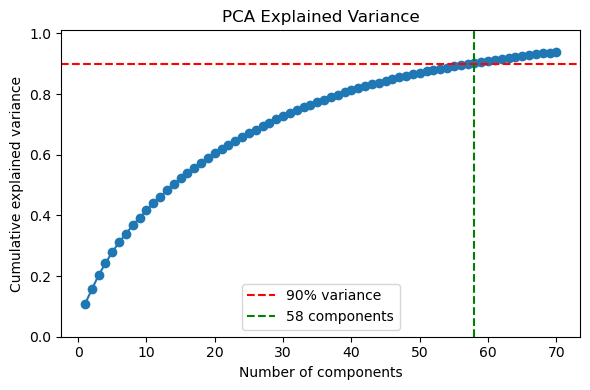

90% variance reached at 58 components.


In [100]:
def plot_explained_variance(rf_maps, max_components=30):
    """
    Plot cumulative explained variance of PCA on RF maps and mark 90% point.

    Parameters
    ----------
    rf_maps : array-like (N, H, W)
    max_components : int
        Max number of components to compute.
    standardize : {'none','per_neuron','per_pixel'}
        - 'none': raw flattened values
        - 'per_neuron': z-score each RF (row-wise)
        - 'per_pixel': z-score each pixel across neurons (column-wise)
    """
    rf_maps = np.array(rf_maps)
    N = rf_maps.shape[0]
    
    X_flat = rf_flatten_features(rf_maps, normalize=True)

    n_comp = min(max_components, X_flat.shape[1], N)
    pca = PCA(n_components=n_comp)
    pca.fit(X_flat)
    explained = np.cumsum(pca.explained_variance_ratio_)

    # where we cross 90%
    n90 = np.argmax(explained >= 0.9) + 1

    plt.figure(figsize=(6,4))
    plt.plot(np.arange(1, n_comp+1), explained, marker='o')
    plt.axhline(0.9, color='r', linestyle='--', label='90% variance')
    plt.axvline(n90, color='g', linestyle='--', label=f'{n90} components')
    plt.ylim(0, 1.01)  # force full 0-1 range so you can see the jump
    plt.xlabel('Number of components')
    plt.ylabel('Cumulative explained variance')
    plt.title('PCA Explained Variance')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"90% variance reached at {n90} components.")


plot_explained_variance(rf_maps, max_components=70)

In [101]:
def reduce_features(X, n_components=25, scale=True):
    """
    Optional scaling + PCA reduction.
    Returns reduced feature matrix and fitted PCA object.
    """
    if scale:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = X
    pca = PCA(n_components
)
    X_red = pca.fit_transform(X_scaled)
    return X_red, pca

In [102]:
from sklearn.manifold import TSNE
def tsne_analysis(X, rf_maps, roi_positions, perplexity=30, random_state=42):
    """
    Comprehensive t-SNE analysis for dimensionality reduction and visualization.
    """
    print("Running t-SNE analysis...")
    
    # 1. Standard t-SNE
    tsne = TSNE(n_components=2, perplexity=perplexity,
                random_state=random_state, verbose=1)
    X_tsne = tsne.fit_transform(X)

    return X_tsne

In [103]:
X_flat = rf_flatten_features(rf_maps)
# Run PCA
X_red_pca, pca = reduce_features(X_flat, n_components=58)
# Run t-SNE
tsne_results = tsne_analysis(X_red_pca, rf_maps, roi_positions)

Running t-SNE analysis...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 189 samples in 0.000s...
[t-SNE] Computed neighbors for 189 samples in 4.083s...
[t-SNE] Computed conditional probabilities for sample 189 / 189
[t-SNE] Mean sigma: 8.047093
[t-SNE] KL divergence after 250 iterations with early exaggeration: 67.404549
[t-SNE] KL divergence after 1000 iterations: 1.047104


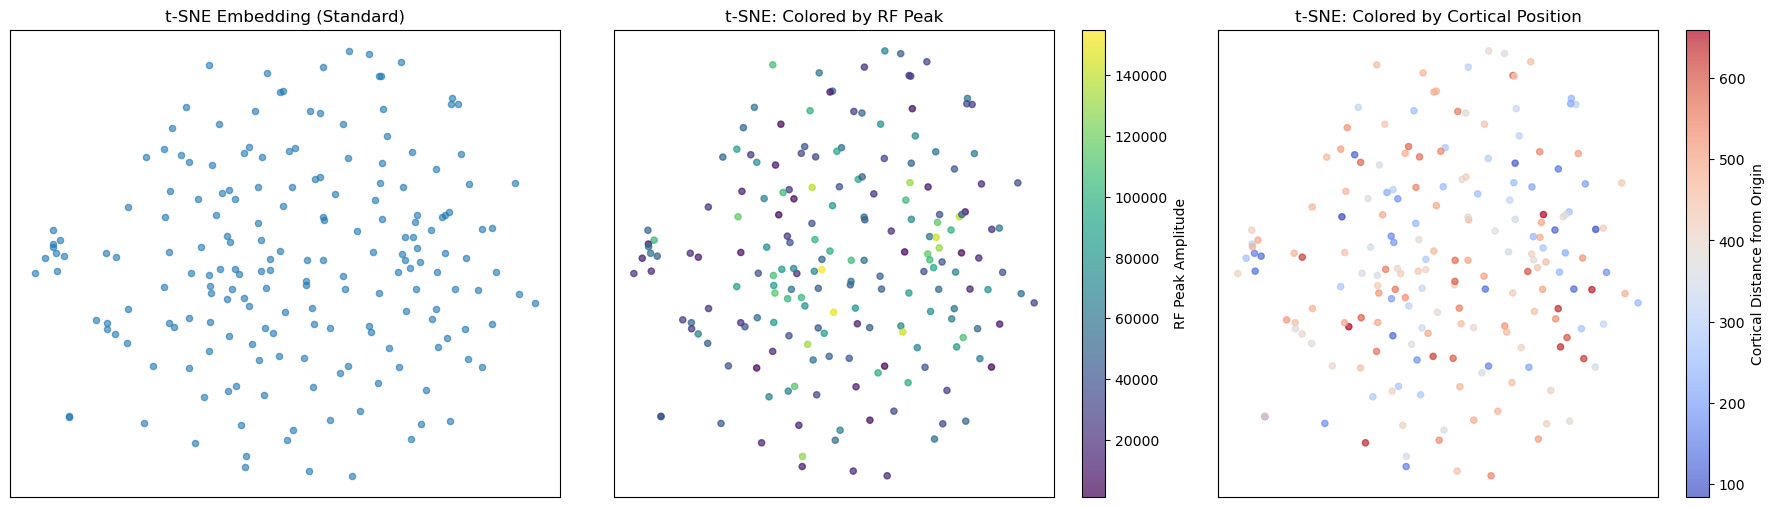

In [104]:
def plot_tsne_analysis(tsne_results, rf_maps, roi_positions, labels_dict=None):
    """
    Comprehensive t-SNE visualization.
    """
    
    # 1. Standard t-SNE plot
    plt.figure(figsize=(18, 10))
    
    # Main t-SNE plot
    plt.subplot(2, 3, 1)
    plt.scatter(tsne_results[:, 0], 
                tsne_results[:, 1], 
                alpha=0.6, s=20)
    plt.title('t-SNE Embedding (Standard)')
    plt.xticks([])
    plt.yticks([])

    
    # 2. t-SNE with RF peak amplitude coloring
    rf_peaks = [compute_rf_peak(rf) for rf in rf_maps]
    plt.subplot(2, 3, 2)
    scatter = plt.scatter(tsne_results[:, 0], 
                         tsne_results[:, 1], 
                         c=rf_peaks, cmap='viridis', alpha=0.7, s=20)
    plt.colorbar(scatter, label='RF Peak Amplitude')
    plt.title('t-SNE: Colored by RF Peak')
    plt.xticks([])
    plt.yticks([])
    
    
    # 6. Cortical position correlation
    plt.subplot(2, 3, 3)
    cortical_distances = np.sqrt(roi_positions[:, 0]**2 + roi_positions[:, 1]**2)
    scatter = plt.scatter(tsne_results[:, 0], 
                         tsne_results[:, 1], 
                         c=cortical_distances, cmap='coolwarm', alpha=0.7, s=20)
    plt.colorbar(scatter, label='Cortical Distance from Origin')
    plt.title('t-SNE: Colored by Cortical Position')
    plt.xticks([])
    plt.yticks([])
    
    plt.tight_layout()
    plt.show()
    
# Plot t-SNE analysis
plot_tsne_analysis(tsne_results, rf_maps, roi_positions)

The left panel displays the overall distribution of neurons in the t-SNE space, there is no clear groupings is visually apparent.

The middle panel colors neurons by RF peak amplitude, suggesting some local variation in response strength, though strong clustering by peak is not evident. 

The right panel shows cortical positions, with some spatial gradients, but no obvious anatomical separation is visible in the embedding. 

Overall, these plots suggest possible underlying structure, but no pronounced functional or anatomical clusters can be directly inferred from this visualization alone.

###  kMeans and GMM Clustering

- **K-means** does hard clustering with spherical clusters, computationally efficient
- **Gaussian Mixture Models (GMM)** does soft clustering with elliptical clusters, probabilistic assignments

**Model Selection**: Multi-criteria evaluation using statistical and biological scores.
- Statistical Evaluation: 
    - Silhouette score: Measures how similar each neuron is to its own cluster compared to other clusters. Higher values indicate better-defined and more separated clusters.
    - Davies-Bouldin score: Assesses the average similarity between each cluster and its most similar other cluster. Lower values indicate better clustering with more distinct and compact clusters.
- Biological Plausibility:
    - Spatial Coherence: How similar RFs are within clusters
    - Distinctiveness: How different cluster means are from each other
    - Spatial Organization: Cortical clustering of functionally similar neurons
    - Symmetry Consistency: Uniformity of RF symmetry within clusters


In [105]:
def cluster_on_tsne_embeddings(tsne_results, rf_maps, roi_positions, n_clusters_range=range(2, 11)):
    """
    Apply clustering methods to t-SNE embeddings with different numbers of clusters.
    
    Parameters:
    -----------
    tsne_results : array-like
        t-SNE embedding results
    rf_maps : array-like
        Receptive field maps
    roi_positions : array-like
        ROI positions
    n_clusters_range : range
        Range of cluster numbers to try (default: range(2, 11) for 2-10 clusters)
    
    Returns:
    --------
    results : dict
        Dictionary containing results for each method and cluster number
    """
    
    X_tsne = tsne_results
    results = {}
    
    # Try different numbers of clusters
    for n_clusters in n_clusters_range:
        print(f"Testing {n_clusters} clusters...")
        
        # 1. K-means on t-SNE
        kmeans_tsne = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
        labels = kmeans_tsne.fit_predict(X_tsne)
        results[f'kmeans_tsne_k{n_clusters}'] = {
            'labels': labels, 'k': n_clusters,
            'silhouette': silhouette_score(X_tsne, labels),
            'davies_bouldin': davies_bouldin_score(X_tsne, labels),
        }
        
        # 2. GMM on t-SNE
        gmm_tsne = GaussianMixture(n_components=n_clusters, random_state=42)
        labels = gmm_tsne.fit_predict(X_tsne)
        results[f'gmm_tsne_k{n_clusters}'] = {
            'labels': labels, 'k': n_clusters,
            'silhouette': silhouette_score(X_tsne, labels),
            'davies_bouldin': davies_bouldin_score(X_tsne, labels),
        }
    
    return results


In [106]:
"""LLM disclaimer: this method was devised by Claude"""

def enhanced_biological_plausibility_tests(rf_maps, labels, roi_positions):
    """
    Comprehensive biological plausibility assessment.
    """
    
    unique_labels = np.unique(labels[labels >= 0])
    if len(unique_labels) < 2:
        return {}
    
    results = {}
    
    # 1. Spatial coherence within clusters
    spatial_coherence = []
    for label in unique_labels:
        cluster_mask = labels == label
        cluster_rfs = rf_maps[cluster_mask]
        
        if len(cluster_rfs) < 2:
            continue
            
        # Compute mean RF for cluster
        cluster_mean = np.mean(cluster_rfs, axis=0)
        
        # Correlation of each RF with cluster mean
        correlations = []
        for rf in cluster_rfs:
            corr = np.corrcoef(rf.flatten(), cluster_mean.flatten())[0, 1]
            if not np.isnan(corr):
                correlations.append(corr)
        
        if correlations:
            spatial_coherence.append(np.mean(correlations))
    
    results['spatial_coherence'] = np.mean(spatial_coherence) if spatial_coherence else 0.0
    
    # 2. Cluster distinctiveness
    cluster_means = []
    for label in unique_labels:
        cluster_mask = labels == label
        if np.sum(cluster_mask) > 0:
            cluster_mean = np.mean(rf_maps[cluster_mask], axis=0)
            cluster_means.append(cluster_mean)
    
    if len(cluster_means) > 1:
        # Compute pairwise correlations between cluster means
        distinctiveness_scores = []
        for i in range(len(cluster_means)):
            for j in range(i+1, len(cluster_means)):
                corr = np.corrcoef(cluster_means[i].flatten(), cluster_means[j].flatten())[0, 1]
                if not np.isnan(corr):
                    distinctiveness_scores.append(1.0 - abs(corr))
        
        results['distinctiveness'] = np.mean(distinctiveness_scores) if distinctiveness_scores else 0.0
    else:
        results['distinctiveness'] = 0.0
    
    
    # 4. Spatial organization (cortical clustering)
    spatial_organization = []
    for label in unique_labels:
        cluster_mask = labels == label
        cluster_positions = roi_positions[cluster_mask]
        
        if len(cluster_positions) < 2:
            continue
            
        # Compute mean distance between cluster members
        from scipy.spatial.distance import pdist
        distances = pdist(cluster_positions)
        mean_distance = np.mean(distances)
        
        # Compare to random expectation
        random_distances = []
        for _ in range(100):
            random_indices = np.random.choice(len(roi_positions), len(cluster_positions), replace=False)
            random_positions = roi_positions[random_indices]
            random_dist = np.mean(pdist(random_positions))
            random_distances.append(random_dist)
        
        random_mean = np.mean(random_distances)
        if random_mean > 0:
            organization_score = 1.0 - (mean_distance / random_mean)
            spatial_organization.append(max(0.0, organization_score))
    
    results['spatial_organization'] = np.mean(spatial_organization) if spatial_organization else 0.0
    
    # 5. RF symmetry consistency
    symmetry_consistency = []
    for label in unique_labels:
        cluster_mask = labels == label
        cluster_rfs = rf_maps[cluster_mask]
        
        if len(cluster_rfs) < 2:
            continue
            
        symmetries = []
        for rf in cluster_rfs:
            sym = rf_symmetry(rf, axis=1)
            if not np.isnan(sym):
                symmetries.append(abs(sym))
        
        if symmetries:
            consistency = 1.0 - np.std(symmetries)
            symmetry_consistency.append(max(0.0, consistency))
    
    results['symmetry_consistency'] = np.mean(symmetry_consistency) if symmetry_consistency else 0.0
    
    # 6. Overall biological plausibility score
    weights = {
        'spatial_coherence': 0.25,
        'distinctiveness': 0.25,
        'spatial_organization': 0.20,
        'symmetry_consistency': 0.15
    }
    
    total_score = sum(weights[criterion] * results[criterion] for criterion in weights.keys())
    results['overall_plausibility'] = total_score
    
    return results

In [107]:
def comprehensive_method_comparison(tsne_results, rf_maps, roi_positions, n_clusters_range=range(2, 11)):
    """
    Compare all clustering methods comprehensively with different cluster numbers.
    
    Parameters:
    -----------
    X_red : array-like
        Reduced feature matrix
    rf_maps : array-like
        Receptive field maps
    roi_positions : array-like
        ROI positions
    tsne_results : array-like
        t-SNE embedding results
    n_clusters_range : range
        Range of cluster numbers to try (default: range(2, 11) for 2-10 clusters)
    
    Returns:
    --------
    comparison_df : pandas.DataFrame
        Comparison results sorted by overall score
    all_results : dict
        All clustering results
    bio_scores : dict
        Biological plausibility scores
    """
    
    print("Running comprehensive method comparison...")
    
    # 1. Run all  methods with different cluster numbers
    advanced_results = cluster_on_tsne_embeddings(tsne_results, rf_maps, roi_positions, n_clusters_range)
    
    # 2. Combine all results
    all_results = {**advanced_results}
    
    # 3. Evaluate biological plausibility for all methods
    print("Evaluating biological plausibility...")
    bio_scores = {}
    for method_name, result in all_results.items():
        if result['labels'] is not None:
            bio_score = enhanced_biological_plausibility_tests(rf_maps, result['labels'], roi_positions)
            bio_scores[method_name] = bio_score
    
    # 4. Create comprehensive comparison table
    comparison_data = []
    for method_name, result in all_results.items():
        if result['labels'] is not None:
            bio_score = bio_scores.get(method_name, {})
            row = {
                'Method': method_name,
                'K': result['k'],
                'Silhouette': result['silhouette'],
                'Davies-Bouldin': result['davies_bouldin'],
                'Overall_Plausibility': bio_score.get('overall_plausibility', 0.0),
            }
            comparison_data.append(row)
    
    # 5. Create comparison DataFrame
    comparison_df = pd.DataFrame(comparison_data)
    
    # 6. Sort by overall score (weighted combination)
    comparison_df['Overall_Score'] = (
        0.3 * comparison_df['Silhouette'] + 
        0.2 * (1.0 / (1.0 + comparison_df['Davies-Bouldin'])) +
        0.3 * comparison_df['Overall_Plausibility']
    )
    
    comparison_df = comparison_df.sort_values('Overall_Score', ascending=False)
    
    return comparison_df, all_results, bio_scores

In [108]:
comparison_df, all_clustering_results, bio_scores = comprehensive_method_comparison(
    tsne_results, rf_maps, roi_positions, n_clusters_range=range(2, 11)
)

Running comprehensive method comparison...
Testing 2 clusters...
Testing 3 clusters...
Testing 4 clusters...
Testing 5 clusters...
Testing 6 clusters...
Testing 7 clusters...
Testing 8 clusters...
Testing 9 clusters...


c:\Users\aagne\anaconda3\envs\final_nds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\aagne\anaconda3\envs\final_nds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\aagne\anaconda3\envs\final_nds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\aagne\anaconda3\envs\final_nds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

Testing 10 clusters...
Evaluating biological plausibility...


### Best Model Selection and Visualization

In [109]:
def select_and_visualize_best_method(comparison_df, all_results, rf_maps, roi_positions, tsne_results):
    """
    Select the best method and create comprehensive visualizations.
    """
    
    # Get best method
    best_method = comparison_df.iloc[0]['Method']
    best_result = all_results[best_method]
    best_labels = best_result['labels']
    
    print(f"\n=== BEST METHOD: {best_method.upper()} ===")

    # Define consistent colormap
    unique_labels = np.unique(best_labels)
    num_clusters = len(unique_labels)
    color_map = plt.cm.get_cmap('tab20', num_clusters)
    label_to_color = {label: color_map(i) for i, label in enumerate(unique_labels)}
    cluster_colors = np.array([label_to_color[label] for label in best_labels])

    # Create comprehensive visualization
    fig = plt.figure(figsize=(25, 12))

    # 1. t-SNE with best clustering
    plt.subplot(2, 4, 1)
    scatter = plt.scatter(tsne_results[:, 0], 
                          tsne_results[:, 1], 
                          c=cluster_colors, alpha=0.7, s=30)
    plt.title(f'{best_method.upper()}\nClusters in t-SNE Space')
    plt.xticks([])
    plt.yticks([])


    # 2. Cortical space clustering
    plt.subplot(2, 4, 2)
    scatter = plt.scatter(roi_positions[:, 0], roi_positions[:, 1], 
                          c=cluster_colors, s=35, edgecolor='k', linewidth=0.3)
    plt.title(f'{best_method.upper()}\nClusters in Cortical Space')
    plt.xlabel('Cortical X')
    plt.ylabel('Cortical Y')

    plt.gca().invert_yaxis()

    # 3. Cluster sizes
    plt.subplot(2, 4, 3)
    counts = [np.sum(best_labels == label) for label in unique_labels]
    bar_colors = [label_to_color[label] for label in unique_labels]
    plt.bar(unique_labels, counts, color=bar_colors)
    plt.title('Cluster Sizes')
    plt.xlabel('Cluster')
    plt.ylabel('Number of Neurons')

    # 4. RF properties by cluster
    plt.subplot(2, 4, 4)
    rf_peaks = [compute_rf_peak(rf) for rf in rf_maps]
    cluster_peaks = []
    for label in unique_labels:
        cluster_mask = best_labels == label
        cluster_peaks.append(np.mean([rf_peaks[i] for i in np.where(cluster_mask)[0]]))
    plt.bar(unique_labels, cluster_peaks, color=bar_colors)
    plt.title('Average RF Peak by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('RF Peak Amplitude')

    return best_method, best_labels


In [110]:
def cluster_average_rfs(rf_maps, labels, zscore_each=True):
    """
    Returns dict: cluster_label -> average RF map.
    Optionally z-score each RF before averaging to equalize amplitude.
    """
    rf_maps = np.asarray(rf_maps)
    unique_labels = np.unique(labels)
    cluster_means = {}
    for lab in unique_labels:
        idx = np.where(labels == lab)[0]
        if len(idx) == 0 or lab < 0:
            continue
        subset = rf_maps[idx]
        if zscore_each:
            # z-score each map across pixels
            s = subset.reshape(len(idx), -1)
            s = (s - s.mean(axis=1, keepdims=True)) / (s.std(axis=1, keepdims=True) + 1e-8)
            subset = s.reshape(subset.shape)
        cluster_means[lab] = subset.mean(axis=0)
    return cluster_means

import matplotlib.gridspec as gridspec

def plot_cluster_average_rfs(cluster_means, n_cols=5, cmap='bwr'):
    keys = sorted(cluster_means.keys())
    n = len(keys)
    n_cols = min(n_cols, n)
    n_rows = int(np.ceil(n / n_cols))

    v = max(np.max(np.abs(m)) for m in cluster_means.values())

    # Create figure and GridSpec
    fig = plt.figure(figsize=(3 * n_cols + 2, 3 * n_rows))
    gs = gridspec.GridSpec(n_rows, n_cols + 1, width_ratios=[1]*n_cols + [0.05], wspace=0.3)

    im = None  # Reference for colorbar
    for idx, lab in enumerate(keys):
        row, col = divmod(idx, n_cols)
        ax = fig.add_subplot(gs[row, col])
        im = ax.imshow(cluster_means[lab], cmap=cmap, vmin=-v, vmax=v, interpolation='nearest')
        ax.set_title(f'Cluster {lab}', fontsize=7)
        ax.axis('off')

    # Add shared colorbar in the last column
    cax = fig.add_subplot(gs[:, -1])
    fig.colorbar(im, cax=cax, label='RF Intensity')

    fig.suptitle("Cluster Average Receptive Field", fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.8, 0.8])  # Leave room for suptitle
    plt.show()


=== BEST METHOD: GMM_TSNE_K5 ===


C:\Users\aagne\AppData\Local\Temp\ipykernel_41516\356654228.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', num_clusters)
C:\Users\aagne\AppData\Local\Temp\ipykernel_41516\2419467979.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.8, 0.8])  # Leave room for suptitle


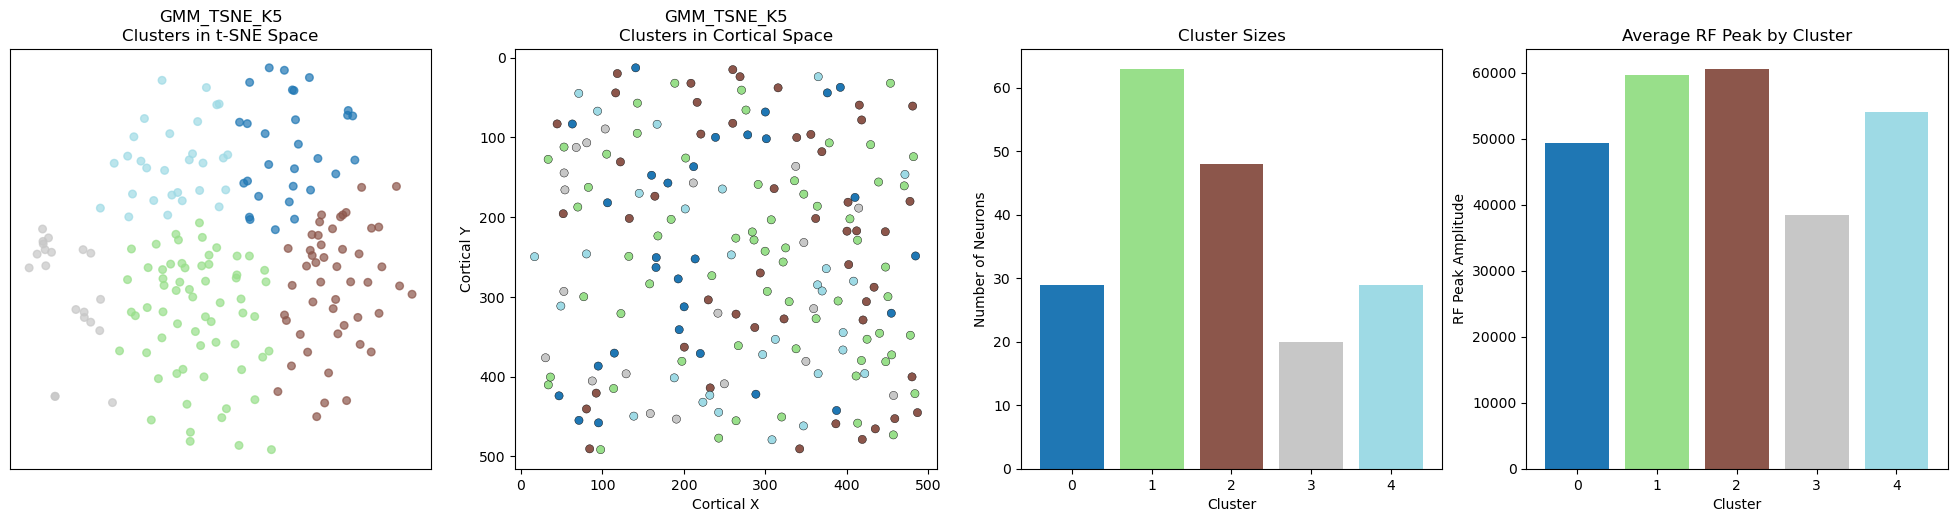

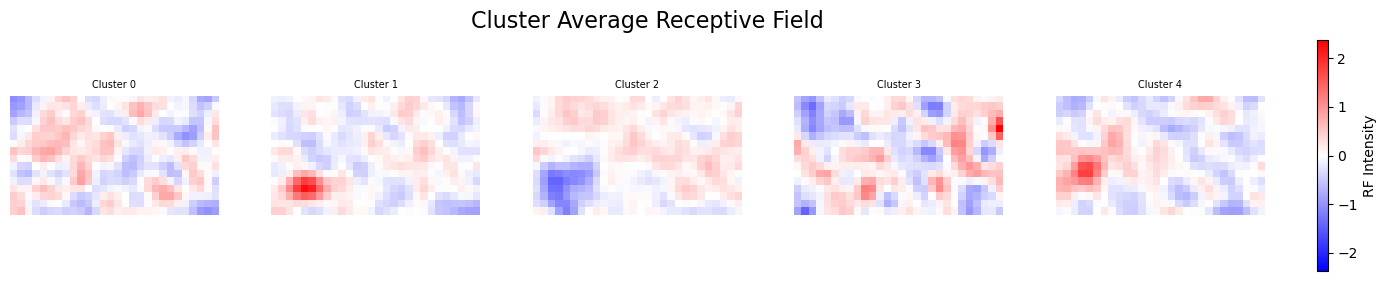

In [111]:
# Select and visualize the best method (which now includes optimal cluster number)
best_method, best_labels = select_and_visualize_best_method(
    comparison_df, all_clustering_results, rf_maps, roi_positions, tsne_results
)

# Plot cluster averages for the best method
cluster_means = cluster_average_rfs(rf_maps, best_labels)
plot_cluster_average_rfs(cluster_means)

In t-SNE space, the clusters identified by the GMM algorithm appear well separated, indicating that the receptive field features allow for clear functional grouping. However, when mapped onto cortical space, the anatomical separation is less pronounced—some clusters are spatially intermixed, and there is no strong evidence for neat anatomical clustering.

Cluster sizes are balanced, with no single cluster strongly dominating the population. The average RF peak amplitude varies across clusters, reflecting differences in response strength.

We consistently observe that strong responses are localized in the lower left corner of the receptive field maps across all analyses. This likely reflects the anatomical positioning of the recorded neurons, whose receptive fields naturally align with that region of the stimulus space. 

Including a broader or more diverse set of neurons in the analysis could reveal receptive fields with a wider variety of spatial locations and potentially uncover additional functional patterns.

Based on the average receptive fields and their spatial patterns, we can speculate on the functional roles of each cluster:

- **Cluster 1**: Shows a strong localized ON response pattern in its average population RF, suggesting a highly sensitivity to the specific lower left region of the stimulus. Neurons in this cluster likely act as feature detectors, responding robustly to distinct spatial inputs.

- **Cluster 2** Similar to cluster 1, but with OFF response pattern.

- **Cluster 4:** This cluster also displays a pronounced ON response, indicating a preference for activation by specific stimulus regions. Its neurons may serve a similar role to clusters 1 and 2, but with a bias toward excitatory responses.

- **Clusters 0 and 3:** These clusters do not exhibit localized activity in their average RFs. Instead, their receptive fields are more diffuse, which may reflect roles in integrating information over broader spatial areas or modulating the activity of other neurons. Cluster 0 could be involved in background integration or gain control, while cluster 3 might contribute to contextual modulation or global inhibition.

Overall, the diversity in RF patterns across clusters suggests a division of labor, with some neurons specialized for detecting specific features and others supporting integration and modulation within the network.

# Summary of Analysis Pipeline and Findings

**Pre-processing**

We first cleaned the raw calcium traces by applying a 3rd-order low-pass Butterworth filter (cutoff ≈0.7 Hz) using zero-phase filtering, then z-scored each neuron’s trace. This removed high-frequency noise and normalized the amplitude so neurons were on a common scale. We also extracted only the locally-sparse-noise stimulus epochs (out of several stimuli) for receptive-field (RF) analysis, and checked that each frame had pixel values 0, 127, or 255 (background, gray, white) for consistency. 

**Spike inference**

To infer neural activity from the calcium traces, we tested three methods: (1) a simple peak-detection threshold, (2) OOPSI (a probabilistic spike-deconvolution algorithm) and (3) OASIS (sparse deconvolution). These methods yield continuous or binary spike estimates reflecting neural firing. By comparing outputs, we found the OOPSI and OASIS results were very similar. (For example, plots of an example neuron show that OOPSI and OASIS gave nearly identical event timings.) We therefore proceeded using the OASIS-derived spike traces for further analysis. For consistency, we z-scored or normalized the deconvolved outputs and applied a threshold (e.g. 0.2) to get binary spike trains, as described in the code comments. 

**Receptive field fitting (tuning)**

Next we estimated each neuron’s receptive field using a spike-triggered average (STA). In this classical approach, we bin the spikes and stimuli (each 16×28 frame of sparse noise) into matching time bins and average the stimulus preceding each spike. Formally, for each neuron we built a design matrix of stimuli over a fixed “lag” window before each spike and averaged these to compute a spatiotemporal RF array. (See code: we packaged this into compute_sta_for_neuron() and computed STAs for all neurons.) The STA yields a 3D map (pixel×pixel×time-lag) showing which stimulus pixels tend to elicit spikes. We often visualized the STA by taking the time lag with strongest response. 

We also attempted more sophisticated models (space-time LNP and Lasso-regularized GLMs) to fit RFs. These required fitting a linear filter plus nonlinearity via maximum likelihood. However, in most cases our data had few spikes per neuron, so the basic STA often performed comparably or better.

In practice, many neurons showed clear localized ON or OFF subfields. For example, Neuron 60 had a strong OFF-centered subfield (responding to black spots) in the lower-left of the stimulus with virtually no ON response. To quantify each RF, we computed its center-of-mass in visual coordinates. We also computed additional RF metrics (peak amplitude, spatial symmetry, etc.) by treating each STA map as a 2D image. All STA results were saved (file STA_rfs.npy) along with each neuron’s RF center. As a check of statistical significance, we ran a shuffle-based test for each pixel (generating a p-value map and FDR mask). For Neuron 60, this confirmed that the OFF subregion was highly significant (a cluster of low p-values remained after FDR thresholding) while the ON map showed only scattered non-significant pixels. 

**Spatial-organization analysis**

To address the question of spatial structure, we related each neuron’s RF center to its cortical location. We computed each ROI’s centroid in the imaging plane (via its mask) to get a 2D “cortical position” for every neuron. We then analyzed how the RF features clustered functionally and whether those clusters corresponded to contiguous anatomical regions. 

First, we performed dimensionality reduction on the STA maps. We smoothed each RF map with a small Gaussian, flattened it into a feature vector (z-scored per RF), and ran PCA followed by t-SNE to embed all neurons in 2D. In the t-SNE plot, we colored points by functional metrics (e.g. RF peak strength) and by cortical position. This visualization showed some local groupings by RF properties, but no obvious anatomical gradient. In particular, coloring neurons by their cortical distance (distance of ROI from origin) revealed no clear clustering by anatomy (no clean gradient or separation in the t-SNE space). 

Next we applied clustering (k-means and Gaussian-mixture models) on the t-SNE embedding (tested 2–10 clusters, choosing the best with silhouette/DB scores). We found ~5 clusters gave a good balance. Plotting these clusters back onto cortex (scatter of ROI centroids) confirmed that they were spatially mixed. In other words, neurons that had similar RF shapes or ON/OFF types were intermingled on the cortical image, rather than forming separated domains. As the notebook notes, “when mapped onto cortical space, the anatomical separation is less pronounced – some clusters are spatially intermixed, and there is no strong evidence for neat anatomical clustering”. This was consistent across methods (whether k-means or GMM) and metrics: cluster identities did not coincide with contiguous patches on the cortical sheet.

We did notice one broader bias: most of the RF centers fell in the lower-left portion of the visual field (i.e. neurons tended to respond to stimuli in that corner). This matches known retinotopy for this cortical area (the imaged patch apparently represents the lower-left visual quadrant). In our data the RF centers are somewhat aligned with that bias, but beyond that the fine-scale distribution appears largely random.

**Limitations**

Limitations include the limited field-of-view (189 neurons in one patch of V1) and a modest number of spikes per neuron, which reduce statistical power. In future work, we could improve this analysis by imaging larger areas or mapping retina-to-cortex correspondences more directly (e.g. with flashing bar stimuli). More sophisticated statistics (e.g. formal tests of correlation between cortical distance and RF distance) could quantify any weak trends. 

Several improvements could enhance the reliability and resolution of receptive field (RF) estimates. Using more advanced spike inference algorithms such as CASCADE or MLspike could yield higher-fidelity spiking estimates, especially in low-SNR regimes. To rigorously assess spatial structure, statistical tests like the Mantel test or spatial autocorrelation metrics (e.g., Moran’s I) could quantify the relationship between cortical and visual field distances. Finally, structured retinotopic mapping stimuli (e.g., drifting bars or rings) would allow direct reconstruction of visual space representations across cortex and serve as a gold standard for assessing topographic organization.

# References

- OOPSI spikes: https://github.com/liubenyuan/py-oopsi
- OASIS spikes: https://github.com/j-friedrich/OASIS
- RFEst: https://github.com/berenslab/RFEst and https://github.com/huangziwei/notebooks_RFEst (tutorial notebooks) 
- Allen Institute's Stimulus Set and Response Analysis: https://community.brain-map.org/t/documentation-brain-observatory/3026 